# Experimentos Univariados v5 Cloud (Vertex AI)

**Tesis MEC** — 97 DGPs x T in {50,100,200} x R=500  
**Verificacion DGP:** cada experimento incluye seccion PASS/FAIL antes del Monte Carlo  
**Horizonte por T:** T=50->H=6 * T=100->H=18 * T=200->H=24  
**Metricas:** Bias, Varianza, RMSE, CRPS  
**Bloques:** Corto h=1-6 * Medio h=7-18 * Largo h=19-24  
**Logging:** dual stdout + `results/univariate_v5_vertexai/run_YYYYMMDD_HHMMSS.log`  
**Resultados:** `results/univariate_v5_vertexai/` — si existen se cargan sin re-simular

---

### Calculo de CRPS para Chronos (cambio respecto a v4_cloud)

Chronos-2 expone únicamente cuantiles (no samples i.i.d.). En v4_cloud se pasaban 5 cuantiles ordenados a `crps_ensemble`, lo cual rompe el supuesto i.i.d. del estimador de Hersbach e introduce un sesgo relativo positivo de hasta ~100% en el benchmark N(0,1). **v5 calcula el CRPS vía la representación integral propia**

$$\text{CRPS}(F, y) = 2 \int_0^1 \text{QL}_\tau\!\left(F^{-1}(\tau),\, y\right) d\tau$$

aproximada con regla del trapecio sobre **K=39 cuantiles uniformes** $\{0.025, 0.050, \ldots, 0.975\}$. Es la misma familia que la WQL del paper de Chronos (Ansari et al. 2024); convergencia $\mathcal{O}(1/K^2)$, scoring rule propia. Para los modelos clásicos se sigue usando `crps_gaussian` (exacta) o `crps_ensemble` con paths bootstrap (samples genuinos del modelo). **Los CSV en `results/univariate_v5_vertexai/` no son comparables directamente con los de v4_cloud para Chronos.**

In [1]:
import warnings
warnings.filterwarnings("ignore")

import copy
import logging
import sys
import time
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import torch
from IPython.display import display

from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.stats.diagnostic import acorr_ljungbox

from mectesis.dgp import (
    RandomWalk, SeasonalDGP,
    AR1ARCH, AR1GARCH,
    LocalLevelDGP, LocalTrendDGP, DampedTrendDGP, LocalLevelSeasonalDGP,
    ARpDGP, MAqDGP, ARMApqDGP, ARMApqWithTrendDGP,
    SETARDGp, LSTARDGp, ESTARDGp,
)
from mectesis.models import (
    ARIMAModel, ARIMAWithTrendModel, SARIMAModel,
    ARARCHModel, ARGARCHModel,
    ETSModel, ThetaModel, ChronosModel,
)
from mectesis.simulation import MonteCarloEngine

SEED    = 3649
H_BY_T  = {50: 6, 100: 18, 200: 24}
H_MAX   = 24
R_LIST  = [500]
T_LIST  = [50, 100, 200]
RESULTS = Path("results/univariate_v5_vertexai")
RESULTS.mkdir(parents=True, exist_ok=True)

# ── Logging dual: notebook + archivo .log ────────────────────────────────────
log_path = RESULTS / f"run_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(message)s",
    datefmt="%H:%M:%S",
    handlers=[
        logging.FileHandler(log_path, encoding="utf-8"),
        logging.StreamHandler(sys.stdout),
    ],
)
log = logging.getLogger().info
log(f"Log en: {log_path}")

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)

device = "cuda" if torch.cuda.is_available() else "cpu"
log(f"Cargando Chronos-2 en {device} (puede tardar ~30 s la primera vez)...")
chronos = ChronosModel(device=device)
log("Chronos-2 listo.")

19:05:55  Log en: results\univariate_v5_vertexai\run_20260519_190555.log
19:05:55  Cargando Chronos-2 en cpu (puede tardar ~30 s la primera vez)...
19:06:04  Chronos-2 listo.


In [2]:
# ─── Funciones auxiliares ────────────────────────────────────────────────────

def _cache_path(exp_id: str, T: int, R: int) -> Path:
    return RESULTS / f"exp_{exp_id.replace('.', '_')}_T{T}_R{R}.csv"


def _save_results(results: dict, path: Path):
    frames = []
    for mname, df in results.items():
        tmp = df.copy()
        tmp.insert(0, "model", mname)
        frames.append(tmp)
    pd.concat(frames, ignore_index=True).to_csv(path, index=False)


def _load_results(path: Path) -> dict:
    df = pd.read_csv(path)
    return {
        mname: grp.drop(columns="model").reset_index(drop=True)
        for mname, grp in df.groupby("model", sort=False)
    }


def run_exp(dgp, make_models_fn, dgp_params, exp_id,
            T_list=T_LIST, R_list=R_LIST, H_by_T=None, seed=SEED):
    if H_by_T is None:
        H_by_T = H_BY_T
    n_runs = len(T_list) * len(R_list)
    combos = ", ".join(
        f"(T={t}, H={H_by_T.get(t, H_MAX)}, R={r})"
        for t in T_list for r in R_list
    )
    log(f"Exp {exp_id}: {n_runs} ejecucion(es) -> {combos}")
    all_results = {}
    for T in T_list:
        h = H_by_T.get(T, H_MAX)
        for R in R_list:
            cache = _cache_path(exp_id, T, R)
            if cache.exists():
                log(f"  T={T} H={h}, R={R}: cargando {cache.name}")
                all_results[(T, R)] = _load_results(cache)
                continue
            log(f"  T={T} H={h}, R={R}: simulando...")
            dgp.rng = np.random.default_rng(seed)
            models = make_models_fn(T)
            engine = MonteCarloEngine(dgp, models, seed=seed)
            t0 = time.time()
            results = engine.run_monte_carlo(R, T, h, dgp_params, verbose=False)
            log(f"  T={T} H={h}, R={R}: OK ({time.time()-t0:.0f}s)")
            _save_results(results, cache)
            all_results[(T, R)] = results
    return all_results


# ─── Funciones v3 ────────────────────────────────────────────────────────────

BLOCK_DEFS = [("C", 1, 6), ("M", 7, 18), ("L", 19, 24)]
METRICS_V3  = ["bias", "variance", "rmse", "crps"]


def compute_blocks_v3(results_TR: dict) -> dict:
    out = {}
    for mname, df in results_TR.items():
        df_h = df[df["horizon"] != "avg_all"].copy()
        df_h["horizon"] = pd.to_numeric(df_h["horizon"], errors="coerce")
        blks = {}
        for blk, h1, h2 in BLOCK_DEFS:
            mask = (df_h["horizon"] >= h1) & (df_h["horizon"] <= h2)
            blks[blk] = df_h[mask].mean(numeric_only=True)
        out[mname] = blks
    return out


def build_grid_table(all_results: dict, classical_name: str,
                     chronos_name: str = "Chronos-2"):
    rows = []
    for (T, R), res_TR in sorted(all_results.items()):
        blk_data = compute_blocks_v3(res_TR)
        cl_blks  = blk_data.get(classical_name, {})
        ch_blks  = blk_data.get(chronos_name, {})

        for mname, blks in blk_data.items():
            row = {"T": T, "Modelo": mname}
            for blk, h1, h2 in BLOCK_DEFS:
                s = blks.get(blk, pd.Series(dtype=float))
                for m in METRICS_V3:
                    row[f"{m}_{blk}"] = (
                        round(float(s[m]), 4)
                        if m in s.index and pd.notna(s[m]) else np.nan
                    )
                cl_s = cl_blks.get(blk, pd.Series(dtype=float))
                ch_s = ch_blks.get(blk, pd.Series(dtype=float))
                for m in ["rmse", "crps"]:
                    cv = float(cl_s[m]) if m in cl_s.index and pd.notna(cl_s[m]) else np.nan
                    hv = float(ch_s[m]) if m in ch_s.index and pd.notna(ch_s[m]) else np.nan
                    if np.isnan(cv) or np.isnan(hv):
                        row[f"best_{m}_{blk}"] = np.nan
                    else:
                        row[f"best_{m}_{blk}"] = "C" if cv <= hv else "T"
            rows.append(row)

    df_out = pd.DataFrame(rows).set_index(["T", "Modelo"])
    display(df_out.style.format(precision=4, na_rep="—"))


def plot_simulation_v3(dgp, models, dgp_params, title="", T_vis=100, seed=SEED):
    H_vis   = H_BY_T.get(T_vis, H_MAX)
    old_rng = dgp.rng
    dgp.rng = np.random.default_rng(seed + 99991)
    y       = dgp.simulate(T=T_vis, **dgp_params)
    dgp.rng = old_rng

    split   = T_vis - H_vis
    y_train = y[:split]
    y_test  = y[split:]
    t_train = np.arange(split)
    t_test  = np.arange(split, T_vis)

    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.plot(t_train, y_train, color="gray", lw=1.5, label="Historico")
    ax.axvline(split - 0.5, color="black", ls="--", lw=1, alpha=0.6)
    ax.plot(t_test, y_test, color="black", lw=1.5, marker="o", ms=3, label="Observado")

    palette = ["steelblue", "darkorange", "seagreen", "purple"]
    for i, model in enumerate(models):
        try:
            model.fit(y_train)
            fcst = model.forecast(H_vis)
            c = palette[i % len(palette)]
            ax.plot(t_test, fcst, color=c, lw=1.5, ls="--", marker="s", ms=3, label=model.name)
            if getattr(model, "supports_intervals", False):
                lo, hi = model.forecast_intervals(H_vis, level=0.80)
                ax.fill_between(t_test, lo, hi, color=c, alpha=0.15)
        except Exception as e:
            log(f"  [plot] {model.name} fallo: {e}")

    ax.set(title=title, xlabel="t", ylabel="y")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


# ─── Funciones de verificacion DGP ───────────────────────────────────────────

def verify_dgp(label, dgp, dgp_params, classical_model, checks):
    log(f"{'─'*60}")
    log(f"VERIFICACION DGP: {label}")
    log(f"{'─'*60}")
    dgp_copy = copy.deepcopy(dgp)
    dgp_copy.rng = np.random.default_rng(7777)
    try:
        y_long = dgp_copy.simulate(T=1000, **dgp_params)
    except Exception as e:
        log(f"  [FAIL] simulate() lanzo excepcion: {e}")
        return
    n_fail = 0
    for check_name, check_fn in checks:
        try:
            ok, msg = check_fn(y_long, dgp, dgp_params, classical_model)
        except Exception as e:
            ok, msg = False, f"excepcion inesperada: {e}"
        tag = "PASS" if ok else "FAIL"
        log(f"  [{tag}] {check_name}: {msg}")
        if not ok:
            n_fail += 1
    if n_fail == 0:
        log("  -> TODAS LAS VERIFICACIONES PASARON")
    else:
        log(f"  -> {n_fail} FALLO(S)")


def chk_stationary(y, *_):
    pval = adfuller(y, autolag="AIC")[1]
    return pval < 0.05, f"ADF p={pval:.4f} (umbral 0.05)"

def chk_nonstationary(y, *_):
    pval = adfuller(y, autolag="AIC")[1]
    return pval > 0.10, f"ADF p={pval:.4f} (se espera >0.10)"

def chk_zero_mean(y, *_):
    mu = y.mean(); sigma = y.std(); T = len(y)
    tol = 3.0 * sigma / np.sqrt(T)
    return abs(mu) < tol, f"media={mu:.4f}, tol=+/-{tol:.4f}"

def chk_acf_lag1(y, dgp, dgp_params, *_):
    props = dgp.get_theoretical_properties(**dgp_params) if dgp_params else dgp.get_theoretical_properties()
    phi1 = props.get("phis", [None])[0] if props.get("phis") else None
    if phi1 is None:
        return True, "no aplica (sin phis)"
    acf_vals = acf(y, nlags=1, fft=True)
    emp = acf_vals[1]
    ok = abs(emp - phi1) < 0.15
    return ok, f"ACF[1]={emp:.4f}, phi1_DGP={phi1:.4f}, dif={abs(emp-phi1):.4f}"

def chk_ma_cutoff(y, dgp, dgp_params, *_):
    props = dgp.get_theoretical_properties(**dgp_params) if dgp_params else dgp.get_theoretical_properties()
    thetas = props.get("thetas", [])
    q = len(thetas)
    if q == 0:
        return True, "no aplica (sin thetas)"
    T = len(y)
    thr = 2.0 / np.sqrt(T)
    acf_vals = acf(y, nlags=q+2, fft=True)
    val_after = abs(acf_vals[q+1])
    ok = val_after < thr
    return ok, f"|ACF[{q+1}]|={val_after:.4f}, umbral=2/sqrt(T)={thr:.4f}"

def chk_trend_slope(y, dgp, dgp_params, *_):
    delta = dgp_params.get("delta", None)
    if delta is None:
        return True, "no aplica (sin delta)"
    T = len(y)
    slope = np.polyfit(np.arange(T), y, 1)[0]
    ok = abs(slope - delta) < 0.015
    return ok, f"pendiente_OLS={slope:.5f}, delta_DGP={delta:.5f}, dif={abs(slope-delta):.5f}"

def chk_arch_effects(y, *_):
    y2 = y ** 2
    lb = acorr_ljungbox(y2, lags=[10], return_df=True)
    pval = float(lb["lb_pvalue"].iloc[0])
    return pval < 0.05, f"LB(10) sobre y^2: p={pval:.4f} (se espera <0.05)"

def chk_rw_variance_growth(y, *_):
    T = len(y)
    v1 = np.var(y[:T//4])
    v2 = np.var(y[T//2:])
    ok = v2 > 2.0 * v1
    return ok, f"var(primera cuarta)={v1:.4f}, var(segunda mitad)={v2:.4f}"

def chk_seasonal_acf(y, dgp, dgp_params, *_):
    s = dgp_params.get("s", 4)
    T = len(y)
    thr = 2.0 / np.sqrt(T)
    acf_vals = acf(y, nlags=s+1, fft=True)
    val_s = abs(acf_vals[s])
    ok = val_s > thr
    return ok, f"|ACF[{s}]|={val_s:.4f}, umbral=2/sqrt(T)={thr:.4f}"

def chk_fit_classical(y, dgp, dgp_params, model):
    try:
        m = copy.deepcopy(model)
        m.fit(y[:800])
        fc = m.forecast(horizon=6)
        ok = len(fc) == 6 and not np.any(np.isnan(fc))
        return ok, f"fit+forecast OK, primeros valores: {fc[:3].round(4)}"
    except Exception as e:
        return False, str(e)

def chk_arma_aic(y, dgp, dgp_params, model):
    from statsmodels.tsa.arima.model import ARIMA as StatsARIMA
    props = dgp.get_theoretical_properties(**dgp_params) if dgp_params else dgp.get_theoretical_properties()
    p = len(props.get("phis", []))
    q = len(props.get("thetas", []))
    try:
        aic_arma = StatsARIMA(y, order=(p, 0, q)).fit(disp=False).aic
        aic_ar   = StatsARIMA(y, order=(p, 0, 0)).fit(disp=False).aic if p > 0 else np.inf
        aic_ma   = StatsARIMA(y, order=(0, 0, q)).fit(disp=False).aic if q > 0 else np.inf
        baseline = min(aic_ar, aic_ma)
        ok = aic_arma < baseline
        return ok, f"AIC_ARMA={aic_arma:.1f}, AIC_baseline={baseline:.1f}"
    except Exception as e:
        return False, str(e)

def chk_theta_fit(y, dgp, dgp_params, model):
    try:
        m = copy.deepcopy(model)
        m.fit(y[:800])
        fc = m.forecast(horizon=6)
        return True, f"OK, primeros valores: {fc[:3].round(4)}"
    except Exception as e:
        return False, str(e)

# ── grupos de checks por tipo ─────────────────────────────────────────────────

CHECKS_AR = [
    ("Estacionariedad (ADF)", chk_stationary),
    ("Media ~ 0",             chk_zero_mean),
    ("ACF[1] ~ phi1",         chk_acf_lag1),
    ("Ajuste modelo clasico", chk_fit_classical),
]
CHECKS_AR_TREND = [
    ("Pendiente OLS ~ delta", chk_trend_slope),
    ("Ajuste modelo clasico", chk_fit_classical),
]
CHECKS_MA = [
    ("Estacionariedad (ADF)", chk_stationary),
    ("Media ~ 0",             chk_zero_mean),
    ("Corte ACF en lag q",    chk_ma_cutoff),
    ("Ajuste modelo clasico", chk_fit_classical),
]
CHECKS_MA_TREND = [
    ("Pendiente OLS ~ delta", chk_trend_slope),
    ("Ajuste modelo clasico", chk_fit_classical),
]
CHECKS_ARMA = [
    ("Estacionariedad (ADF)", chk_stationary),
    ("AIC ARMA < baseline",   chk_arma_aic),
    ("Ajuste modelo clasico", chk_fit_classical),
]
CHECKS_RW = [
    ("No estacionariedad",    chk_nonstationary),
    ("Varianza crece con t",  chk_rw_variance_growth),
    ("Ajuste modelo clasico", chk_fit_classical),
]
CHECKS_ARCH = [
    ("Estacionariedad media", chk_stationary),
    ("Efectos ARCH (LB y^2)", chk_arch_effects),
    ("Ajuste modelo clasico", chk_fit_classical),
]
CHECKS_SAR = [
    ("Estacionariedad (ADF)", chk_stationary),
    ("ACF estacional signif.", chk_seasonal_acf),
    ("Ajuste modelo clasico", chk_fit_classical),
]
CHECKS_ETS = [
    ("No estacionariedad",    chk_nonstationary),
    ("Ajuste modelo clasico", chk_fit_classical),
]
CHECKS_THETA = [
    ("Ajuste Theta",          chk_theta_fit),
]
CHECKS_NONLINEAR = [
    ("Estacionariedad (ADF)", chk_stationary),
    ("Ajuste modelo clasico", chk_fit_classical),
]

---
## Bloque A — ARMA sin tendencia (24 experimentos)

DGPs: AR(1-4) * MA(1-4) * ARMA(1,1) * ARMA(2,2) * ARMA(1,4) * ARMA(4,1)  
Modelo clasico: ARIMA(p,0,q) correctamente especificado vs Chronos-2

19:06:04  ────────────────────────────────────────────────────────────
19:06:04  VERIFICACION DGP: A.1 -- AR(1) rho=0.30
19:06:04  ────────────────────────────────────────────────────────────
19:06:04    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:06:04    [PASS] Media ~ 0: media=-0.0366, tol=+/-0.0973
19:06:04    [PASS] ACF[1] ~ phi1: ACF[1]=0.2880, phi1_DGP=0.3000, dif=0.0120
19:06:04    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [ 0.0908  0.005  -0.0191]
19:06:04    -> TODAS LAS VERIFICACIONES PASARON
19:06:04  Exp A.1: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:06:04    T=50 H=6, R=500: cargando exp_A_1_T50_R500.csv
19:06:04    T=100 H=18, R=500: cargando exp_A_1_T100_R500.csv
19:06:04    T=200 H=24, R=500: cargando exp_A_1_T200_R500.csv
19:06:04  
A.1 -- AR(1) rho=0.30


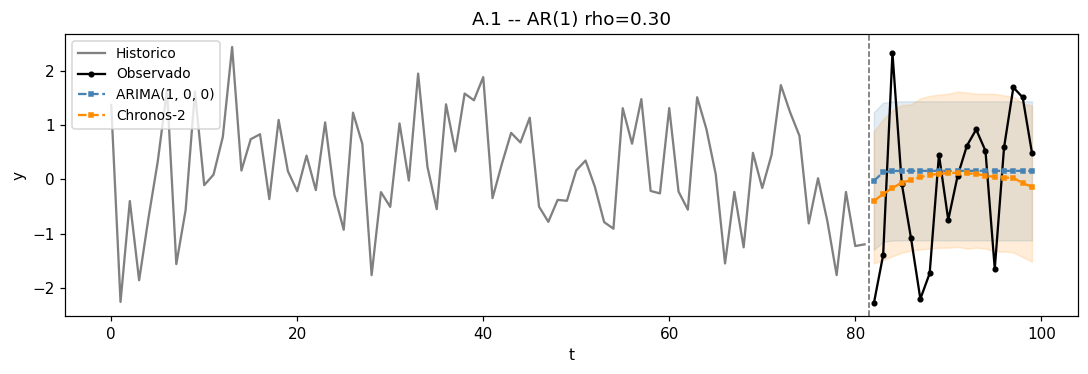

In [3]:
try:
    # A.1 -- AR(1) rho=0.30
    cl  = ARIMAModel((1, 0, 0))
    dgp = ARpDGP(phis=[0.3], sigma=1.0, seed=SEED)
    verify_dgp("A.1 -- AR(1) rho=0.30", dgp, {}, cl, CHECKS_AR)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="A.1")
    log("\n" + "="*60 + "\nA.1 -- AR(1) rho=0.30\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(1, 0, 0)")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="A.1 -- AR(1) rho=0.30")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA A.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:06:07  ────────────────────────────────────────────────────────────
19:06:07  VERIFICACION DGP: A.2 -- AR(1) rho=0.90
19:06:07  ────────────────────────────────────────────────────────────
19:06:07    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:06:07    [FAIL] Media ~ 0: media=-0.2588, tol=+/-0.2101
19:06:07    [PASS] ACF[1] ~ phi1: ACF[1]=0.8962, phi1_DGP=0.9000, dif=0.0038
19:06:07    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [1.3366 1.1845 1.0475]
19:06:07    -> 1 FALLO(S)
19:06:07  Exp A.2: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:06:07    T=50 H=6, R=500: cargando exp_A_2_T50_R500.csv
19:06:07    T=100 H=18, R=500: cargando exp_A_2_T100_R500.csv
19:06:07    T=200 H=24, R=500: cargando exp_A_2_T200_R500.csv
19:06:07  
A.2 -- AR(1) rho=0.90


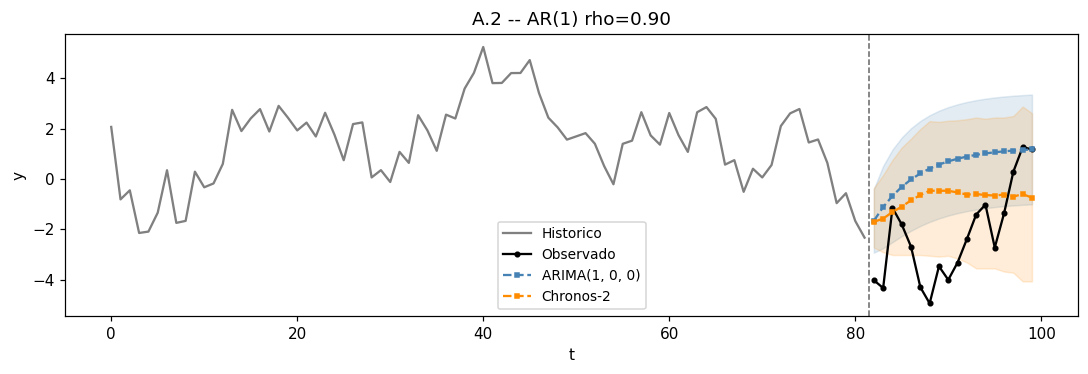

In [4]:
try:
    # A.2 -- AR(1) rho=0.90
    cl  = ARIMAModel((1, 0, 0))
    dgp = ARpDGP(phis=[0.9], sigma=1.0, seed=SEED)
    verify_dgp("A.2 -- AR(1) rho=0.90", dgp, {}, cl, CHECKS_AR)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="A.2")
    log("\n" + "="*60 + "\nA.2 -- AR(1) rho=0.90\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(1, 0, 0)")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="A.2 -- AR(1) rho=0.90")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA A.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:06:09  ────────────────────────────────────────────────────────────
19:06:09  VERIFICACION DGP: A.3 -- AR(2) rho=0.30
19:06:09  ────────────────────────────────────────────────────────────
19:06:09    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:06:09    [PASS] Media ~ 0: media=-0.0433, tol=+/-0.0990
19:06:09    [PASS] ACF[1] ~ phi1: ACF[1]=0.3206, phi1_DGP=0.3000, dif=0.0206
19:06:09    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [0.1481 0.0521 0.0109]
19:06:09    -> TODAS LAS VERIFICACIONES PASARON
19:06:09  Exp A.3: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:06:09    T=50 H=6, R=500: cargando exp_A_3_T50_R500.csv
19:06:09    T=100 H=18, R=500: cargando exp_A_3_T100_R500.csv
19:06:10    T=200 H=24, R=500: cargando exp_A_3_T200_R500.csv
19:06:10  
A.3 -- AR(2) rho=0.30


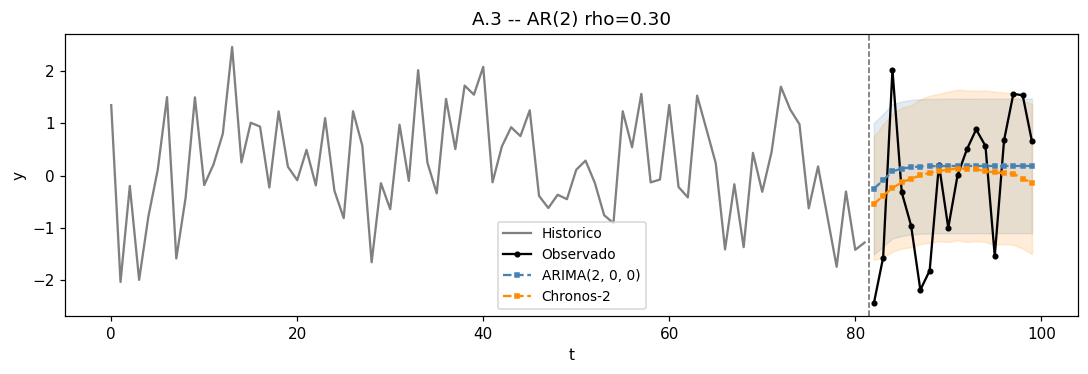

In [5]:
try:
    # A.3 -- AR(2) rho=0.30
    cl  = ARIMAModel((2, 0, 0))
    dgp = ARpDGP(phis=[0.3, 0.1], sigma=1.0, seed=SEED)
    verify_dgp("A.3 -- AR(2) rho=0.30", dgp, {}, cl, CHECKS_AR)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="A.3")
    log("\n" + "="*60 + "\nA.3 -- AR(2) rho=0.30\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(2, 0, 0)")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="A.3 -- AR(2) rho=0.30")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA A.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:06:11  ────────────────────────────────────────────────────────────
19:06:11  VERIFICACION DGP: A.4 -- AR(2) rho=0.90
19:06:11  ────────────────────────────────────────────────────────────
19:06:11    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:06:11    [PASS] Media ~ 0: media=-0.0889, tol=+/-0.1426
19:06:11    [FAIL] ACF[1] ~ phi1: ACF[1]=0.7463, phi1_DGP=0.9000, dif=0.1537
19:06:12    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [0.3728 0.2251 0.1109]
19:06:12    -> 1 FALLO(S)
19:06:12  Exp A.4: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:06:12    T=50 H=6, R=500: cargando exp_A_4_T50_R500.csv
19:06:12    T=100 H=18, R=500: cargando exp_A_4_T100_R500.csv
19:06:12    T=200 H=24, R=500: cargando exp_A_4_T200_R500.csv
19:06:12  
A.4 -- AR(2) rho=0.90


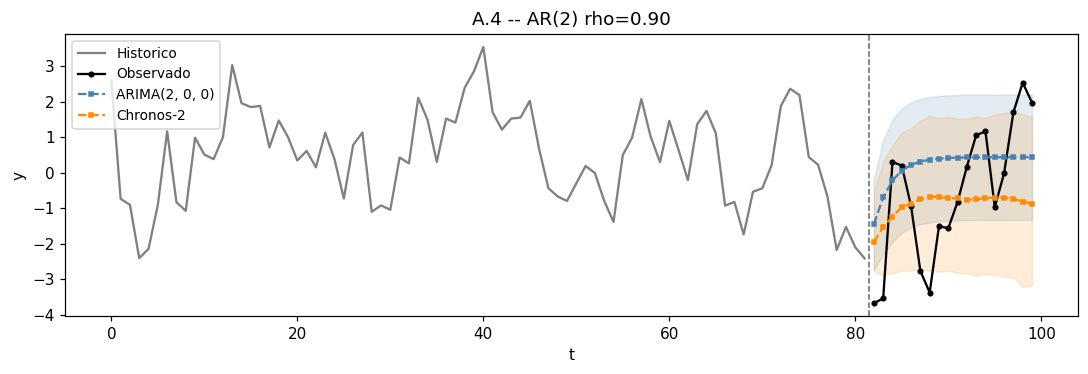

In [6]:
try:
    # A.4 -- AR(2) rho=0.90
    cl  = ARIMAModel((2, 0, 0))
    dgp = ARpDGP(phis=[0.9, -0.2], sigma=1.0, seed=SEED)
    verify_dgp("A.4 -- AR(2) rho=0.90", dgp, {}, cl, CHECKS_AR)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="A.4")
    log("\n" + "="*60 + "\nA.4 -- AR(2) rho=0.90\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(2, 0, 0)")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="A.4 -- AR(2) rho=0.90")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA A.4 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:06:13  ────────────────────────────────────────────────────────────
19:06:13  VERIFICACION DGP: A.5 -- AR(3) rho=0.30
19:06:13  ────────────────────────────────────────────────────────────
19:06:13    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:06:13    [PASS] Media ~ 0: media=-0.0474, tol=+/-0.0998
19:06:13    [PASS] ACF[1] ~ phi1: ACF[1]=0.3340, phi1_DGP=0.3000, dif=0.0340
19:06:13    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [0.0742 0.0721 0.0234]
19:06:13    -> TODAS LAS VERIFICACIONES PASARON
19:06:13  Exp A.5: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:06:13    T=50 H=6, R=500: cargando exp_A_5_T50_R500.csv
19:06:13    T=100 H=18, R=500: cargando exp_A_5_T100_R500.csv
19:06:13    T=200 H=24, R=500: cargando exp_A_5_T200_R500.csv
19:06:13  
A.5 -- AR(3) rho=0.30


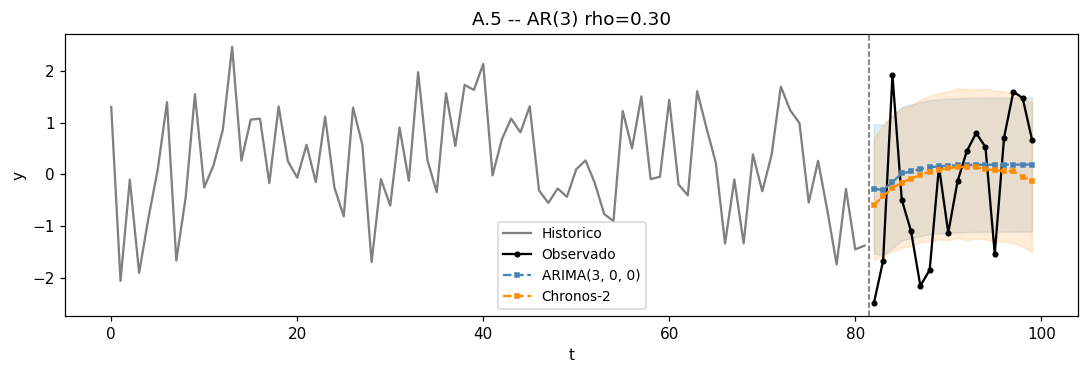

In [7]:
try:
    # A.5 -- AR(3) rho=0.30
    cl  = ARIMAModel((3, 0, 0))
    dgp = ARpDGP(phis=[0.3, 0.1, 0.05], sigma=1.0, seed=SEED)
    verify_dgp("A.5 -- AR(3) rho=0.30", dgp, {}, cl, CHECKS_AR)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="A.5")
    log("\n" + "="*60 + "\nA.5 -- AR(3) rho=0.30\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(3, 0, 0)")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="A.5 -- AR(3) rho=0.30")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA A.5 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:06:15  ────────────────────────────────────────────────────────────
19:06:15  VERIFICACION DGP: A.6 -- AR(3) rho=0.90
19:06:15  ────────────────────────────────────────────────────────────
19:06:15    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:06:15    [PASS] Media ~ 0: media=-0.1320, tol=+/-0.1562
19:06:15    [PASS] ACF[1] ~ phi1: ACF[1]=0.7979, phi1_DGP=0.9000, dif=0.1021
19:06:16    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [0.3541 0.2199 0.1725]
19:06:16    -> TODAS LAS VERIFICACIONES PASARON
19:06:16  Exp A.6: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:06:16    T=50 H=6, R=500: cargando exp_A_6_T50_R500.csv
19:06:16    T=100 H=18, R=500: cargando exp_A_6_T100_R500.csv
19:06:16    T=200 H=24, R=500: cargando exp_A_6_T200_R500.csv
19:06:16  
A.6 -- AR(3) rho=0.90


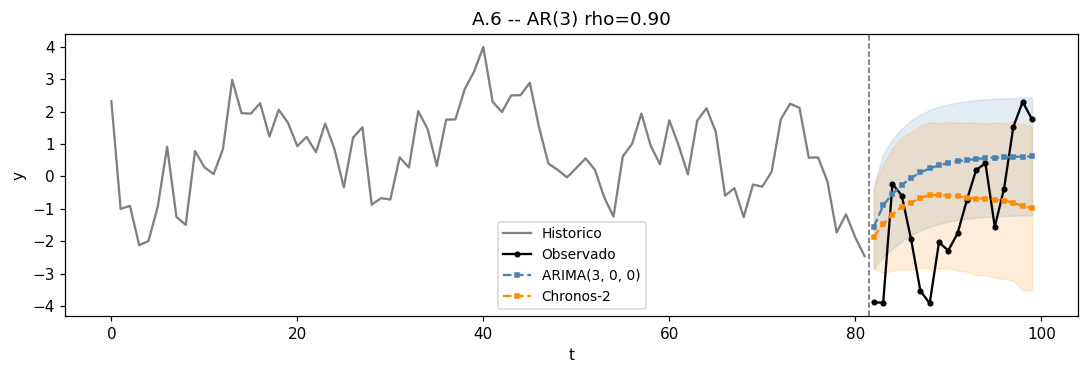

In [8]:
try:
    # A.6 -- AR(3) rho=0.90
    cl  = ARIMAModel((3, 0, 0))
    dgp = ARpDGP(phis=[0.9, -0.2, 0.1], sigma=1.0, seed=SEED)
    verify_dgp("A.6 -- AR(3) rho=0.90", dgp, {}, cl, CHECKS_AR)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="A.6")
    log("\n" + "="*60 + "\nA.6 -- AR(3) rho=0.90\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(3, 0, 0)")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="A.6 -- AR(3) rho=0.90")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA A.6 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:06:17  ────────────────────────────────────────────────────────────
19:06:17  VERIFICACION DGP: A.7 -- AR(4) rho=0.30
19:06:17  ────────────────────────────────────────────────────────────
19:06:17    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:06:17    [PASS] Media ~ 0: media=-0.0492, tol=+/-0.1001
19:06:17    [PASS] ACF[1] ~ phi1: ACF[1]=0.3382, phi1_DGP=0.3000, dif=0.0382
19:06:17    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [0.0799 0.0326 0.0355]
19:06:17    -> TODAS LAS VERIFICACIONES PASARON
19:06:17  Exp A.7: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:06:17    T=50 H=6, R=500: cargando exp_A_7_T50_R500.csv
19:06:18    T=100 H=18, R=500: cargando exp_A_7_T100_R500.csv
19:06:18    T=200 H=24, R=500: cargando exp_A_7_T200_R500.csv
19:06:18  
A.7 -- AR(4) rho=0.30


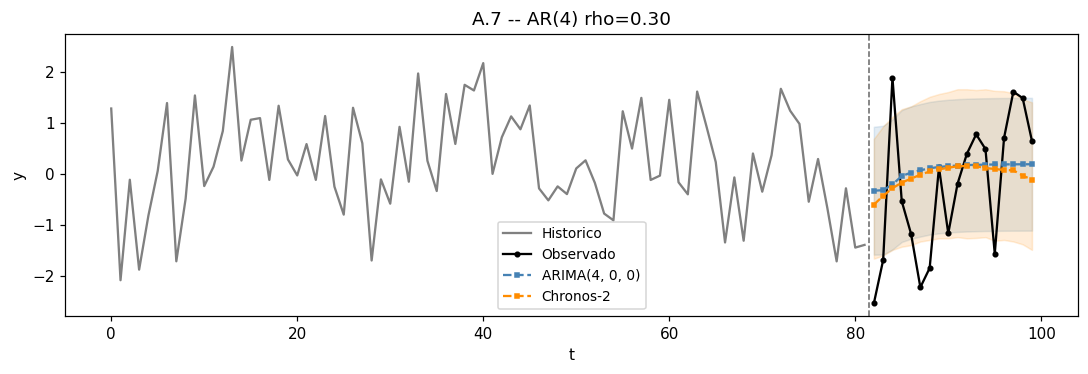

In [9]:
try:
    # A.7 -- AR(4) rho=0.30
    cl  = ARIMAModel((4, 0, 0))
    dgp = ARpDGP(phis=[0.3, 0.1, 0.05, 0.02], sigma=1.0, seed=SEED)
    verify_dgp("A.7 -- AR(4) rho=0.30", dgp, {}, cl, CHECKS_AR)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="A.7")
    log("\n" + "="*60 + "\nA.7 -- AR(4) rho=0.30\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(4, 0, 0)")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="A.7 -- AR(4) rho=0.30")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA A.7 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:06:19  ────────────────────────────────────────────────────────────
19:06:19  VERIFICACION DGP: A.8 -- AR(4) rho=0.90
19:06:19  ────────────────────────────────────────────────────────────
19:06:19    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:06:19    [PASS] Media ~ 0: media=-0.1066, tol=+/-0.1497
19:06:19    [PASS] ACF[1] ~ phi1: ACF[1]=0.7770, phi1_DGP=0.9000, dif=0.1230
19:06:19    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [0.2051 0.1284 0.0906]
19:06:19    -> TODAS LAS VERIFICACIONES PASARON
19:06:19  Exp A.8: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:06:19    T=50 H=6, R=500: cargando exp_A_8_T50_R500.csv
19:06:19    T=100 H=18, R=500: cargando exp_A_8_T100_R500.csv
19:06:19    T=200 H=24, R=500: cargando exp_A_8_T200_R500.csv
19:06:19  
A.8 -- AR(4) rho=0.90


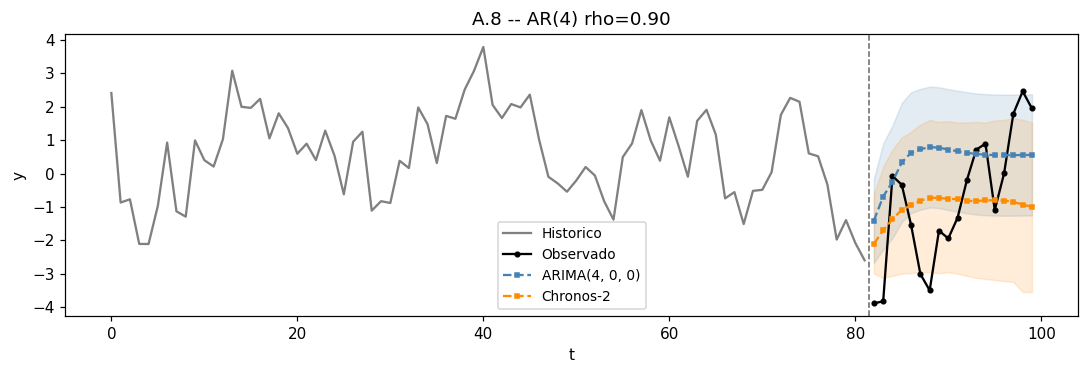

In [10]:
try:
    # A.8 -- AR(4) rho=0.90
    cl  = ARIMAModel((4, 0, 0))
    dgp = ARpDGP(phis=[0.9, -0.2, 0.1, -0.05], sigma=1.0, seed=SEED)
    verify_dgp("A.8 -- AR(4) rho=0.90", dgp, {}, cl, CHECKS_AR)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="A.8")
    log("\n" + "="*60 + "\nA.8 -- AR(4) rho=0.90\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(4, 0, 0)")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="A.8 -- AR(4) rho=0.90")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA A.8 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:06:21  ────────────────────────────────────────────────────────────
19:06:21  VERIFICACION DGP: A.9 -- MA(1) theta=0.30
19:06:21  ────────────────────────────────────────────────────────────
19:06:21    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:06:21    [PASS] Media ~ 0: media=-0.0311, tol=+/-0.0961
19:06:21    [PASS] Corte ACF en lag q: |ACF[2]|=0.0103, umbral=2/sqrt(T)=0.0632
19:06:21    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [-0.1222 -0.0123 -0.0123]
19:06:21    -> TODAS LAS VERIFICACIONES PASARON
19:06:21  Exp A.9: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:06:21    T=50 H=6, R=500: cargando exp_A_9_T50_R500.csv
19:06:21    T=100 H=18, R=500: cargando exp_A_9_T100_R500.csv
19:06:21    T=200 H=24, R=500: cargando exp_A_9_T200_R500.csv
19:06:21  
A.9 -- MA(1) theta=0.30


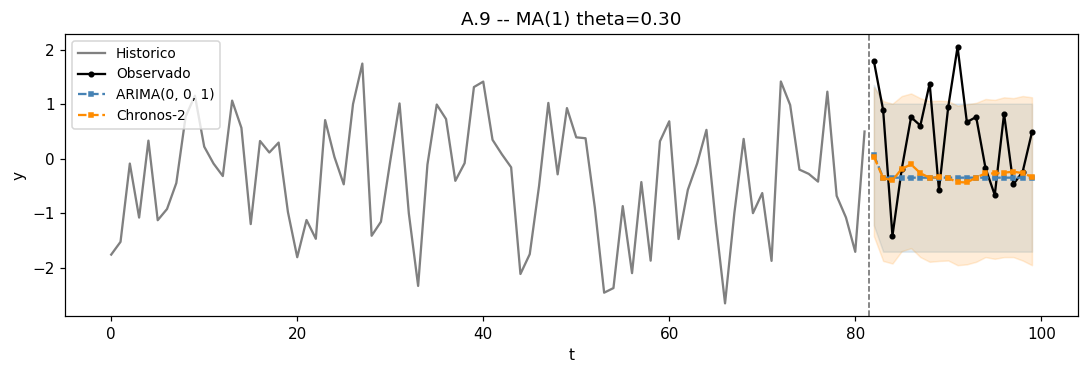

In [11]:
try:
    # A.9 -- MA(1) theta=0.30
    cl  = ARIMAModel((0, 0, 1))
    dgp = MAqDGP(thetas=[0.3], sigma=1.0, seed=SEED)
    verify_dgp("A.9 -- MA(1) theta=0.30", dgp, {}, cl, CHECKS_MA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="A.9")
    log("\n" + "="*60 + "\nA.9 -- MA(1) theta=0.30\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(0, 0, 1)")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="A.9 -- MA(1) theta=0.30")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA A.9 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:06:22  ────────────────────────────────────────────────────────────
19:06:22  VERIFICACION DGP: A.10 -- MA(1) theta=0.90
19:06:22  ────────────────────────────────────────────────────────────
19:06:22    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:06:22    [PASS] Media ~ 0: media=-0.0454, tol=+/-0.1231
19:06:22    [PASS] Corte ACF en lag q: |ACF[2]|=0.0116, umbral=2/sqrt(T)=0.0632
19:06:22    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [-0.3501 -0.0187 -0.0187]
19:06:22    -> TODAS LAS VERIFICACIONES PASARON
19:06:22  Exp A.10: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:06:22    T=50 H=6, R=500: cargando exp_A_10_T50_R500.csv
19:06:22    T=100 H=18, R=500: cargando exp_A_10_T100_R500.csv
19:06:22    T=200 H=24, R=500: cargando exp_A_10_T200_R500.csv
19:06:22  
A.10 -- MA(1) theta=0.90


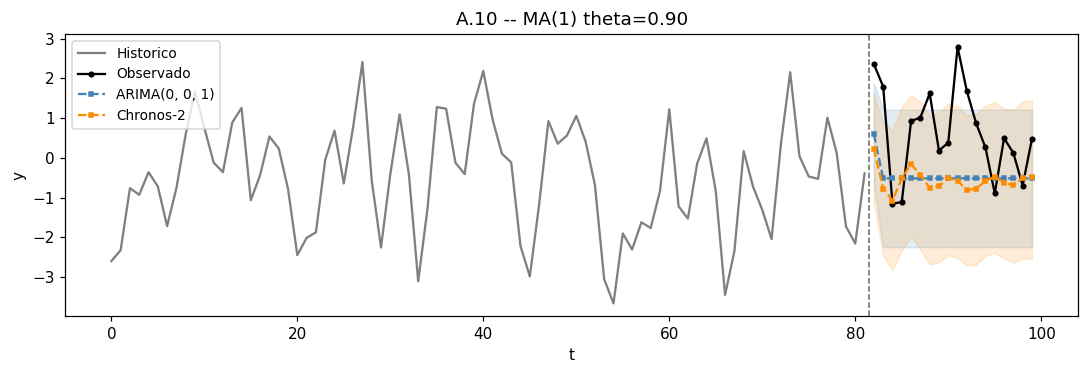

In [12]:
try:
    # A.10 -- MA(1) theta=0.90
    cl  = ARIMAModel((0, 0, 1))
    dgp = MAqDGP(thetas=[0.9], sigma=1.0, seed=SEED)
    verify_dgp("A.10 -- MA(1) theta=0.90", dgp, {}, cl, CHECKS_MA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="A.10")
    log("\n" + "="*60 + "\nA.10 -- MA(1) theta=0.90\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(0, 0, 1)")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="A.10 -- MA(1) theta=0.90")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA A.10 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:06:23  ────────────────────────────────────────────────────────────
19:06:23  VERIFICACION DGP: A.11 -- MA(2) theta=0.30
19:06:23  ────────────────────────────────────────────────────────────
19:06:23    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:06:23    [PASS] Media ~ 0: media=-0.0333, tol=+/-0.0964
19:06:23    [PASS] Corte ACF en lag q: |ACF[3]|=0.0131, umbral=2/sqrt(T)=0.0632
19:06:23    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [-0.1779 -0.042  -0.0134]
19:06:23    -> TODAS LAS VERIFICACIONES PASARON
19:06:23  Exp A.11: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:06:23    T=50 H=6, R=500: cargando exp_A_11_T50_R500.csv
19:06:23    T=100 H=18, R=500: cargando exp_A_11_T100_R500.csv
19:06:23    T=200 H=24, R=500: cargando exp_A_11_T200_R500.csv
19:06:23  
A.11 -- MA(2) theta=0.30


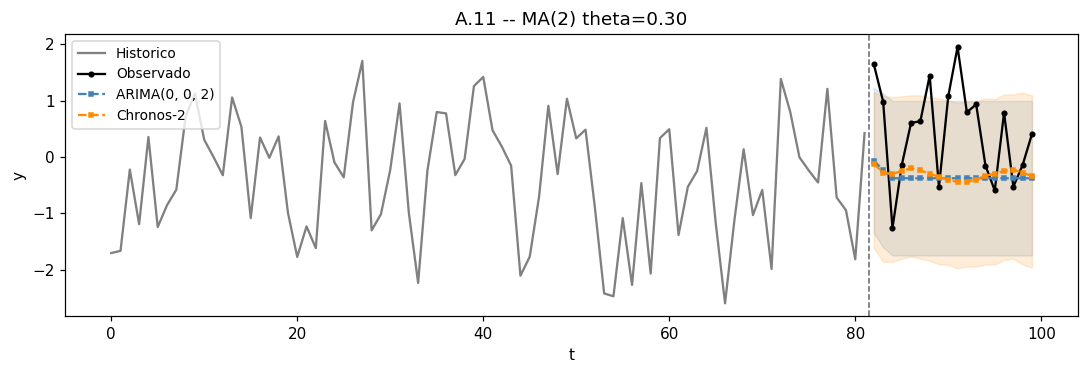

In [13]:
try:
    # A.11 -- MA(2) theta=0.30
    cl  = ARIMAModel((0, 0, 2))
    dgp = MAqDGP(thetas=[0.3, 0.1], sigma=1.0, seed=SEED)
    verify_dgp("A.11 -- MA(2) theta=0.30", dgp, {}, cl, CHECKS_MA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="A.11")
    log("\n" + "="*60 + "\nA.11 -- MA(2) theta=0.30\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(0, 0, 2)")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="A.11 -- MA(2) theta=0.30")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA A.11 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:06:24  ────────────────────────────────────────────────────────────
19:06:24  VERIFICACION DGP: A.12 -- MA(2) theta=0.90
19:06:24  ────────────────────────────────────────────────────────────
19:06:24    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:06:24    [PASS] Media ~ 0: media=-0.0476, tol=+/-0.1233
19:06:24    [PASS] Corte ACF en lag q: |ACF[3]|=0.0124, umbral=2/sqrt(T)=0.0632
19:06:25    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [-0.4307 -0.0499 -0.0195]
19:06:25    -> TODAS LAS VERIFICACIONES PASARON
19:06:25  Exp A.12: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:06:25    T=50 H=6, R=500: cargando exp_A_12_T50_R500.csv
19:06:25    T=100 H=18, R=500: cargando exp_A_12_T100_R500.csv
19:06:25    T=200 H=24, R=500: cargando exp_A_12_T200_R500.csv
19:06:25  
A.12 -- MA(2) theta=0.90


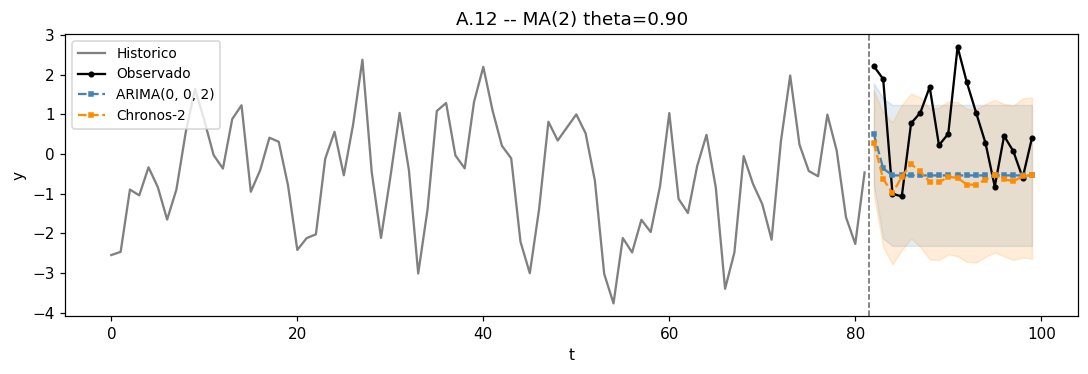

In [14]:
try:
    # A.12 -- MA(2) theta=0.90
    cl  = ARIMAModel((0, 0, 2))
    dgp = MAqDGP(thetas=[0.9, 0.1], sigma=1.0, seed=SEED)
    verify_dgp("A.12 -- MA(2) theta=0.90", dgp, {}, cl, CHECKS_MA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="A.12")
    log("\n" + "="*60 + "\nA.12 -- MA(2) theta=0.90\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(0, 0, 2)")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="A.12 -- MA(2) theta=0.90")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA A.12 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:06:26  ────────────────────────────────────────────────────────────
19:06:26  VERIFICACION DGP: A.13 -- MA(3) theta=0.30
19:06:26  ────────────────────────────────────────────────────────────
19:06:26    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:06:26    [PASS] Media ~ 0: media=-0.0322, tol=+/-0.0964
19:06:26    [PASS] Corte ACF en lag q: |ACF[4]|=0.0007, umbral=2/sqrt(T)=0.0632
19:06:26    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [-0.155  -0.002   0.0076]
19:06:26    -> TODAS LAS VERIFICACIONES PASARON
19:06:26  Exp A.13: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:06:26    T=50 H=6, R=500: cargando exp_A_13_T50_R500.csv
19:06:26    T=100 H=18, R=500: cargando exp_A_13_T100_R500.csv
19:06:26    T=200 H=24, R=500: cargando exp_A_13_T200_R500.csv
19:06:26  
A.13 -- MA(3) theta=0.30


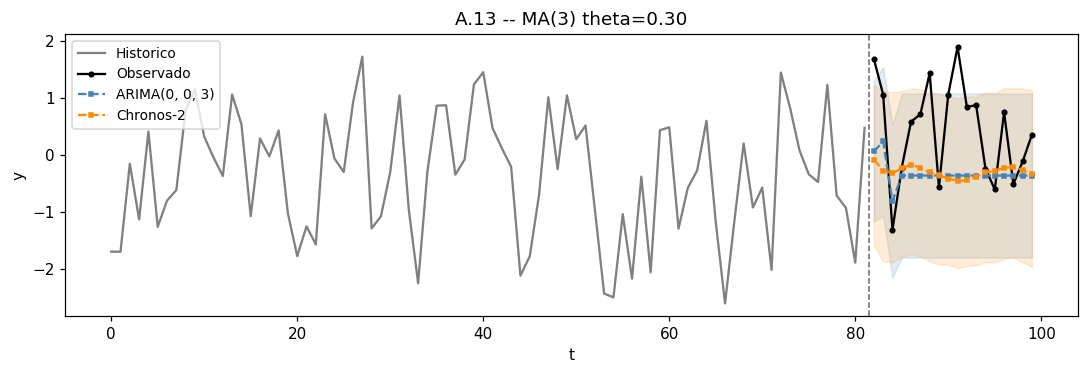

In [15]:
try:
    # A.13 -- MA(3) theta=0.30
    cl  = ARIMAModel((0, 0, 3))
    dgp = MAqDGP(thetas=[0.3, 0.1, -0.05], sigma=1.0, seed=SEED)
    verify_dgp("A.13 -- MA(3) theta=0.30", dgp, {}, cl, CHECKS_MA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="A.13")
    log("\n" + "="*60 + "\nA.13 -- MA(3) theta=0.30\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(0, 0, 3)")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="A.13 -- MA(3) theta=0.30")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA A.13 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:06:27  ────────────────────────────────────────────────────────────
19:06:27  VERIFICACION DGP: A.14 -- MA(3) theta=0.90
19:06:27  ────────────────────────────────────────────────────────────
19:06:28    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:06:28    [PASS] Media ~ 0: media=-0.0465, tol=+/-0.1233
19:06:28    [PASS] Corte ACF en lag q: |ACF[4]|=0.0021, umbral=2/sqrt(T)=0.0632
19:06:28    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [-0.3819  0.0189  0.0111]
19:06:28    -> TODAS LAS VERIFICACIONES PASARON
19:06:28  Exp A.14: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:06:28    T=50 H=6, R=500: cargando exp_A_14_T50_R500.csv
19:06:28    T=100 H=18, R=500: cargando exp_A_14_T100_R500.csv
19:06:28    T=200 H=24, R=500: cargando exp_A_14_T200_R500.csv
19:06:28  
A.14 -- MA(3) theta=0.90


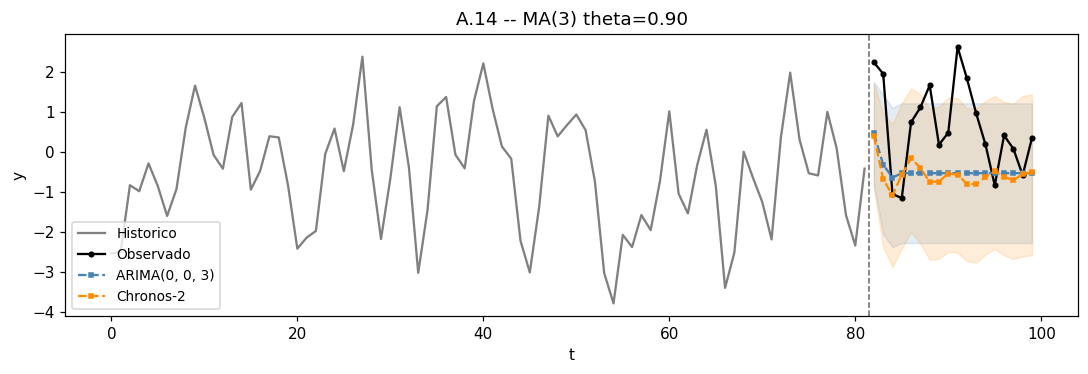

In [16]:
try:
    # A.14 -- MA(3) theta=0.90
    cl  = ARIMAModel((0, 0, 3))
    dgp = MAqDGP(thetas=[0.9, 0.1, -0.05], sigma=1.0, seed=SEED)
    verify_dgp("A.14 -- MA(3) theta=0.90", dgp, {}, cl, CHECKS_MA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="A.14")
    log("\n" + "="*60 + "\nA.14 -- MA(3) theta=0.90\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(0, 0, 3)")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="A.14 -- MA(3) theta=0.90")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA A.14 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:06:29  ────────────────────────────────────────────────────────────
19:06:29  VERIFICACION DGP: A.15 -- MA(4) theta=0.30
19:06:29  ────────────────────────────────────────────────────────────
19:06:29    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:06:29    [PASS] Media ~ 0: media=-0.0326, tol=+/-0.0965
19:06:29    [PASS] Corte ACF en lag q: |ACF[5]|=0.0136, umbral=2/sqrt(T)=0.0632
19:06:30    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [-0.1748 -0.0126 -0.0109]
19:06:30    -> TODAS LAS VERIFICACIONES PASARON
19:06:30  Exp A.15: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:06:30    T=50 H=6, R=500: cargando exp_A_15_T50_R500.csv
19:06:30    T=100 H=18, R=500: cargando exp_A_15_T100_R500.csv
19:06:30    T=200 H=24, R=500: cargando exp_A_15_T200_R500.csv
19:06:30  
A.15 -- MA(4) theta=0.30


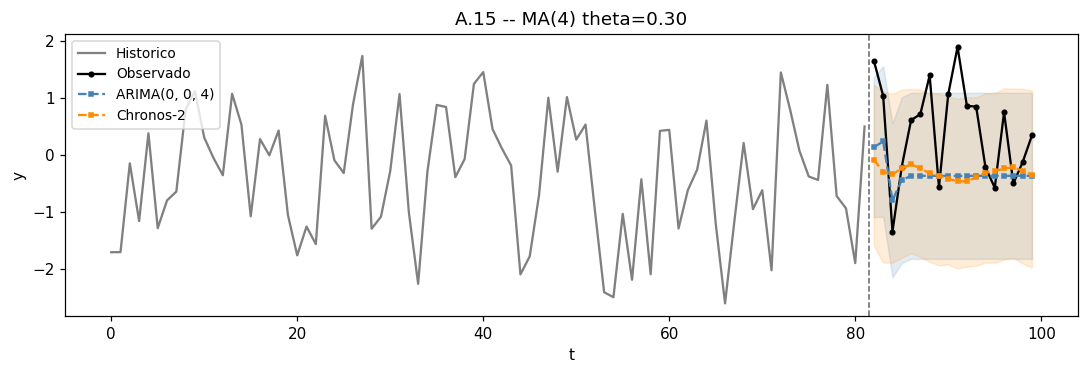

In [17]:
try:
    # A.15 -- MA(4) theta=0.30
    cl  = ARIMAModel((0, 0, 4))
    dgp = MAqDGP(thetas=[0.3, 0.1, -0.05, 0.02], sigma=1.0, seed=SEED)
    verify_dgp("A.15 -- MA(4) theta=0.30", dgp, {}, cl, CHECKS_MA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="A.15")
    log("\n" + "="*60 + "\nA.15 -- MA(4) theta=0.30\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(0, 0, 4)")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="A.15 -- MA(4) theta=0.30")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA A.15 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:06:31  ────────────────────────────────────────────────────────────
19:06:31  VERIFICACION DGP: A.16 -- MA(4) theta=0.90
19:06:31  ────────────────────────────────────────────────────────────
19:06:31    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:06:31    [PASS] Media ~ 0: media=-0.0469, tol=+/-0.1234
19:06:31    [PASS] Corte ACF en lag q: |ACF[5]|=0.0095, umbral=2/sqrt(T)=0.0632
19:06:32    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [-0.3979 -0.0077 -0.0233]
19:06:32    -> TODAS LAS VERIFICACIONES PASARON
19:06:32  Exp A.16: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:06:32    T=50 H=6, R=500: cargando exp_A_16_T50_R500.csv
19:06:32    T=100 H=18, R=500: cargando exp_A_16_T100_R500.csv
19:06:32    T=200 H=24, R=500: cargando exp_A_16_T200_R500.csv
19:06:32  
A.16 -- MA(4) theta=0.90


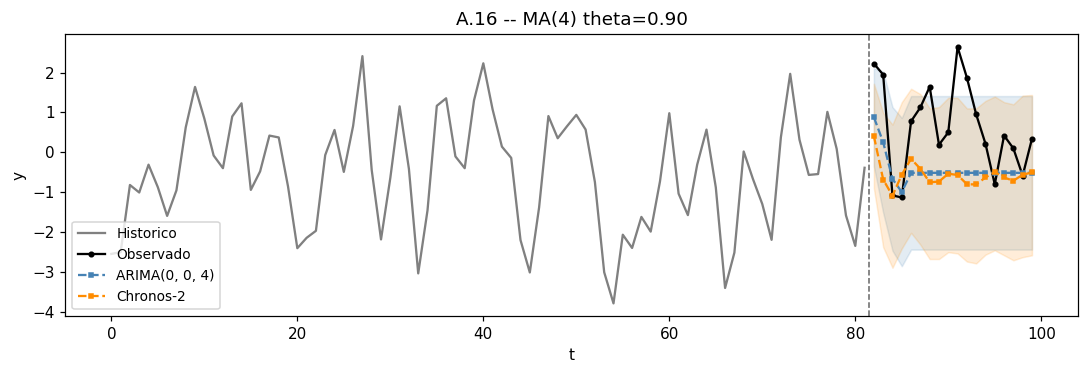

In [18]:
try:
    # A.16 -- MA(4) theta=0.90
    cl  = ARIMAModel((0, 0, 4))
    dgp = MAqDGP(thetas=[0.9, 0.1, -0.05, 0.02], sigma=1.0, seed=SEED)
    verify_dgp("A.16 -- MA(4) theta=0.90", dgp, {}, cl, CHECKS_MA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="A.16")
    log("\n" + "="*60 + "\nA.16 -- MA(4) theta=0.90\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(0, 0, 4)")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="A.16 -- MA(4) theta=0.90")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA A.16 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:06:33  ────────────────────────────────────────────────────────────
19:06:33  VERIFICACION DGP: A.17 -- ARMA(1,1) rho=0.30
19:06:33  ────────────────────────────────────────────────────────────
19:06:33    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:06:33    [FAIL] AIC ARMA < baseline: ARIMA.fit() got an unexpected keyword argument 'disp'
19:06:33    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [ 0.1385  0.0204 -0.0156]
19:06:33    -> 1 FALLO(S)
19:06:33  Exp A.17: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:06:33    T=50 H=6, R=500: cargando exp_A_17_T50_R500.csv
19:06:33    T=100 H=18, R=500: cargando exp_A_17_T100_R500.csv
19:06:33    T=200 H=24, R=500: cargando exp_A_17_T200_R500.csv
19:06:33  
A.17 -- ARMA(1,1) rho=0.30


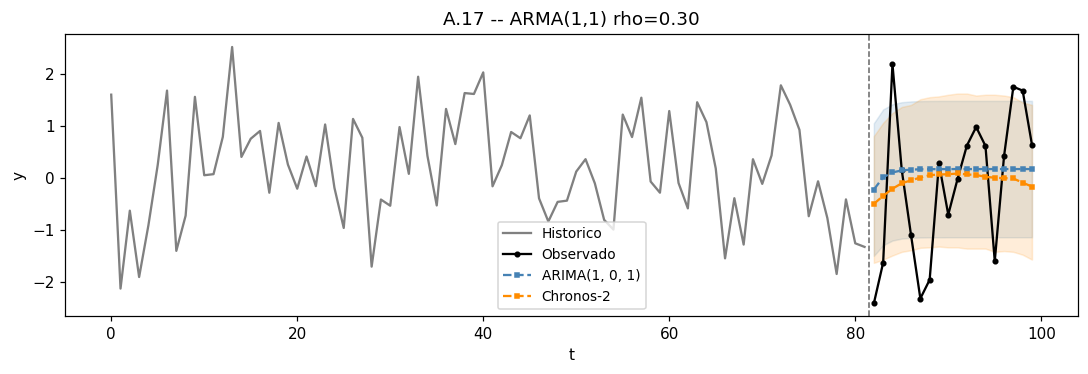

In [19]:
try:
    # A.17 -- ARMA(1,1) rho=0.30
    cl  = ARIMAModel((1, 0, 1))
    dgp = ARMApqDGP(phis=[0.3], thetas=[0.1], sigma=1.0, seed=SEED)
    verify_dgp("A.17 -- ARMA(1,1) rho=0.30", dgp, {}, cl, CHECKS_ARMA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="A.17")
    log("\n" + "="*60 + "\nA.17 -- ARMA(1,1) rho=0.30\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(1, 0, 1)")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="A.17 -- ARMA(1,1) rho=0.30")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA A.17 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:06:34  ────────────────────────────────────────────────────────────
19:06:34  VERIFICACION DGP: A.18 -- ARMA(1,1) rho=0.90
19:06:34  ────────────────────────────────────────────────────────────
19:06:34    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:06:34    [FAIL] AIC ARMA < baseline: ARIMA.fit() got an unexpected keyword argument 'disp'
19:06:34    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [1.8007 1.6037 1.4255]
19:06:34    -> 1 FALLO(S)
19:06:34  Exp A.18: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:06:34    T=50 H=6, R=500: cargando exp_A_18_T50_R500.csv
19:06:34    T=100 H=18, R=500: cargando exp_A_18_T100_R500.csv
19:06:34    T=200 H=24, R=500: cargando exp_A_18_T200_R500.csv
19:06:34  
A.18 -- ARMA(1,1) rho=0.90


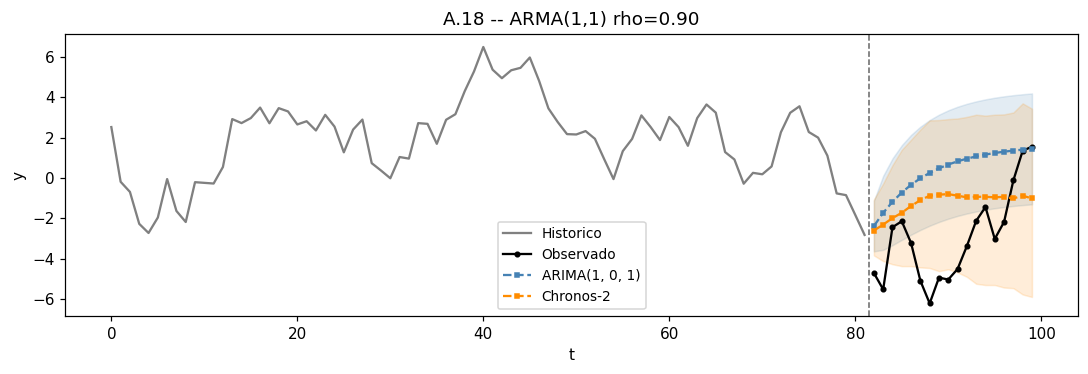

In [20]:
try:
    # A.18 -- ARMA(1,1) rho=0.90
    cl  = ARIMAModel((1, 0, 1))
    dgp = ARMApqDGP(phis=[0.9], thetas=[0.3], sigma=1.0, seed=SEED)
    verify_dgp("A.18 -- ARMA(1,1) rho=0.90", dgp, {}, cl, CHECKS_ARMA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="A.18")
    log("\n" + "="*60 + "\nA.18 -- ARMA(1,1) rho=0.90\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(1, 0, 1)")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="A.18 -- ARMA(1,1) rho=0.90")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA A.18 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:06:35  ────────────────────────────────────────────────────────────
19:06:35  VERIFICACION DGP: A.19 -- ARMA(2,2) rho=0.30
19:06:35  ────────────────────────────────────────────────────────────
19:06:35    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:06:35    [FAIL] AIC ARMA < baseline: ARIMA.fit() got an unexpected keyword argument 'disp'
19:06:37    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [0.1598 0.0535 0.0405]
19:06:37    -> 1 FALLO(S)
19:06:37  Exp A.19: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:06:37    T=50 H=6, R=500: cargando exp_A_19_T50_R500.csv
19:06:37    T=100 H=18, R=500: cargando exp_A_19_T100_R500.csv
19:06:37    T=200 H=24, R=500: cargando exp_A_19_T200_R500.csv
19:06:37  
A.19 -- ARMA(2,2) rho=0.30


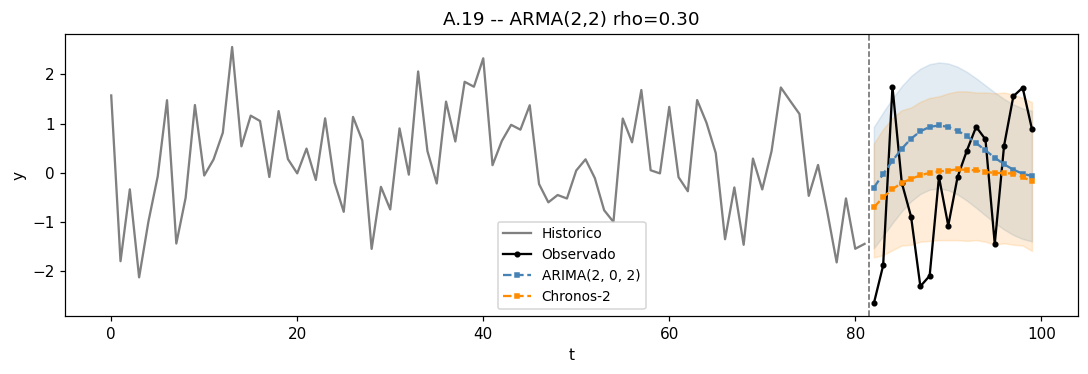

In [21]:
try:
    # A.19 -- ARMA(2,2) rho=0.30
    cl  = ARIMAModel((2, 0, 2))
    dgp = ARMApqDGP(phis=[0.3, 0.1], thetas=[0.1, 0.05], sigma=1.0, seed=SEED)
    verify_dgp("A.19 -- ARMA(2,2) rho=0.30", dgp, {}, cl, CHECKS_ARMA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="A.19")
    log("\n" + "="*60 + "\nA.19 -- ARMA(2,2) rho=0.30\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(2, 0, 2)")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="A.19 -- ARMA(2,2) rho=0.30")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA A.19 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:06:39  ────────────────────────────────────────────────────────────
19:06:39  VERIFICACION DGP: A.20 -- ARMA(2,2) rho=0.90
19:06:39  ────────────────────────────────────────────────────────────
19:06:39    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:06:39    [FAIL] AIC ARMA < baseline: ARIMA.fit() got an unexpected keyword argument 'disp'
19:06:40    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [0.5176 0.2824 0.1324]
19:06:40    -> 1 FALLO(S)
19:06:40  Exp A.20: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:06:40    T=50 H=6, R=500: cargando exp_A_20_T50_R500.csv
19:06:40    T=100 H=18, R=500: cargando exp_A_20_T100_R500.csv
19:06:40    T=200 H=24, R=500: cargando exp_A_20_T200_R500.csv
19:06:40  
A.20 -- ARMA(2,2) rho=0.90


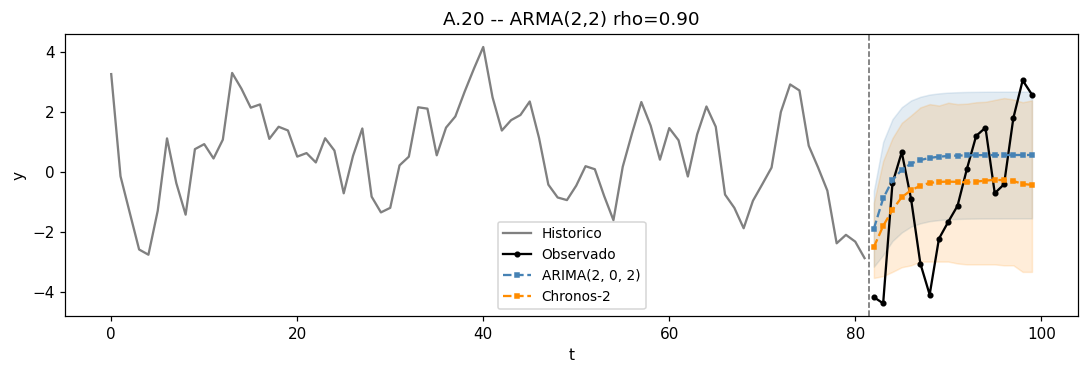

In [22]:
try:
    # A.20 -- ARMA(2,2) rho=0.90
    cl  = ARIMAModel((2, 0, 2))
    dgp = ARMApqDGP(phis=[0.9, -0.2], thetas=[0.3, -0.1], sigma=1.0, seed=SEED)
    verify_dgp("A.20 -- ARMA(2,2) rho=0.90", dgp, {}, cl, CHECKS_ARMA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="A.20")
    log("\n" + "="*60 + "\nA.20 -- ARMA(2,2) rho=0.90\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(2, 0, 2)")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="A.20 -- ARMA(2,2) rho=0.90")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA A.20 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:06:41  ────────────────────────────────────────────────────────────
19:06:41  VERIFICACION DGP: A.21 -- ARMA(1,4) rho=0.30
19:06:41  ────────────────────────────────────────────────────────────
19:06:41    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:06:41    [FAIL] AIC ARMA < baseline: ARIMA.fit() got an unexpected keyword argument 'disp'
19:06:43    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [ 0.2074 -0.003  -0.0186]
19:06:43    -> 1 FALLO(S)
19:06:43  Exp A.21: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:06:43    T=50 H=6, R=500: cargando exp_A_21_T50_R500.csv
19:06:43    T=100 H=18, R=500: cargando exp_A_21_T100_R500.csv
19:06:43    T=200 H=24, R=500: cargando exp_A_21_T200_R500.csv
19:06:43  
A.21 -- ARMA(1,4) rho=0.30


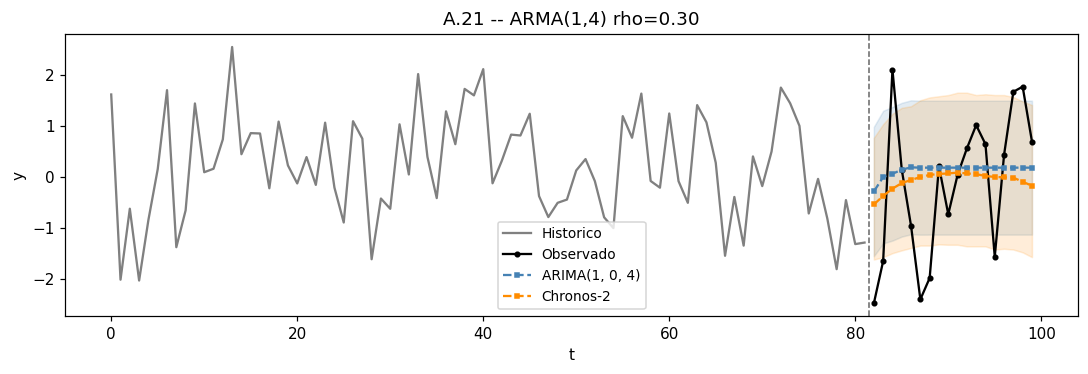

In [23]:
try:
    # A.21 -- ARMA(1,4) rho=0.30
    cl  = ARIMAModel((1, 0, 4))
    dgp = ARMApqDGP(phis=[0.3], thetas=[0.1, 0.05, -0.03, 0.01], sigma=1.0, seed=SEED)
    verify_dgp("A.21 -- ARMA(1,4) rho=0.30", dgp, {}, cl, CHECKS_ARMA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="A.21")
    log("\n" + "="*60 + "\nA.21 -- ARMA(1,4) rho=0.30\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(1, 0, 4)")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="A.21 -- ARMA(1,4) rho=0.30")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA A.21 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:06:45  ────────────────────────────────────────────────────────────
19:06:45  VERIFICACION DGP: A.22 -- ARMA(1,4) rho=0.90
19:06:45  ────────────────────────────────────────────────────────────
19:06:45    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:06:45    [FAIL] AIC ARMA < baseline: ARIMA.fit() got an unexpected keyword argument 'disp'
19:06:46    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [1.6509 1.5193 1.3442]
19:06:46    -> 1 FALLO(S)
19:06:46  Exp A.22: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:06:46    T=50 H=6, R=500: cargando exp_A_22_T50_R500.csv
19:06:46    T=100 H=18, R=500: cargando exp_A_22_T100_R500.csv
19:06:46    T=200 H=24, R=500: cargando exp_A_22_T200_R500.csv
19:06:46  
A.22 -- ARMA(1,4) rho=0.90


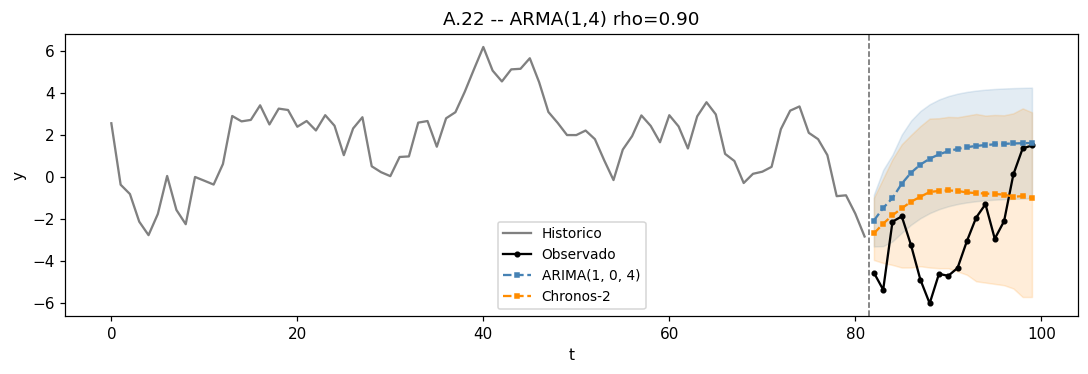

In [24]:
try:
    # A.22 -- ARMA(1,4) rho=0.90
    cl  = ARIMAModel((1, 0, 4))
    dgp = ARMApqDGP(phis=[0.9], thetas=[0.3, -0.1, 0.05, -0.02], sigma=1.0, seed=SEED)
    verify_dgp("A.22 -- ARMA(1,4) rho=0.90", dgp, {}, cl, CHECKS_ARMA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="A.22")
    log("\n" + "="*60 + "\nA.22 -- ARMA(1,4) rho=0.90\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(1, 0, 4)")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="A.22 -- ARMA(1,4) rho=0.90")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA A.22 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:06:47  ────────────────────────────────────────────────────────────
19:06:47  VERIFICACION DGP: A.23 -- ARMA(4,1) rho=0.30
19:06:47  ────────────────────────────────────────────────────────────
19:06:47    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:06:47    [FAIL] AIC ARMA < baseline: ARIMA.fit() got an unexpected keyword argument 'disp'
19:06:49    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [0.0904 0.0299 0.0063]
19:06:49    -> 1 FALLO(S)
19:06:49  Exp A.23: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:06:49    T=50 H=6, R=500: cargando exp_A_23_T50_R500.csv
19:06:49    T=100 H=18, R=500: cargando exp_A_23_T100_R500.csv
19:06:49    T=200 H=24, R=500: cargando exp_A_23_T200_R500.csv
19:06:49  
A.23 -- ARMA(4,1) rho=0.30


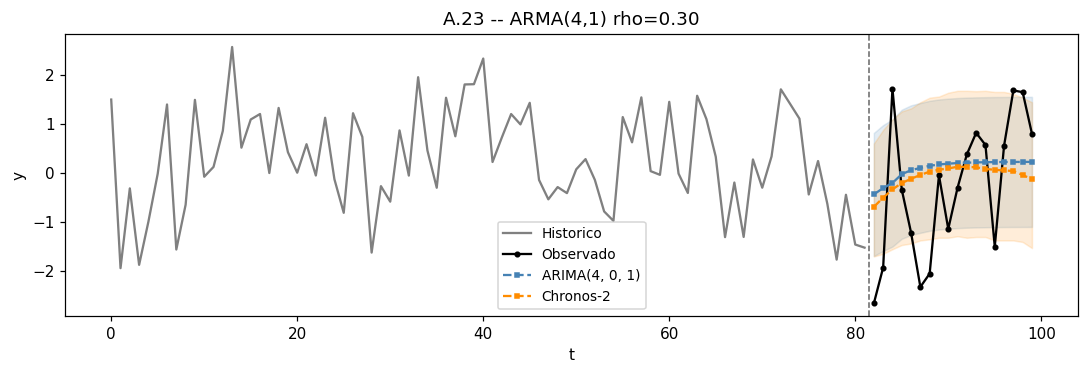

In [25]:
try:
    # A.23 -- ARMA(4,1) rho=0.30
    cl  = ARIMAModel((4, 0, 1))
    dgp = ARMApqDGP(phis=[0.3, 0.1, 0.05, 0.02], thetas=[0.1], sigma=1.0, seed=SEED)
    verify_dgp("A.23 -- ARMA(4,1) rho=0.30", dgp, {}, cl, CHECKS_ARMA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="A.23")
    log("\n" + "="*60 + "\nA.23 -- ARMA(4,1) rho=0.30\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(4, 0, 1)")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="A.23 -- ARMA(4,1) rho=0.30")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA A.23 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:06:50  ────────────────────────────────────────────────────────────
19:06:50  VERIFICACION DGP: A.24 -- ARMA(4,1) rho=0.90
19:06:50  ────────────────────────────────────────────────────────────
19:06:51    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:06:51    [FAIL] AIC ARMA < baseline: ARIMA.fit() got an unexpected keyword argument 'disp'
19:06:51    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [0.3007 0.184  0.1181]
19:06:51    -> 1 FALLO(S)
19:06:51  Exp A.24: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:06:51    T=50 H=6, R=500: cargando exp_A_24_T50_R500.csv
19:06:51    T=100 H=18, R=500: cargando exp_A_24_T100_R500.csv
19:06:51    T=200 H=24, R=500: cargando exp_A_24_T200_R500.csv
19:06:51  
A.24 -- ARMA(4,1) rho=0.90


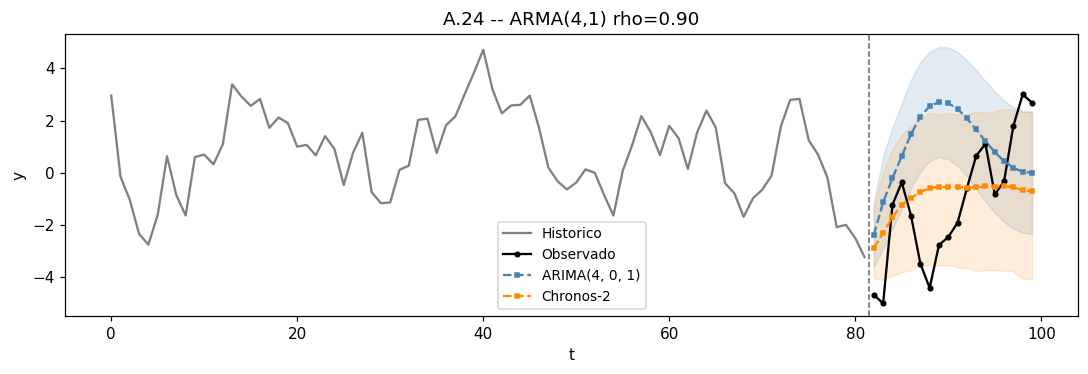

In [26]:
try:
    # A.24 -- ARMA(4,1) rho=0.90
    cl  = ARIMAModel((4, 0, 1))
    dgp = ARMApqDGP(phis=[0.9, -0.2, 0.1, -0.05], thetas=[0.3], sigma=1.0, seed=SEED)
    verify_dgp("A.24 -- ARMA(4,1) rho=0.90", dgp, {}, cl, CHECKS_ARMA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="A.24")
    log("\n" + "="*60 + "\nA.24 -- ARMA(4,1) rho=0.90\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(4, 0, 1)")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="A.24 -- ARMA(4,1) rho=0.90")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA A.24 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

---
## Bloque B — ARMA con tendencia deterministica (48 experimentos)

DGP: `Y_t = alpha + delta*t + ARMA_t`  
Tendencia leve: delta=0.02 (B.1-B.24) | Tendencia fuerte: delta=0.10 (B.25-B.48)  
Modelo clasico: ARIMA(p,0,q)+trend (trend='ct')

19:06:53  ────────────────────────────────────────────────────────────
19:06:53  VERIFICACION DGP: B.1 -- AR(1) rho=0.30 (delta=0.02)
19:06:53  ────────────────────────────────────────────────────────────
19:06:53    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:06:53    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [16.0734 15.9972 15.9902]
19:06:53    -> TODAS LAS VERIFICACIONES PASARON
19:06:53  Exp B.1: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:06:53    T=50 H=6, R=500: cargando exp_B_1_T50_R500.csv
19:06:53    T=100 H=18, R=500: cargando exp_B_1_T100_R500.csv
19:06:53    T=200 H=24, R=500: cargando exp_B_1_T200_R500.csv
19:06:53  
B.1 -- AR(1) rho=0.30 (delta=0.02)


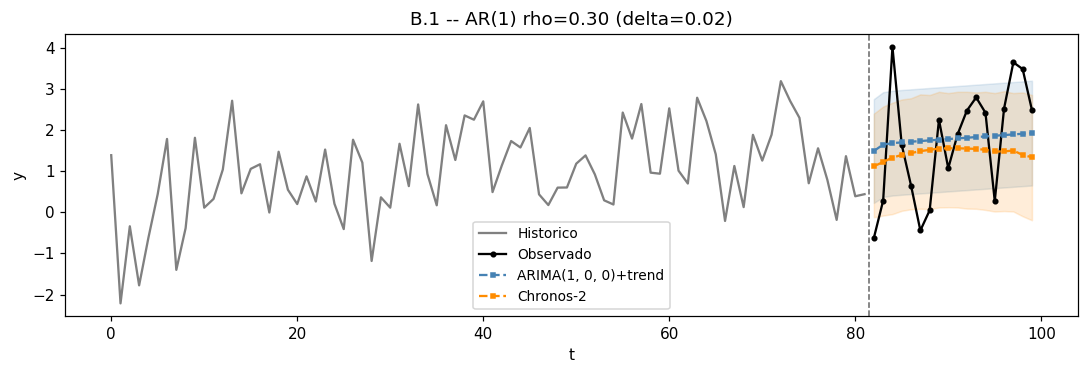

In [27]:
try:
    # B.1 -- AR(1) rho=0.30  [tendencia leve delta=0.02]
    cl  = ARIMAWithTrendModel((1, 0, 0), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.3], thetas=[], delta=0.02, sigma=1.0, seed=SEED)
    verify_dgp("B.1 -- AR(1) rho=0.30 (delta=0.02)", dgp, {}, cl, CHECKS_AR_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.1")
    log("\n" + "="*60 + "\nB.1 -- AR(1) rho=0.30 (delta=0.02)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(1, 0, 0)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.1 -- AR(1) rho=0.30 (delta=0.02)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:06:55  ────────────────────────────────────────────────────────────
19:06:55  VERIFICACION DGP: B.2 -- AR(1) rho=0.90 (delta=0.02)
19:06:55  ────────────────────────────────────────────────────────────
19:06:55    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:06:56    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [17.3189 17.1527 17.005 ]
19:06:56    -> TODAS LAS VERIFICACIONES PASARON
19:06:56  Exp B.2: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:06:56    T=50 H=6, R=500: cargando exp_B_2_T50_R500.csv
19:06:56    T=100 H=18, R=500: cargando exp_B_2_T100_R500.csv
19:06:56    T=200 H=24, R=500: cargando exp_B_2_T200_R500.csv
19:06:56  
B.2 -- AR(1) rho=0.90 (delta=0.02)


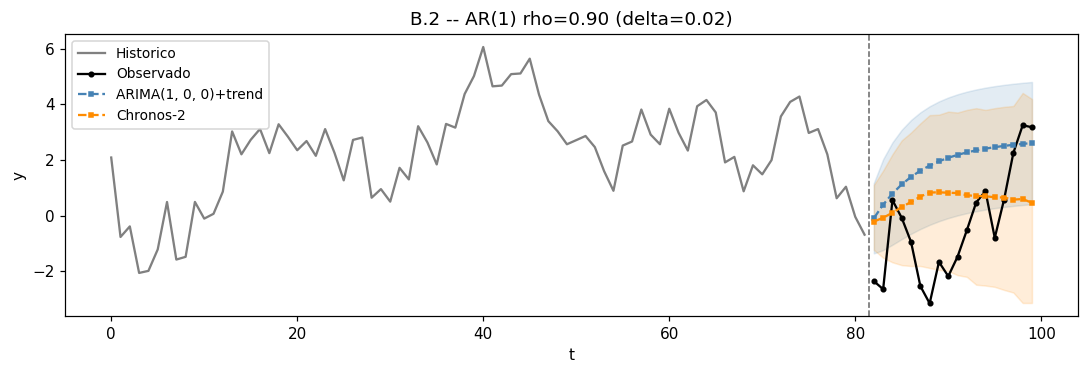

In [28]:
try:
    # B.2 -- AR(1) rho=0.90  [tendencia leve delta=0.02]
    cl  = ARIMAWithTrendModel((1, 0, 0), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.9], thetas=[], delta=0.02, sigma=1.0, seed=SEED)
    verify_dgp("B.2 -- AR(1) rho=0.90 (delta=0.02)", dgp, {}, cl, CHECKS_AR_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.2")
    log("\n" + "="*60 + "\nB.2 -- AR(1) rho=0.90 (delta=0.02)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(1, 0, 0)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.2 -- AR(1) rho=0.90 (delta=0.02)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:06:58  ────────────────────────────────────────────────────────────
19:06:58  VERIFICACION DGP: B.3 -- AR(2) rho=0.30 (delta=0.02)
19:06:58  ────────────────────────────────────────────────────────────
19:06:58    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:06:58    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [16.1305 16.0444 16.0163]
19:06:58    -> TODAS LAS VERIFICACIONES PASARON
19:06:58  Exp B.3: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:06:58    T=50 H=6, R=500: cargando exp_B_3_T50_R500.csv
19:06:58    T=100 H=18, R=500: cargando exp_B_3_T100_R500.csv
19:06:58    T=200 H=24, R=500: cargando exp_B_3_T200_R500.csv
19:06:58  
B.3 -- AR(2) rho=0.30 (delta=0.02)


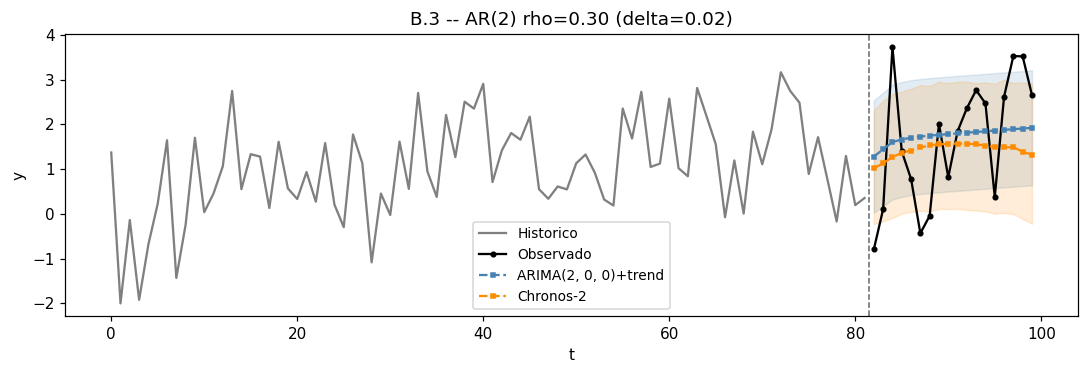

In [29]:
try:
    # B.3 -- AR(2) rho=0.30  [tendencia leve delta=0.02]
    cl  = ARIMAWithTrendModel((2, 0, 0), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.3, 0.1], thetas=[], delta=0.02, sigma=1.0, seed=SEED)
    verify_dgp("B.3 -- AR(2) rho=0.30 (delta=0.02)", dgp, {}, cl, CHECKS_AR_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.3")
    log("\n" + "="*60 + "\nB.3 -- AR(2) rho=0.30 (delta=0.02)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(2, 0, 0)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.3 -- AR(2) rho=0.30 (delta=0.02)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:07:00  ────────────────────────────────────────────────────────────
19:07:00  VERIFICACION DGP: B.4 -- AR(2) rho=0.90 (delta=0.02)
19:07:00  ────────────────────────────────────────────────────────────
19:07:00    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:07:01    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [16.3581 16.1998 16.0848]
19:07:01    -> TODAS LAS VERIFICACIONES PASARON
19:07:01  Exp B.4: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:07:01    T=50 H=6, R=500: cargando exp_B_4_T50_R500.csv
19:07:01    T=100 H=18, R=500: cargando exp_B_4_T100_R500.csv
19:07:01    T=200 H=24, R=500: cargando exp_B_4_T200_R500.csv
19:07:01  
B.4 -- AR(2) rho=0.90 (delta=0.02)


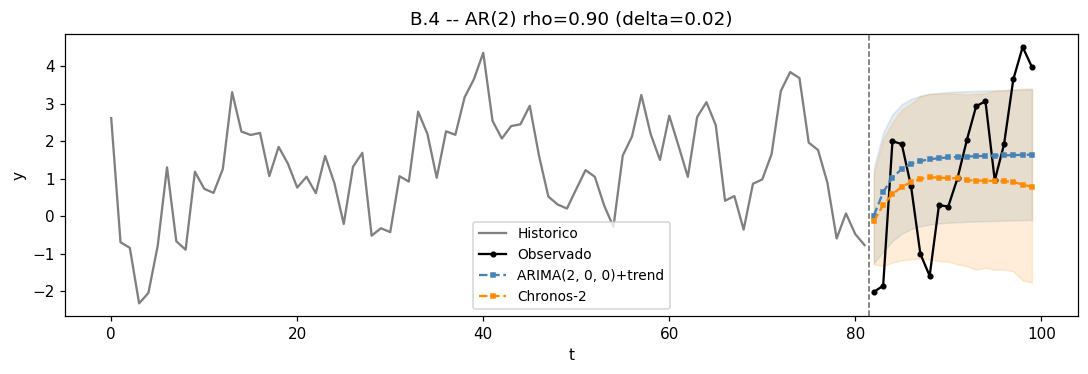

In [30]:
try:
    # B.4 -- AR(2) rho=0.90  [tendencia leve delta=0.02]
    cl  = ARIMAWithTrendModel((2, 0, 0), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.9, -0.2], thetas=[], delta=0.02, sigma=1.0, seed=SEED)
    verify_dgp("B.4 -- AR(2) rho=0.90 (delta=0.02)", dgp, {}, cl, CHECKS_AR_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.4")
    log("\n" + "="*60 + "\nB.4 -- AR(2) rho=0.90 (delta=0.02)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(2, 0, 0)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.4 -- AR(2) rho=0.90 (delta=0.02)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.4 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:07:03  ────────────────────────────────────────────────────────────
19:07:03  VERIFICACION DGP: B.5 -- AR(3) rho=0.30 (delta=0.02)
19:07:03  ────────────────────────────────────────────────────────────
19:07:03    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:07:03    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [16.0588 16.0656 16.0298]
19:07:03    -> TODAS LAS VERIFICACIONES PASARON
19:07:03  Exp B.5: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:07:03    T=50 H=6, R=500: cargando exp_B_5_T50_R500.csv
19:07:03    T=100 H=18, R=500: cargando exp_B_5_T100_R500.csv
19:07:03    T=200 H=24, R=500: cargando exp_B_5_T200_R500.csv
19:07:03  
B.5 -- AR(3) rho=0.30 (delta=0.02)


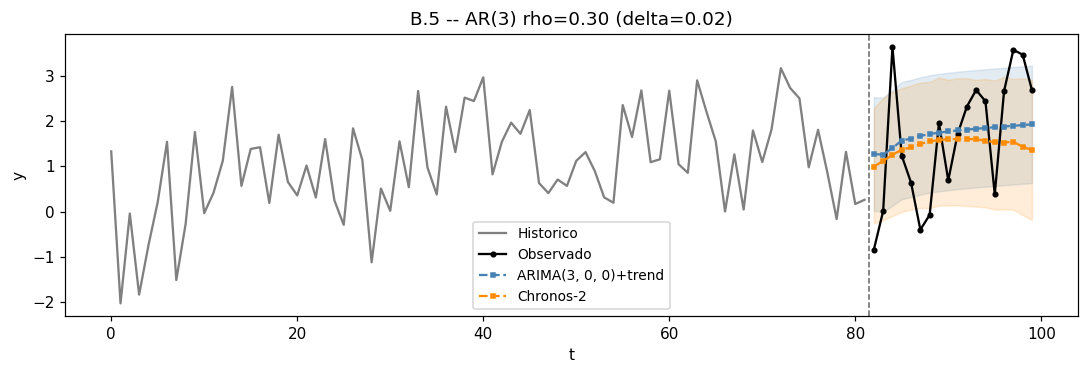

In [31]:
try:
    # B.5 -- AR(3) rho=0.30  [tendencia leve delta=0.02]
    cl  = ARIMAWithTrendModel((3, 0, 0), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.3, 0.1, 0.05], thetas=[], delta=0.02, sigma=1.0, seed=SEED)
    verify_dgp("B.5 -- AR(3) rho=0.30 (delta=0.02)", dgp, {}, cl, CHECKS_AR_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.5")
    log("\n" + "="*60 + "\nB.5 -- AR(3) rho=0.30 (delta=0.02)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(3, 0, 0)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.5 -- AR(3) rho=0.30 (delta=0.02)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.5 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:07:05  ────────────────────────────────────────────────────────────
19:07:05  VERIFICACION DGP: B.6 -- AR(3) rho=0.90 (delta=0.02)
19:07:05  ────────────────────────────────────────────────────────────
19:07:05    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:07:07    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [16.3389 16.1933 16.1444]
19:07:07    -> TODAS LAS VERIFICACIONES PASARON
19:07:07  Exp B.6: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:07:07    T=50 H=6, R=500: cargando exp_B_6_T50_R500.csv
19:07:07    T=100 H=18, R=500: cargando exp_B_6_T100_R500.csv
19:07:07    T=200 H=24, R=500: cargando exp_B_6_T200_R500.csv
19:07:08  
B.6 -- AR(3) rho=0.90 (delta=0.02)


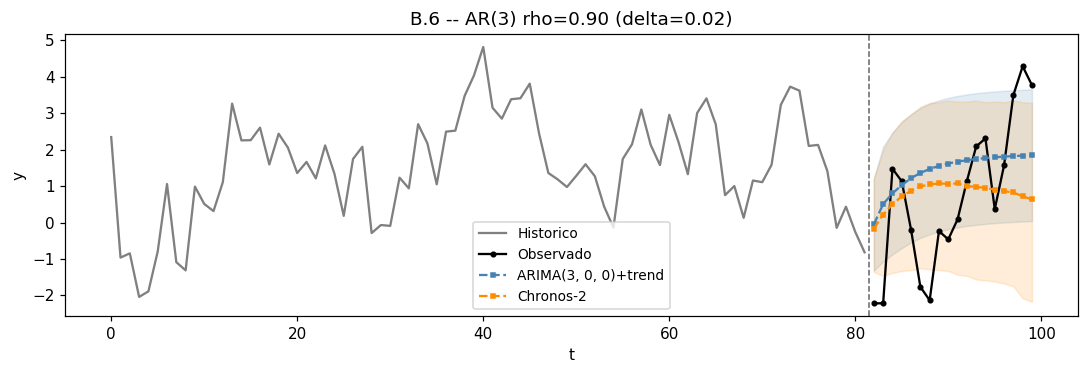

In [32]:
try:
    # B.6 -- AR(3) rho=0.90  [tendencia leve delta=0.02]
    cl  = ARIMAWithTrendModel((3, 0, 0), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.9, -0.2, 0.1], thetas=[], delta=0.02, sigma=1.0, seed=SEED)
    verify_dgp("B.6 -- AR(3) rho=0.90 (delta=0.02)", dgp, {}, cl, CHECKS_AR_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.6")
    log("\n" + "="*60 + "\nB.6 -- AR(3) rho=0.90 (delta=0.02)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(3, 0, 0)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.6 -- AR(3) rho=0.90 (delta=0.02)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.6 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:07:09  ────────────────────────────────────────────────────────────
19:07:09  VERIFICACION DGP: B.7 -- AR(4) rho=0.30 (delta=0.02)
19:07:09  ────────────────────────────────────────────────────────────
19:07:09    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:07:10    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [16.0651 16.026  16.0417]
19:07:10    -> TODAS LAS VERIFICACIONES PASARON
19:07:10  Exp B.7: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:07:10    T=50 H=6, R=500: cargando exp_B_7_T50_R500.csv
19:07:10    T=100 H=18, R=500: cargando exp_B_7_T100_R500.csv
19:07:10    T=200 H=24, R=500: cargando exp_B_7_T200_R500.csv
19:07:10  
B.7 -- AR(4) rho=0.30 (delta=0.02)


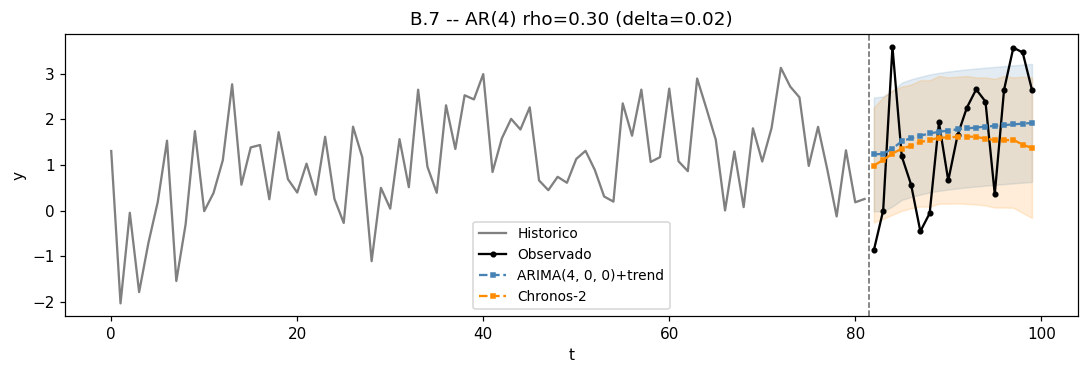

In [33]:
try:
    # B.7 -- AR(4) rho=0.30  [tendencia leve delta=0.02]
    cl  = ARIMAWithTrendModel((4, 0, 0), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.3, 0.1, 0.05, 0.02], thetas=[], delta=0.02, sigma=1.0, seed=SEED)
    verify_dgp("B.7 -- AR(4) rho=0.30 (delta=0.02)", dgp, {}, cl, CHECKS_AR_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.7")
    log("\n" + "="*60 + "\nB.7 -- AR(4) rho=0.30 (delta=0.02)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(4, 0, 0)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.7 -- AR(4) rho=0.30 (delta=0.02)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.7 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:07:12  ────────────────────────────────────────────────────────────
19:07:12  VERIFICACION DGP: B.8 -- AR(4) rho=0.90 (delta=0.02)
19:07:12  ────────────────────────────────────────────────────────────
19:07:12    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:07:13    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [16.1925 16.1073 16.0696]
19:07:13    -> TODAS LAS VERIFICACIONES PASARON
19:07:13  Exp B.8: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:07:13    T=50 H=6, R=500: cargando exp_B_8_T50_R500.csv
19:07:13    T=100 H=18, R=500: cargando exp_B_8_T100_R500.csv
19:07:13    T=200 H=24, R=500: cargando exp_B_8_T200_R500.csv
19:07:13  
B.8 -- AR(4) rho=0.90 (delta=0.02)


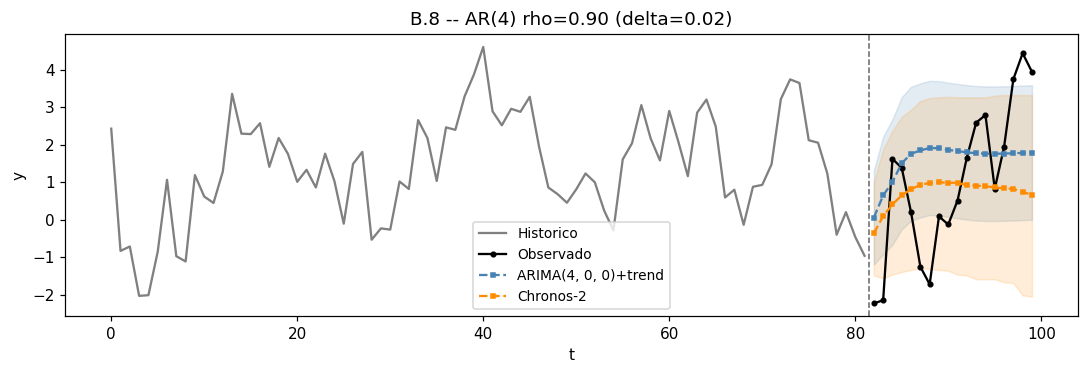

In [34]:
try:
    # B.8 -- AR(4) rho=0.90  [tendencia leve delta=0.02]
    cl  = ARIMAWithTrendModel((4, 0, 0), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.9, -0.2, 0.1, -0.05], thetas=[], delta=0.02, sigma=1.0, seed=SEED)
    verify_dgp("B.8 -- AR(4) rho=0.90 (delta=0.02)", dgp, {}, cl, CHECKS_AR_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.8")
    log("\n" + "="*60 + "\nB.8 -- AR(4) rho=0.90 (delta=0.02)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(4, 0, 0)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.8 -- AR(4) rho=0.90 (delta=0.02)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.8 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:07:15  ────────────────────────────────────────────────────────────
19:07:15  VERIFICACION DGP: B.9 -- MA(1) theta=0.30 (delta=0.02)
19:07:15  ────────────────────────────────────────────────────────────
19:07:15    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:07:15    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [16.0128 15.9671 15.987 ]
19:07:15    -> TODAS LAS VERIFICACIONES PASARON
19:07:15  Exp B.9: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:07:15    T=50 H=6, R=500: cargando exp_B_9_T50_R500.csv
19:07:15    T=100 H=18, R=500: cargando exp_B_9_T100_R500.csv
19:07:15    T=200 H=24, R=500: cargando exp_B_9_T200_R500.csv
19:07:15  
B.9 -- MA(1) theta=0.30 (delta=0.02)


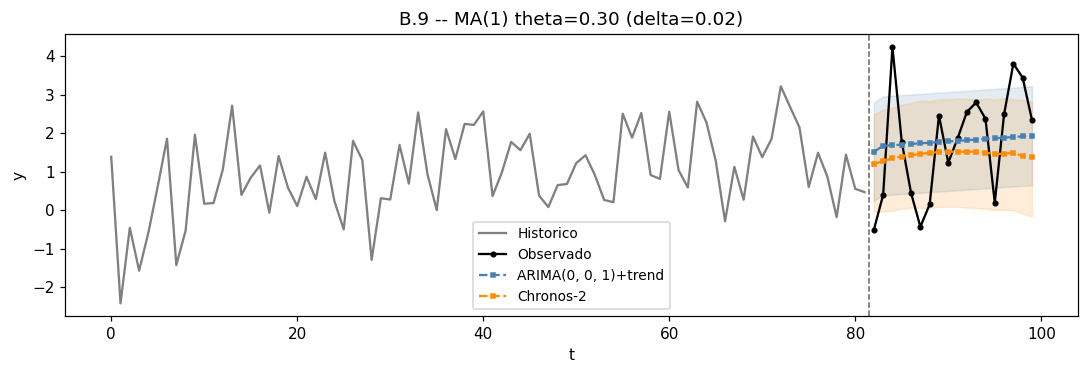

In [35]:
try:
    # B.9 -- MA(1) theta=0.30  [tendencia leve delta=0.02]
    cl  = ARIMAWithTrendModel((0, 0, 1), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[], thetas=[0.3], delta=0.02, sigma=1.0, seed=SEED)
    verify_dgp("B.9 -- MA(1) theta=0.30 (delta=0.02)", dgp, {}, cl, CHECKS_MA_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.9")
    log("\n" + "="*60 + "\nB.9 -- MA(1) theta=0.30 (delta=0.02)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(0, 0, 1)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.9 -- MA(1) theta=0.30 (delta=0.02)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.9 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:07:17  ────────────────────────────────────────────────────────────
19:07:17  VERIFICACION DGP: B.10 -- MA(1) theta=0.90 (delta=0.02)
19:07:17  ────────────────────────────────────────────────────────────
19:07:17    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:07:17    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [16.3859 15.9328 15.9527]
19:07:17    -> TODAS LAS VERIFICACIONES PASARON
19:07:17  Exp B.10: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:07:17    T=50 H=6, R=500: cargando exp_B_10_T50_R500.csv
19:07:17    T=100 H=18, R=500: cargando exp_B_10_T100_R500.csv
19:07:17    T=200 H=24, R=500: cargando exp_B_10_T200_R500.csv
19:07:17  
B.10 -- MA(1) theta=0.90 (delta=0.02)


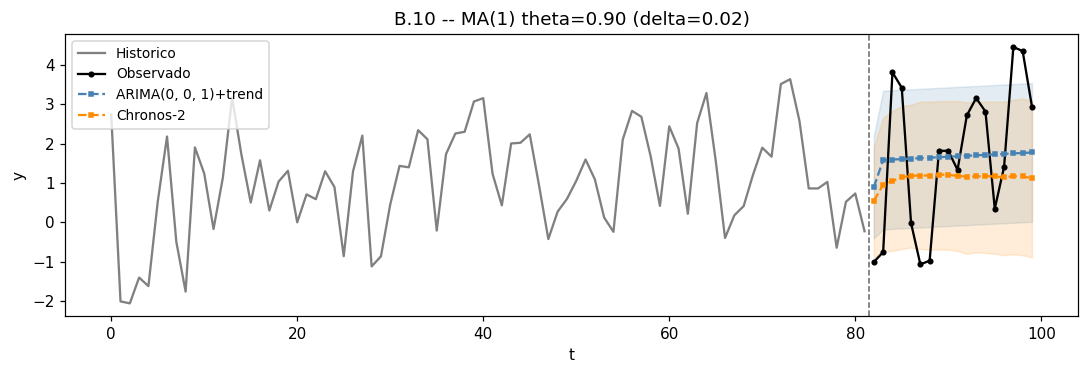

In [36]:
try:
    # B.10 -- MA(1) theta=0.90  [tendencia leve delta=0.02]
    cl  = ARIMAWithTrendModel((0, 0, 1), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[], thetas=[0.9], delta=0.02, sigma=1.0, seed=SEED)
    verify_dgp("B.10 -- MA(1) theta=0.90 (delta=0.02)", dgp, {}, cl, CHECKS_MA_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.10")
    log("\n" + "="*60 + "\nB.10 -- MA(1) theta=0.90 (delta=0.02)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(0, 0, 1)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.10 -- MA(1) theta=0.90 (delta=0.02)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.10 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:07:19  ────────────────────────────────────────────────────────────
19:07:19  VERIFICACION DGP: B.11 -- MA(2) theta=0.30 (delta=0.02)
19:07:19  ────────────────────────────────────────────────────────────
19:07:19    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:07:19    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [16.1214 15.9844 15.9813]
19:07:19    -> TODAS LAS VERIFICACIONES PASARON
19:07:19  Exp B.11: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:07:19    T=50 H=6, R=500: cargando exp_B_11_T50_R500.csv
19:07:19    T=100 H=18, R=500: cargando exp_B_11_T100_R500.csv
19:07:19    T=200 H=24, R=500: cargando exp_B_11_T200_R500.csv
19:07:19  
B.11 -- MA(2) theta=0.30 (delta=0.02)


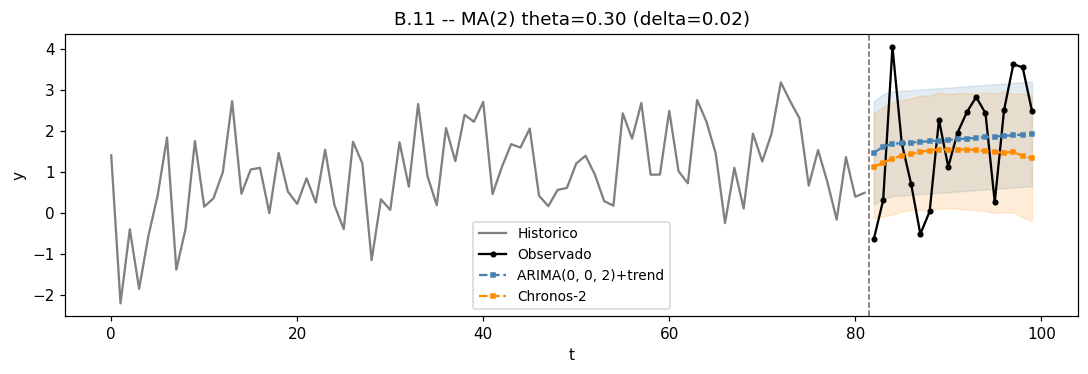

In [37]:
try:
    # B.11 -- MA(2) theta=0.30  [tendencia leve delta=0.02]
    cl  = ARIMAWithTrendModel((0, 0, 2), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[], thetas=[0.3, 0.1], delta=0.02, sigma=1.0, seed=SEED)
    verify_dgp("B.11 -- MA(2) theta=0.30 (delta=0.02)", dgp, {}, cl, CHECKS_MA_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.11")
    log("\n" + "="*60 + "\nB.11 -- MA(2) theta=0.30 (delta=0.02)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(0, 0, 2)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.11 -- MA(2) theta=0.30 (delta=0.02)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.11 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:07:21  ────────────────────────────────────────────────────────────
19:07:21  VERIFICACION DGP: B.12 -- MA(2) theta=0.90 (delta=0.02)
19:07:21  ────────────────────────────────────────────────────────────
19:07:21    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:07:21    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [16.2039 15.9443 15.947 ]
19:07:21    -> TODAS LAS VERIFICACIONES PASARON
19:07:21  Exp B.12: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:07:21    T=50 H=6, R=500: cargando exp_B_12_T50_R500.csv
19:07:21    T=100 H=18, R=500: cargando exp_B_12_T100_R500.csv
19:07:21    T=200 H=24, R=500: cargando exp_B_12_T200_R500.csv
19:07:21  
B.12 -- MA(2) theta=0.90 (delta=0.02)


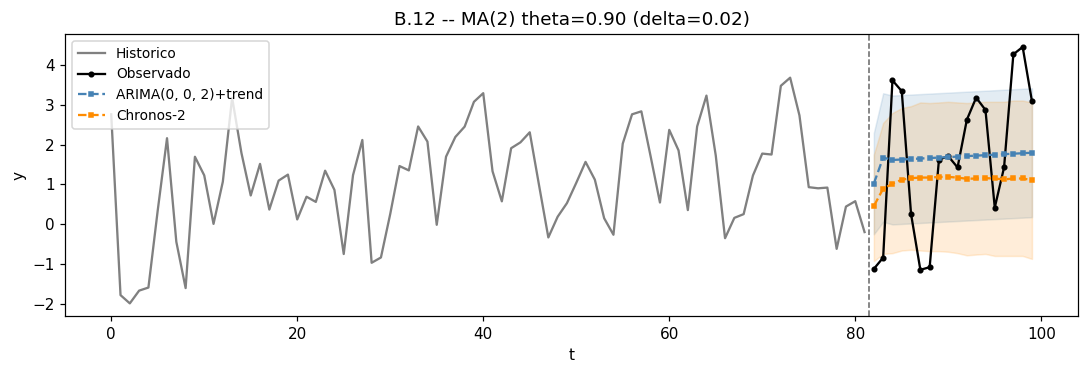

In [38]:
try:
    # B.12 -- MA(2) theta=0.90  [tendencia leve delta=0.02]
    cl  = ARIMAWithTrendModel((0, 0, 2), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[], thetas=[0.9, 0.1], delta=0.02, sigma=1.0, seed=SEED)
    verify_dgp("B.12 -- MA(2) theta=0.90 (delta=0.02)", dgp, {}, cl, CHECKS_MA_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.12")
    log("\n" + "="*60 + "\nB.12 -- MA(2) theta=0.90 (delta=0.02)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(0, 0, 2)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.12 -- MA(2) theta=0.90 (delta=0.02)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.12 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:07:22  ────────────────────────────────────────────────────────────
19:07:22  VERIFICACION DGP: B.13 -- MA(3) theta=0.30 (delta=0.02)
19:07:22  ────────────────────────────────────────────────────────────
19:07:22    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:07:23    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [16.1767 15.9229 15.9708]
19:07:23    -> TODAS LAS VERIFICACIONES PASARON
19:07:23  Exp B.13: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:07:23    T=50 H=6, R=500: cargando exp_B_13_T50_R500.csv
19:07:23    T=100 H=18, R=500: cargando exp_B_13_T100_R500.csv
19:07:23    T=200 H=24, R=500: cargando exp_B_13_T200_R500.csv
19:07:23  
B.13 -- MA(3) theta=0.30 (delta=0.02)


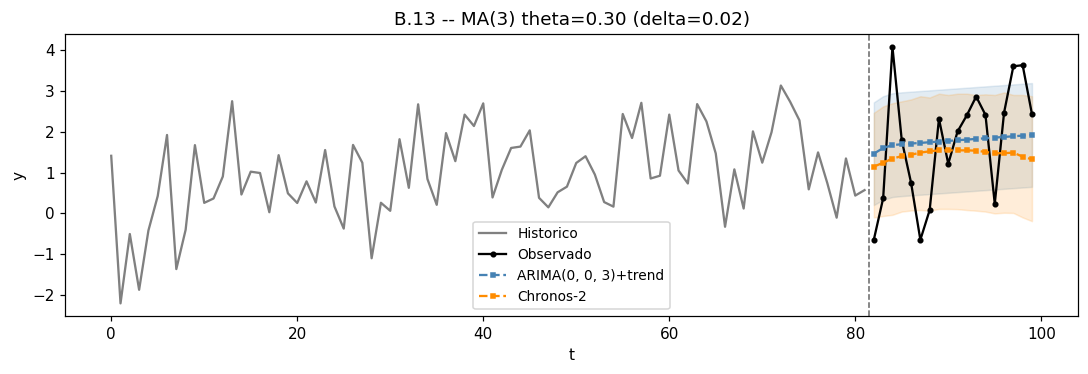

In [39]:
try:
    # B.13 -- MA(3) theta=0.30  [tendencia leve delta=0.02]
    cl  = ARIMAWithTrendModel((0, 0, 3), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[], thetas=[0.3, 0.1, -0.05], delta=0.02, sigma=1.0, seed=SEED)
    verify_dgp("B.13 -- MA(3) theta=0.30 (delta=0.02)", dgp, {}, cl, CHECKS_MA_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.13")
    log("\n" + "="*60 + "\nB.13 -- MA(3) theta=0.30 (delta=0.02)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(0, 0, 3)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.13 -- MA(3) theta=0.30 (delta=0.02)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.13 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:07:25  ────────────────────────────────────────────────────────────
19:07:25  VERIFICACION DGP: B.14 -- MA(3) theta=0.90 (delta=0.02)
19:07:25  ────────────────────────────────────────────────────────────
19:07:25    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:07:25    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [16.2502 15.8964 15.9392]
19:07:25    -> TODAS LAS VERIFICACIONES PASARON
19:07:25  Exp B.14: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:07:25    T=50 H=6, R=500: cargando exp_B_14_T50_R500.csv
19:07:25    T=100 H=18, R=500: cargando exp_B_14_T100_R500.csv
19:07:25    T=200 H=24, R=500: cargando exp_B_14_T200_R500.csv
19:07:25  
B.14 -- MA(3) theta=0.90 (delta=0.02)


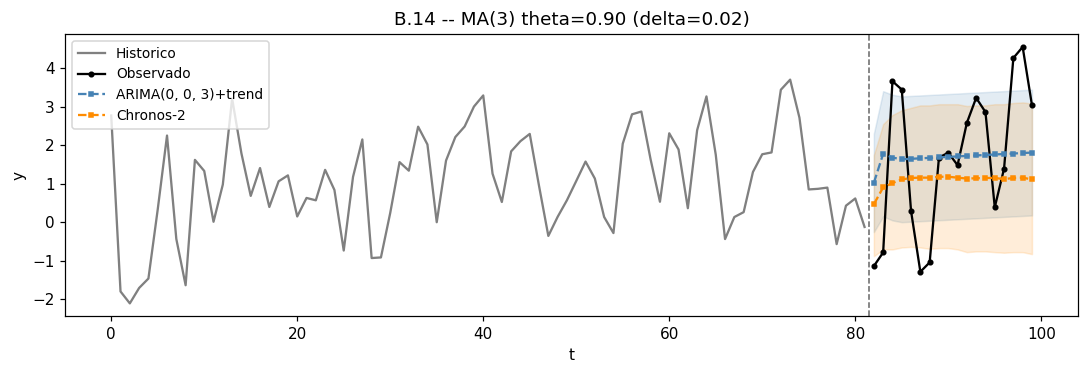

In [40]:
try:
    # B.14 -- MA(3) theta=0.90  [tendencia leve delta=0.02]
    cl  = ARIMAWithTrendModel((0, 0, 3), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[], thetas=[0.9, 0.1, -0.05], delta=0.02, sigma=1.0, seed=SEED)
    verify_dgp("B.14 -- MA(3) theta=0.90 (delta=0.02)", dgp, {}, cl, CHECKS_MA_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.14")
    log("\n" + "="*60 + "\nB.14 -- MA(3) theta=0.90 (delta=0.02)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(0, 0, 3)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.14 -- MA(3) theta=0.90 (delta=0.02)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.14 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:07:27  ────────────────────────────────────────────────────────────
19:07:27  VERIFICACION DGP: B.15 -- MA(4) theta=0.30 (delta=0.02)
19:07:27  ────────────────────────────────────────────────────────────
19:07:27    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:07:28    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [16.1901 15.8977 15.9975]
19:07:28    -> TODAS LAS VERIFICACIONES PASARON
19:07:28  Exp B.15: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:07:28    T=50 H=6, R=500: cargando exp_B_15_T50_R500.csv
19:07:28    T=100 H=18, R=500: cargando exp_B_15_T100_R500.csv
19:07:28    T=200 H=24, R=500: cargando exp_B_15_T200_R500.csv
19:07:28  
B.15 -- MA(4) theta=0.30 (delta=0.02)


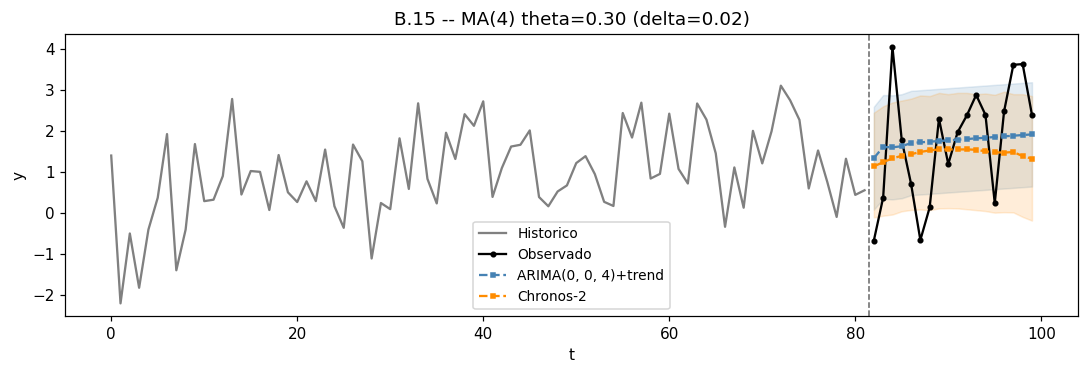

In [41]:
try:
    # B.15 -- MA(4) theta=0.30  [tendencia leve delta=0.02]
    cl  = ARIMAWithTrendModel((0, 0, 4), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[], thetas=[0.3, 0.1, -0.05, 0.02], delta=0.02, sigma=1.0, seed=SEED)
    verify_dgp("B.15 -- MA(4) theta=0.30 (delta=0.02)", dgp, {}, cl, CHECKS_MA_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.15")
    log("\n" + "="*60 + "\nB.15 -- MA(4) theta=0.30 (delta=0.02)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(0, 0, 4)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.15 -- MA(4) theta=0.30 (delta=0.02)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.15 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:07:30  ────────────────────────────────────────────────────────────
19:07:30  VERIFICACION DGP: B.16 -- MA(4) theta=0.90 (delta=0.02)
19:07:30  ────────────────────────────────────────────────────────────
19:07:30    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:07:31    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [16.2808 15.8638 15.9617]
19:07:31    -> TODAS LAS VERIFICACIONES PASARON
19:07:31  Exp B.16: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:07:31    T=50 H=6, R=500: cargando exp_B_16_T50_R500.csv
19:07:31    T=100 H=18, R=500: cargando exp_B_16_T100_R500.csv
19:07:31    T=200 H=24, R=500: cargando exp_B_16_T200_R500.csv
19:07:31  
B.16 -- MA(4) theta=0.90 (delta=0.02)


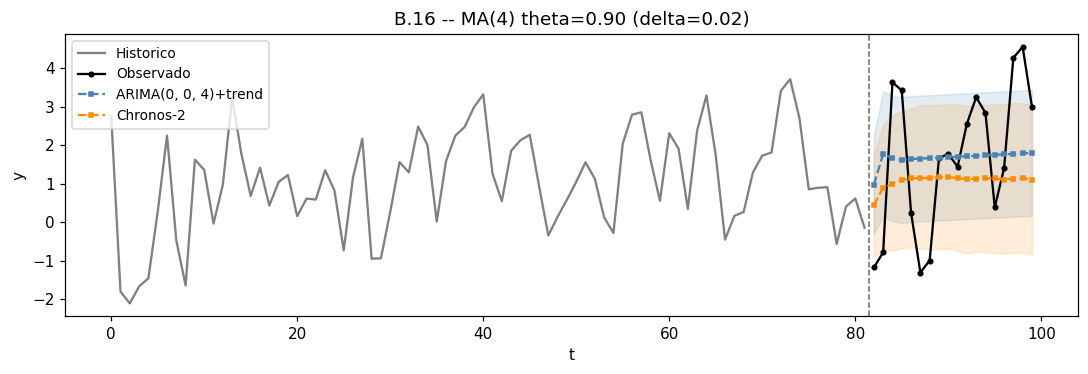

In [42]:
try:
    # B.16 -- MA(4) theta=0.90  [tendencia leve delta=0.02]
    cl  = ARIMAWithTrendModel((0, 0, 4), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[], thetas=[0.9, 0.1, -0.05, 0.02], delta=0.02, sigma=1.0, seed=SEED)
    verify_dgp("B.16 -- MA(4) theta=0.90 (delta=0.02)", dgp, {}, cl, CHECKS_MA_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.16")
    log("\n" + "="*60 + "\nB.16 -- MA(4) theta=0.90 (delta=0.02)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(0, 0, 4)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.16 -- MA(4) theta=0.90 (delta=0.02)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.16 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:07:33  ────────────────────────────────────────────────────────────
19:07:33  VERIFICACION DGP: B.17 -- ARMA(1,1) rho=0.30 (delta=0.02)
19:07:33  ────────────────────────────────────────────────────────────
19:07:33    [FAIL] Estacionariedad (ADF): ADF p=0.9205 (umbral 0.05)
19:07:33    [FAIL] AIC ARMA < baseline: ARIMA.fit() got an unexpected keyword argument 'disp'
19:07:34    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [16.1218 16.0096 15.9892]
19:07:34    -> 2 FALLO(S)
19:07:34  Exp B.17: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:07:34    T=50 H=6, R=500: cargando exp_B_17_T50_R500.csv
19:07:34    T=100 H=18, R=500: cargando exp_B_17_T100_R500.csv
19:07:34    T=200 H=24, R=500: cargando exp_B_17_T200_R500.csv
19:07:34  
B.17 -- ARMA(1,1) rho=0.30 (delta=0.02)


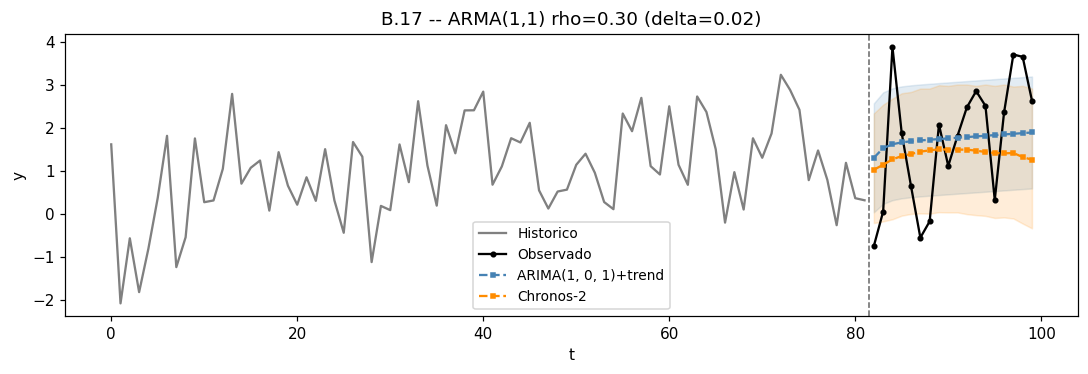

In [43]:
try:
    # B.17 -- ARMA(1,1) rho=0.30  [tendencia leve delta=0.02]
    cl  = ARIMAWithTrendModel((1, 0, 1), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.3], thetas=[0.1], delta=0.02, sigma=1.0, seed=SEED)
    verify_dgp("B.17 -- ARMA(1,1) rho=0.30 (delta=0.02)", dgp, {}, cl, CHECKS_ARMA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.17")
    log("\n" + "="*60 + "\nB.17 -- ARMA(1,1) rho=0.30 (delta=0.02)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(1, 0, 1)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.17 -- ARMA(1,1) rho=0.30 (delta=0.02)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.17 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:07:36  ────────────────────────────────────────────────────────────
19:07:36  VERIFICACION DGP: B.18 -- ARMA(1,1) rho=0.90 (delta=0.02)
19:07:36  ────────────────────────────────────────────────────────────
19:07:36    [PASS] Estacionariedad (ADF): ADF p=0.0479 (umbral 0.05)
19:07:36    [FAIL] AIC ARMA < baseline: ARIMA.fit() got an unexpected keyword argument 'disp'
19:07:36    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [17.7857 17.5668 17.3705]
19:07:36    -> 1 FALLO(S)
19:07:36  Exp B.18: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:07:36    T=50 H=6, R=500: cargando exp_B_18_T50_R500.csv
19:07:36    T=100 H=18, R=500: cargando exp_B_18_T100_R500.csv
19:07:36    T=200 H=24, R=500: cargando exp_B_18_T200_R500.csv
19:07:36  
B.18 -- ARMA(1,1) rho=0.90 (delta=0.02)


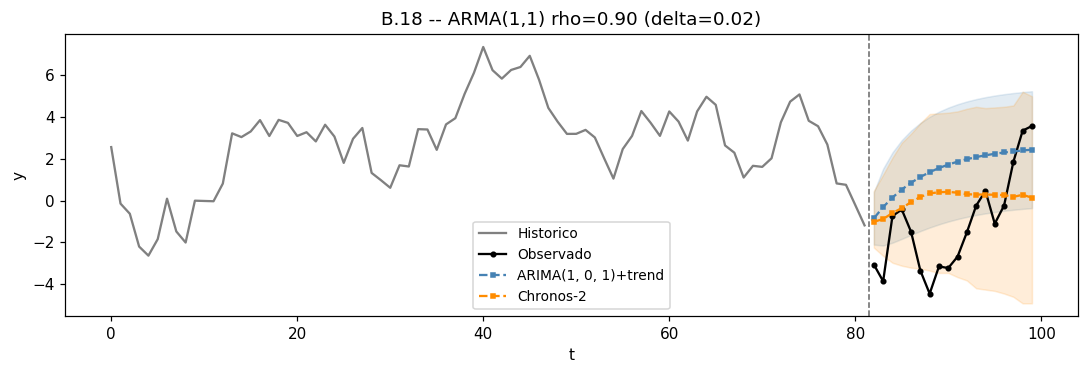

In [44]:
try:
    # B.18 -- ARMA(1,1) rho=0.90  [tendencia leve delta=0.02]
    cl  = ARIMAWithTrendModel((1, 0, 1), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.9], thetas=[0.3], delta=0.02, sigma=1.0, seed=SEED)
    verify_dgp("B.18 -- ARMA(1,1) rho=0.90 (delta=0.02)", dgp, {}, cl, CHECKS_ARMA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.18")
    log("\n" + "="*60 + "\nB.18 -- ARMA(1,1) rho=0.90 (delta=0.02)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(1, 0, 1)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.18 -- ARMA(1,1) rho=0.90 (delta=0.02)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.18 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:07:37  ────────────────────────────────────────────────────────────
19:07:37  VERIFICACION DGP: B.19 -- ARMA(2,2) rho=0.30 (delta=0.02)
19:07:37  ────────────────────────────────────────────────────────────
19:07:37    [FAIL] Estacionariedad (ADF): ADF p=0.9096 (umbral 0.05)
19:07:37    [FAIL] AIC ARMA < baseline: ARIMA.fit() got an unexpected keyword argument 'disp'
19:07:38    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [16.2101 16.0569 16.0331]
19:07:39    -> 2 FALLO(S)
19:07:39  Exp B.19: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:07:39    T=50 H=6, R=500: cargando exp_B_19_T50_R500.csv
19:07:39    T=100 H=18, R=500: cargando exp_B_19_T100_R500.csv
19:07:39    T=200 H=24, R=500: cargando exp_B_19_T200_R500.csv
19:07:39  
B.19 -- ARMA(2,2) rho=0.30 (delta=0.02)


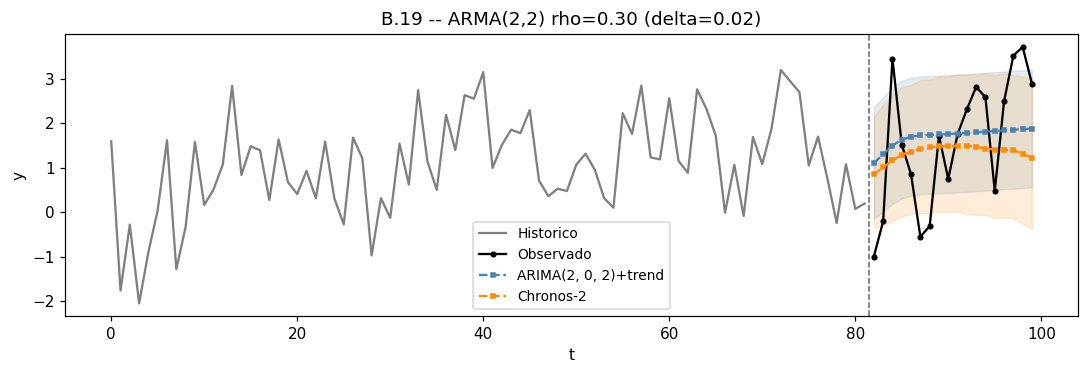

In [45]:
try:
    # B.19 -- ARMA(2,2) rho=0.30  [tendencia leve delta=0.02]
    cl  = ARIMAWithTrendModel((2, 0, 2), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.3, 0.1], thetas=[0.1, 0.05], delta=0.02, sigma=1.0, seed=SEED)
    verify_dgp("B.19 -- ARMA(2,2) rho=0.30 (delta=0.02)", dgp, {}, cl, CHECKS_ARMA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.19")
    log("\n" + "="*60 + "\nB.19 -- ARMA(2,2) rho=0.30 (delta=0.02)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(2, 0, 2)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.19 -- ARMA(2,2) rho=0.30 (delta=0.02)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.19 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:07:40  ────────────────────────────────────────────────────────────
19:07:40  VERIFICACION DGP: B.20 -- ARMA(2,2) rho=0.90 (delta=0.02)
19:07:40  ────────────────────────────────────────────────────────────
19:07:41    [FAIL] Estacionariedad (ADF): ADF p=0.7533 (umbral 0.05)
19:07:41    [FAIL] AIC ARMA < baseline: ARIMA.fit() got an unexpected keyword argument 'disp'
19:07:42    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [16.4954 16.2639 16.1072]
19:07:42    -> 2 FALLO(S)
19:07:42  Exp B.20: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:07:42    T=50 H=6, R=500: cargando exp_B_20_T50_R500.csv
19:07:42    T=100 H=18, R=500: cargando exp_B_20_T100_R500.csv
19:07:42    T=200 H=24, R=500: cargando exp_B_20_T200_R500.csv
19:07:42  
B.20 -- ARMA(2,2) rho=0.90 (delta=0.02)


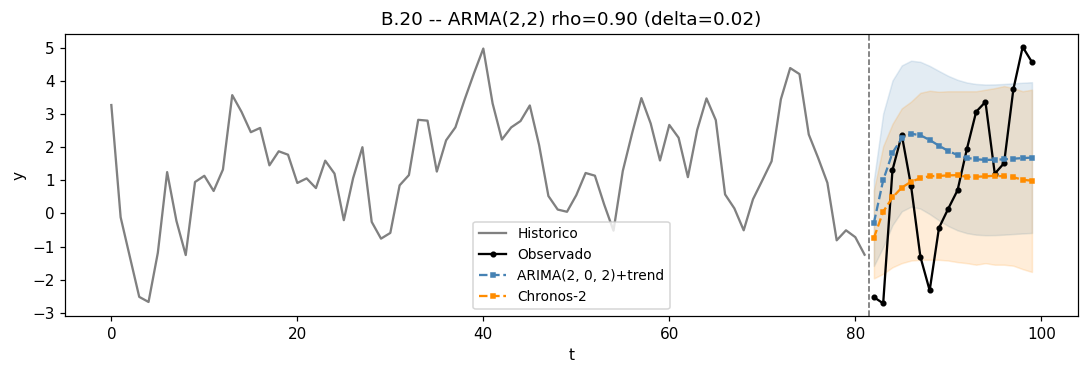

In [46]:
try:
    # B.20 -- ARMA(2,2) rho=0.90  [tendencia leve delta=0.02]
    cl  = ARIMAWithTrendModel((2, 0, 2), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.9, -0.2], thetas=[0.3, -0.1], delta=0.02, sigma=1.0, seed=SEED)
    verify_dgp("B.20 -- ARMA(2,2) rho=0.90 (delta=0.02)", dgp, {}, cl, CHECKS_ARMA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.20")
    log("\n" + "="*60 + "\nB.20 -- ARMA(2,2) rho=0.90 (delta=0.02)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(2, 0, 2)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.20 -- ARMA(2,2) rho=0.90 (delta=0.02)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.20 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:07:45  ────────────────────────────────────────────────────────────
19:07:45  VERIFICACION DGP: B.21 -- ARMA(1,4) rho=0.30 (delta=0.02)
19:07:45  ────────────────────────────────────────────────────────────
19:07:45    [FAIL] Estacionariedad (ADF): ADF p=0.9191 (umbral 0.05)
19:07:45    [FAIL] AIC ARMA < baseline: ARIMA.fit() got an unexpected keyword argument 'disp'
19:07:46    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [16.1958 15.9855 15.984 ]
19:07:46    -> 2 FALLO(S)
19:07:46  Exp B.21: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:07:46    T=50 H=6, R=500: cargando exp_B_21_T50_R500.csv
19:07:46    T=100 H=18, R=500: cargando exp_B_21_T100_R500.csv
19:07:46    T=200 H=24, R=500: cargando exp_B_21_T200_R500.csv
19:07:46  
B.21 -- ARMA(1,4) rho=0.30 (delta=0.02)


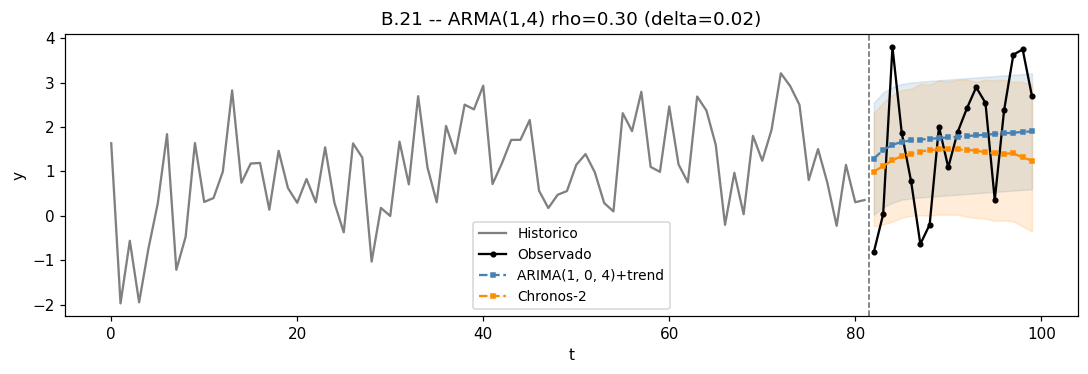

In [47]:
try:
    # B.21 -- ARMA(1,4) rho=0.30  [tendencia leve delta=0.02]
    cl  = ARIMAWithTrendModel((1, 0, 4), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.3], thetas=[0.1, 0.05, -0.03, 0.01], delta=0.02, sigma=1.0, seed=SEED)
    verify_dgp("B.21 -- ARMA(1,4) rho=0.30 (delta=0.02)", dgp, {}, cl, CHECKS_ARMA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.21")
    log("\n" + "="*60 + "\nB.21 -- ARMA(1,4) rho=0.30 (delta=0.02)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(1, 0, 4)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.21 -- ARMA(1,4) rho=0.30 (delta=0.02)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.21 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:07:48  ────────────────────────────────────────────────────────────
19:07:48  VERIFICACION DGP: B.22 -- ARMA(1,4) rho=0.90 (delta=0.02)
19:07:48  ────────────────────────────────────────────────────────────
19:07:48    [FAIL] Estacionariedad (ADF): ADF p=0.1325 (umbral 0.05)
19:07:48    [FAIL] AIC ARMA < baseline: ARIMA.fit() got an unexpected keyword argument 'disp'
19:07:50    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [17.6374 17.4868 17.2983]
19:07:50    -> 2 FALLO(S)
19:07:50  Exp B.22: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:07:50    T=50 H=6, R=500: cargando exp_B_22_T50_R500.csv
19:07:50    T=100 H=18, R=500: cargando exp_B_22_T100_R500.csv
19:07:50    T=200 H=24, R=500: cargando exp_B_22_T200_R500.csv
19:07:50  
B.22 -- ARMA(1,4) rho=0.90 (delta=0.02)


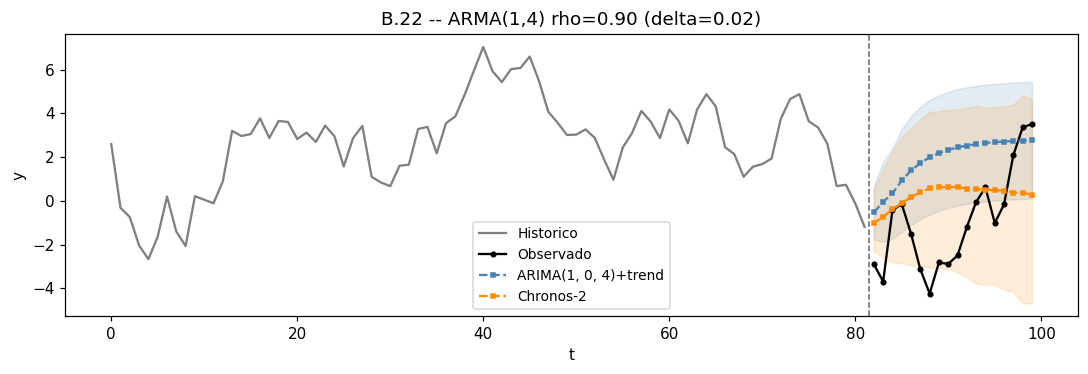

In [48]:
try:
    # B.22 -- ARMA(1,4) rho=0.90  [tendencia leve delta=0.02]
    cl  = ARIMAWithTrendModel((1, 0, 4), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.9], thetas=[0.3, -0.1, 0.05, -0.02], delta=0.02, sigma=1.0, seed=SEED)
    verify_dgp("B.22 -- ARMA(1,4) rho=0.90 (delta=0.02)", dgp, {}, cl, CHECKS_ARMA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.22")
    log("\n" + "="*60 + "\nB.22 -- ARMA(1,4) rho=0.90 (delta=0.02)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(1, 0, 4)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.22 -- ARMA(1,4) rho=0.90 (delta=0.02)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.22 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:07:52  ────────────────────────────────────────────────────────────
19:07:52  VERIFICACION DGP: B.23 -- ARMA(4,1) rho=0.30 (delta=0.02)
19:07:52  ────────────────────────────────────────────────────────────
19:07:52    [FAIL] Estacionariedad (ADF): ADF p=0.9061 (umbral 0.05)
19:07:52    [FAIL] AIC ARMA < baseline: ARIMA.fit() got an unexpected keyword argument 'disp'
19:07:53    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [16.0854 16.0384 16.0394]
19:07:53    -> 2 FALLO(S)
19:07:53  Exp B.23: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:07:53    T=50 H=6, R=500: cargando exp_B_23_T50_R500.csv
19:07:53    T=100 H=18, R=500: cargando exp_B_23_T100_R500.csv
19:07:53    T=200 H=24, R=500: cargando exp_B_23_T200_R500.csv
19:07:53  
B.23 -- ARMA(4,1) rho=0.30 (delta=0.02)


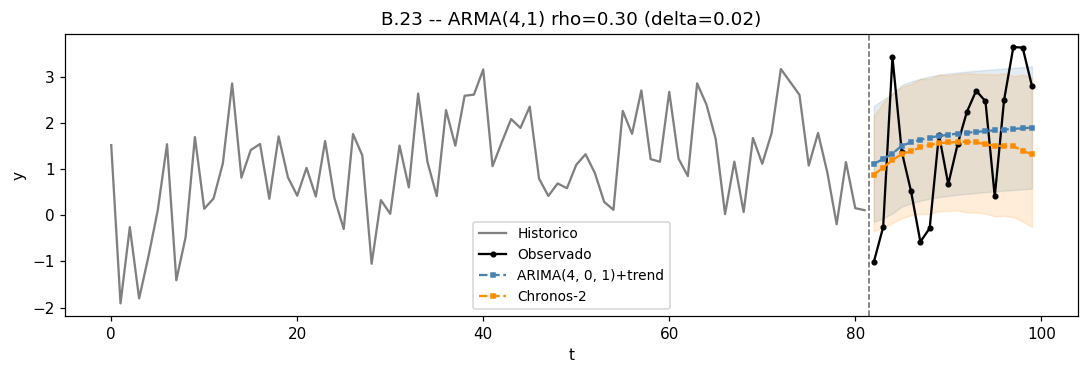

In [49]:
try:
    # B.23 -- ARMA(4,1) rho=0.30  [tendencia leve delta=0.02]
    cl  = ARIMAWithTrendModel((4, 0, 1), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.3, 0.1, 0.05, 0.02], thetas=[0.1], delta=0.02, sigma=1.0, seed=SEED)
    verify_dgp("B.23 -- ARMA(4,1) rho=0.30 (delta=0.02)", dgp, {}, cl, CHECKS_ARMA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.23")
    log("\n" + "="*60 + "\nB.23 -- ARMA(4,1) rho=0.30 (delta=0.02)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(4, 0, 1)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.23 -- ARMA(4,1) rho=0.30 (delta=0.02)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.23 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:07:54  ────────────────────────────────────────────────────────────
19:07:54  VERIFICACION DGP: B.24 -- ARMA(4,1) rho=0.90 (delta=0.02)
19:07:54  ────────────────────────────────────────────────────────────
19:07:54    [FAIL] Estacionariedad (ADF): ADF p=0.6677 (umbral 0.05)
19:07:54    [FAIL] AIC ARMA < baseline: ARIMA.fit() got an unexpected keyword argument 'disp'
19:07:55    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [16.2709 16.1447 16.051 ]
19:07:55    -> 2 FALLO(S)
19:07:55  Exp B.24: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:07:55    T=50 H=6, R=500: cargando exp_B_24_T50_R500.csv
19:07:55    T=100 H=18, R=500: cargando exp_B_24_T100_R500.csv
19:07:55    T=200 H=24, R=500: cargando exp_B_24_T200_R500.csv
19:07:55  
B.24 -- ARMA(4,1) rho=0.90 (delta=0.02)


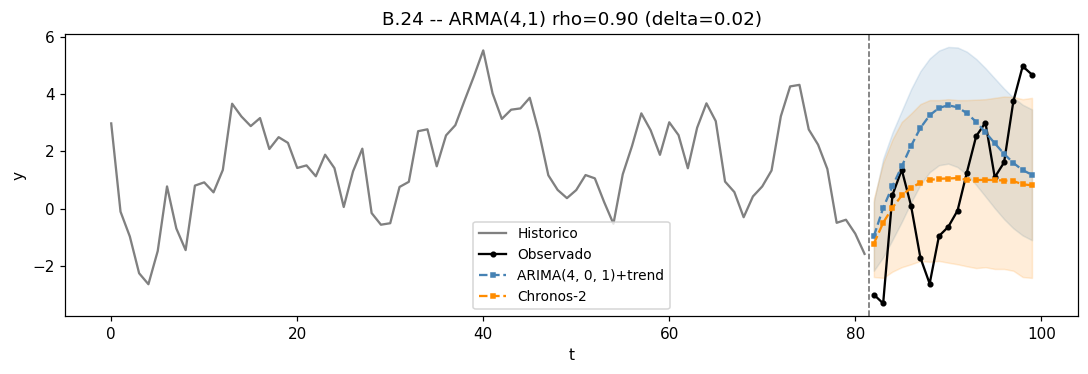

In [50]:
try:
    # B.24 -- ARMA(4,1) rho=0.90  [tendencia leve delta=0.02]
    cl  = ARIMAWithTrendModel((4, 0, 1), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.9, -0.2, 0.1, -0.05], thetas=[0.3], delta=0.02, sigma=1.0, seed=SEED)
    verify_dgp("B.24 -- ARMA(4,1) rho=0.90 (delta=0.02)", dgp, {}, cl, CHECKS_ARMA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.24")
    log("\n" + "="*60 + "\nB.24 -- ARMA(4,1) rho=0.90 (delta=0.02)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(4, 0, 1)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.24 -- ARMA(4,1) rho=0.90 (delta=0.02)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.24 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:07:57  ────────────────────────────────────────────────────────────
19:07:57  VERIFICACION DGP: B.25 -- AR(1) rho=0.30 (delta=0.1)
19:07:57  ────────────────────────────────────────────────────────────
19:07:57    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:07:57    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [80.1534 80.1572 80.2302]
19:07:57    -> TODAS LAS VERIFICACIONES PASARON
19:07:57  Exp B.25: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:07:57    T=50 H=6, R=500: cargando exp_B_25_T50_R500.csv
19:07:57    T=100 H=18, R=500: cargando exp_B_25_T100_R500.csv
19:07:57    T=200 H=24, R=500: cargando exp_B_25_T200_R500.csv
19:07:57  
B.25 -- AR(1) rho=0.30 (delta=0.1)


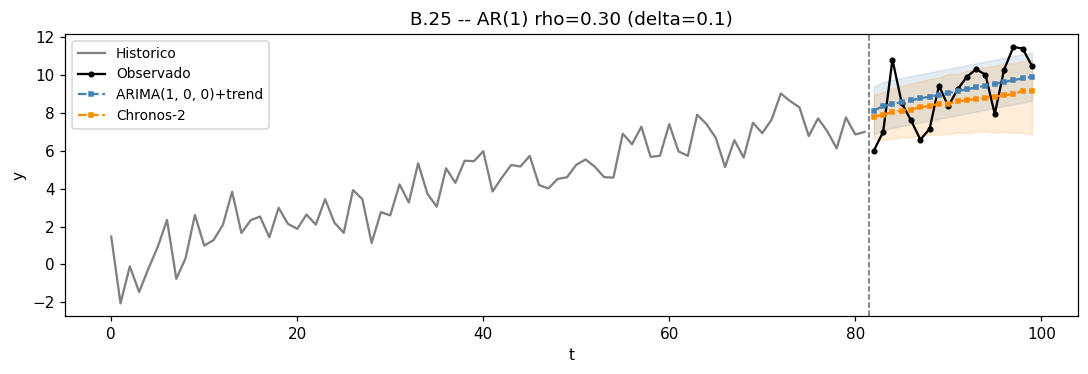

In [51]:
try:
    # B.25 -- AR(1) rho=0.30  [tendencia fuerte delta=0.1]
    cl  = ARIMAWithTrendModel((1, 0, 0), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.3], thetas=[], delta=0.1, sigma=1.0, seed=SEED)
    verify_dgp("B.25 -- AR(1) rho=0.30 (delta=0.1)", dgp, {}, cl, CHECKS_AR_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.25")
    log("\n" + "="*60 + "\nB.25 -- AR(1) rho=0.30 (delta=0.1)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(1, 0, 0)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.25 -- AR(1) rho=0.30 (delta=0.1)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.25 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:07:58  ────────────────────────────────────────────────────────────
19:07:58  VERIFICACION DGP: B.26 -- AR(1) rho=0.90 (delta=0.1)
19:07:58  ────────────────────────────────────────────────────────────
19:07:58    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:07:59    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [81.3989 81.3127 81.245 ]
19:07:59    -> TODAS LAS VERIFICACIONES PASARON
19:07:59  Exp B.26: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:07:59    T=50 H=6, R=500: cargando exp_B_26_T50_R500.csv
19:07:59    T=100 H=18, R=500: cargando exp_B_26_T100_R500.csv
19:07:59    T=200 H=24, R=500: cargando exp_B_26_T200_R500.csv
19:07:59  
B.26 -- AR(1) rho=0.90 (delta=0.1)


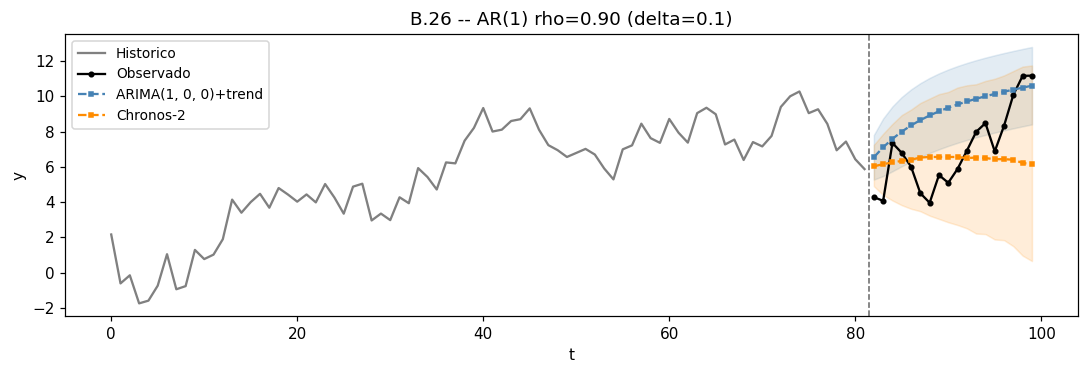

In [52]:
try:
    # B.26 -- AR(1) rho=0.90  [tendencia fuerte delta=0.1]
    cl  = ARIMAWithTrendModel((1, 0, 0), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.9], thetas=[], delta=0.1, sigma=1.0, seed=SEED)
    verify_dgp("B.26 -- AR(1) rho=0.90 (delta=0.1)", dgp, {}, cl, CHECKS_AR_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.26")
    log("\n" + "="*60 + "\nB.26 -- AR(1) rho=0.90 (delta=0.1)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(1, 0, 0)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.26 -- AR(1) rho=0.90 (delta=0.1)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.26 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:08:00  ────────────────────────────────────────────────────────────
19:08:00  VERIFICACION DGP: B.27 -- AR(2) rho=0.30 (delta=0.1)
19:08:00  ────────────────────────────────────────────────────────────
19:08:00    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:08:00    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [80.2105 80.2044 80.2563]
19:08:00    -> TODAS LAS VERIFICACIONES PASARON
19:08:00  Exp B.27: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:08:00    T=50 H=6, R=500: cargando exp_B_27_T50_R500.csv
19:08:00    T=100 H=18, R=500: cargando exp_B_27_T100_R500.csv
19:08:00    T=200 H=24, R=500: cargando exp_B_27_T200_R500.csv
19:08:00  
B.27 -- AR(2) rho=0.30 (delta=0.1)


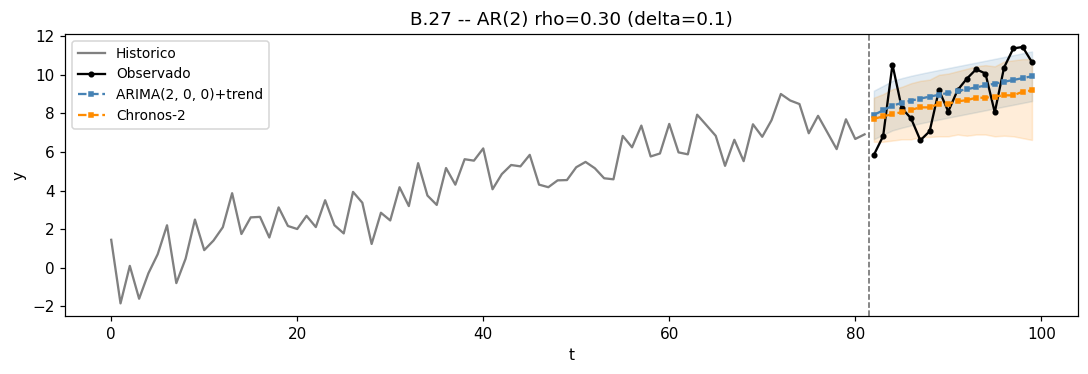

In [53]:
try:
    # B.27 -- AR(2) rho=0.30  [tendencia fuerte delta=0.1]
    cl  = ARIMAWithTrendModel((2, 0, 0), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.3, 0.1], thetas=[], delta=0.1, sigma=1.0, seed=SEED)
    verify_dgp("B.27 -- AR(2) rho=0.30 (delta=0.1)", dgp, {}, cl, CHECKS_AR_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.27")
    log("\n" + "="*60 + "\nB.27 -- AR(2) rho=0.30 (delta=0.1)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(2, 0, 0)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.27 -- AR(2) rho=0.30 (delta=0.1)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.27 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:08:02  ────────────────────────────────────────────────────────────
19:08:02  VERIFICACION DGP: B.28 -- AR(2) rho=0.90 (delta=0.1)
19:08:02  ────────────────────────────────────────────────────────────
19:08:02    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:08:03    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [80.4381 80.3598 80.3248]
19:08:03    -> TODAS LAS VERIFICACIONES PASARON
19:08:03  Exp B.28: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:08:03    T=50 H=6, R=500: cargando exp_B_28_T50_R500.csv
19:08:03    T=100 H=18, R=500: cargando exp_B_28_T100_R500.csv
19:08:03    T=200 H=24, R=500: cargando exp_B_28_T200_R500.csv
19:08:03  
B.28 -- AR(2) rho=0.90 (delta=0.1)


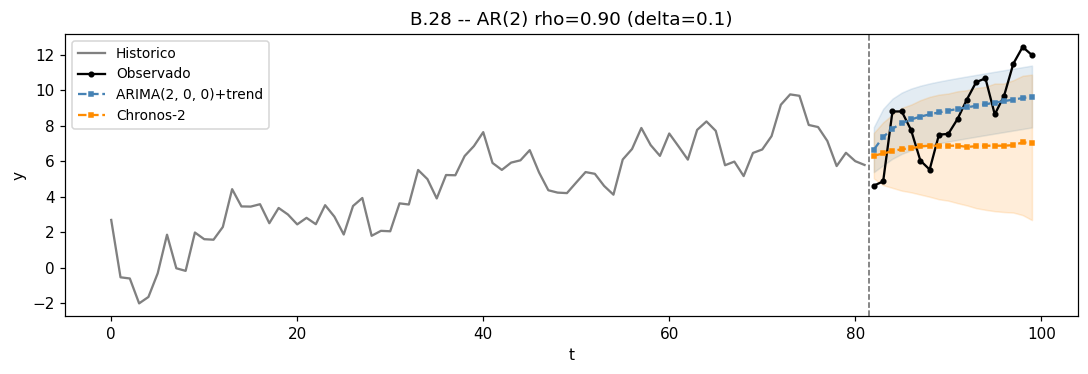

In [54]:
try:
    # B.28 -- AR(2) rho=0.90  [tendencia fuerte delta=0.1]
    cl  = ARIMAWithTrendModel((2, 0, 0), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.9, -0.2], thetas=[], delta=0.1, sigma=1.0, seed=SEED)
    verify_dgp("B.28 -- AR(2) rho=0.90 (delta=0.1)", dgp, {}, cl, CHECKS_AR_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.28")
    log("\n" + "="*60 + "\nB.28 -- AR(2) rho=0.90 (delta=0.1)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(2, 0, 0)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.28 -- AR(2) rho=0.90 (delta=0.1)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.28 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:08:04  ────────────────────────────────────────────────────────────
19:08:04  VERIFICACION DGP: B.29 -- AR(3) rho=0.30 (delta=0.1)
19:08:04  ────────────────────────────────────────────────────────────
19:08:04    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:08:05    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [80.1388 80.2256 80.2698]
19:08:05    -> TODAS LAS VERIFICACIONES PASARON
19:08:05  Exp B.29: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:08:05    T=50 H=6, R=500: cargando exp_B_29_T50_R500.csv
19:08:05    T=100 H=18, R=500: cargando exp_B_29_T100_R500.csv
19:08:05    T=200 H=24, R=500: cargando exp_B_29_T200_R500.csv
19:08:05  
B.29 -- AR(3) rho=0.30 (delta=0.1)


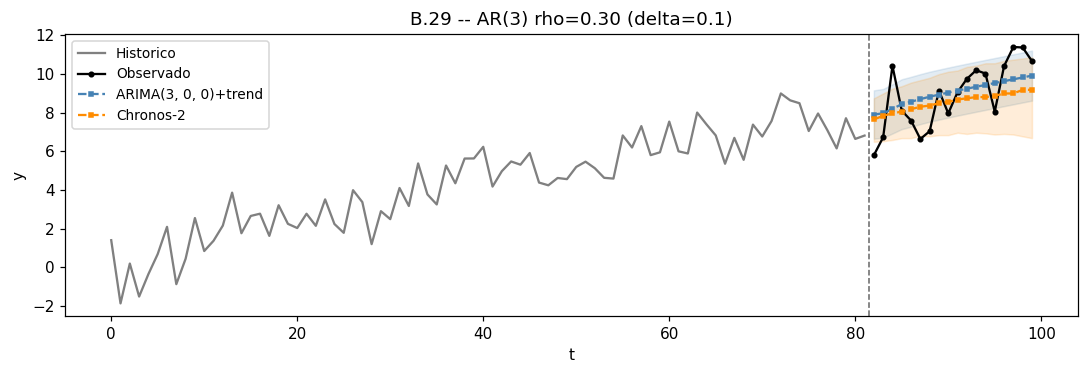

In [55]:
try:
    # B.29 -- AR(3) rho=0.30  [tendencia fuerte delta=0.1]
    cl  = ARIMAWithTrendModel((3, 0, 0), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.3, 0.1, 0.05], thetas=[], delta=0.1, sigma=1.0, seed=SEED)
    verify_dgp("B.29 -- AR(3) rho=0.30 (delta=0.1)", dgp, {}, cl, CHECKS_AR_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.29")
    log("\n" + "="*60 + "\nB.29 -- AR(3) rho=0.30 (delta=0.1)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(3, 0, 0)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.29 -- AR(3) rho=0.30 (delta=0.1)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.29 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:08:07  ────────────────────────────────────────────────────────────
19:08:07  VERIFICACION DGP: B.30 -- AR(3) rho=0.90 (delta=0.1)
19:08:07  ────────────────────────────────────────────────────────────
19:08:07    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:08:09    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [80.4189 80.3533 80.3844]
19:08:09    -> TODAS LAS VERIFICACIONES PASARON
19:08:09  Exp B.30: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:08:09    T=50 H=6, R=500: cargando exp_B_30_T50_R500.csv
19:08:09    T=100 H=18, R=500: cargando exp_B_30_T100_R500.csv
19:08:09    T=200 H=24, R=500: cargando exp_B_30_T200_R500.csv
19:08:09  
B.30 -- AR(3) rho=0.90 (delta=0.1)


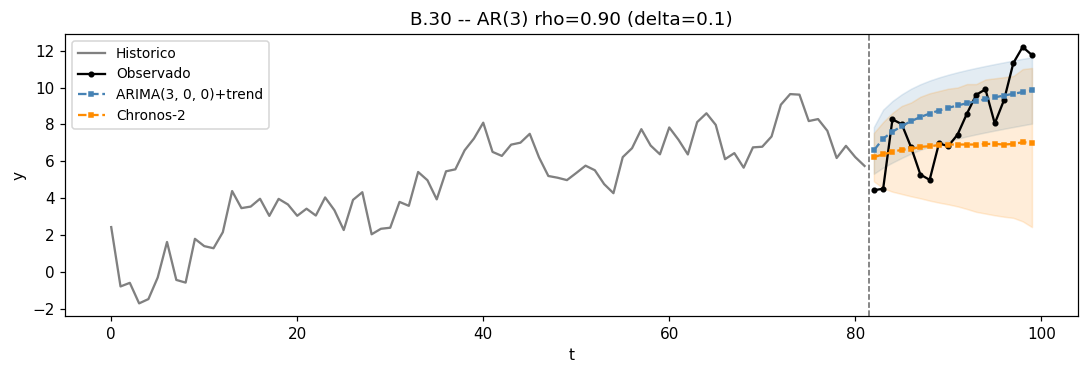

In [56]:
try:
    # B.30 -- AR(3) rho=0.90  [tendencia fuerte delta=0.1]
    cl  = ARIMAWithTrendModel((3, 0, 0), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.9, -0.2, 0.1], thetas=[], delta=0.1, sigma=1.0, seed=SEED)
    verify_dgp("B.30 -- AR(3) rho=0.90 (delta=0.1)", dgp, {}, cl, CHECKS_AR_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.30")
    log("\n" + "="*60 + "\nB.30 -- AR(3) rho=0.90 (delta=0.1)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(3, 0, 0)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.30 -- AR(3) rho=0.90 (delta=0.1)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.30 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:08:10  ────────────────────────────────────────────────────────────
19:08:10  VERIFICACION DGP: B.31 -- AR(4) rho=0.30 (delta=0.1)
19:08:10  ────────────────────────────────────────────────────────────
19:08:10    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:08:11    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [80.1451 80.186  80.2817]
19:08:11    -> TODAS LAS VERIFICACIONES PASARON
19:08:11  Exp B.31: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:08:11    T=50 H=6, R=500: cargando exp_B_31_T50_R500.csv
19:08:12    T=100 H=18, R=500: cargando exp_B_31_T100_R500.csv
19:08:12    T=200 H=24, R=500: cargando exp_B_31_T200_R500.csv
19:08:12  
B.31 -- AR(4) rho=0.30 (delta=0.1)


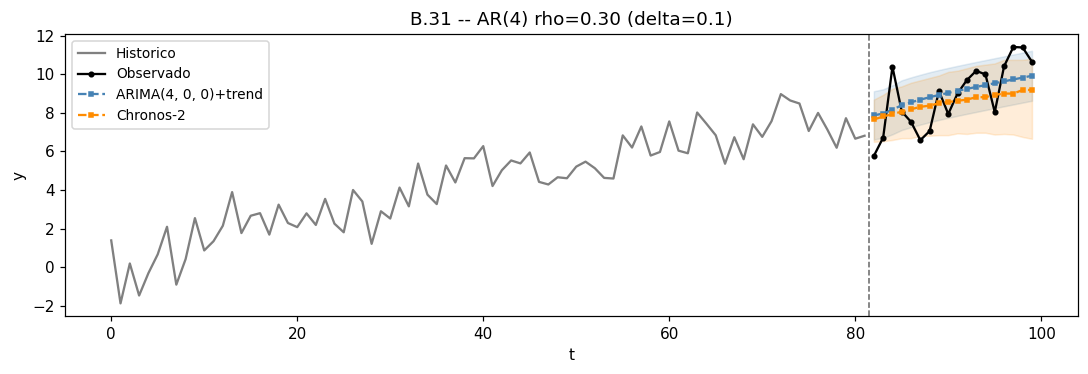

In [57]:
try:
    # B.31 -- AR(4) rho=0.30  [tendencia fuerte delta=0.1]
    cl  = ARIMAWithTrendModel((4, 0, 0), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.3, 0.1, 0.05, 0.02], thetas=[], delta=0.1, sigma=1.0, seed=SEED)
    verify_dgp("B.31 -- AR(4) rho=0.30 (delta=0.1)", dgp, {}, cl, CHECKS_AR_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.31")
    log("\n" + "="*60 + "\nB.31 -- AR(4) rho=0.30 (delta=0.1)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(4, 0, 0)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.31 -- AR(4) rho=0.30 (delta=0.1)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.31 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:08:15  ────────────────────────────────────────────────────────────
19:08:15  VERIFICACION DGP: B.32 -- AR(4) rho=0.90 (delta=0.1)
19:08:15  ────────────────────────────────────────────────────────────
19:08:15    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:08:15    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [80.2725 80.2673 80.3096]
19:08:15    -> TODAS LAS VERIFICACIONES PASARON
19:08:15  Exp B.32: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:08:15    T=50 H=6, R=500: cargando exp_B_32_T50_R500.csv
19:08:15    T=100 H=18, R=500: cargando exp_B_32_T100_R500.csv
19:08:15    T=200 H=24, R=500: cargando exp_B_32_T200_R500.csv
19:08:15  
B.32 -- AR(4) rho=0.90 (delta=0.1)


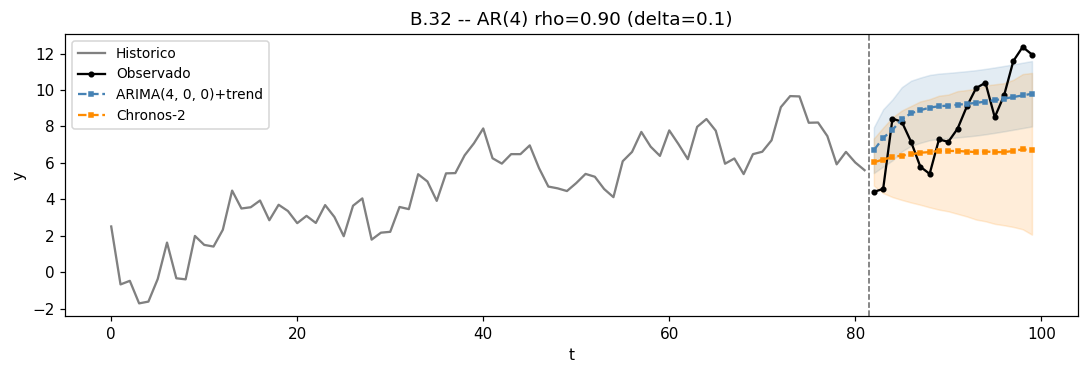

In [58]:
try:
    # B.32 -- AR(4) rho=0.90  [tendencia fuerte delta=0.1]
    cl  = ARIMAWithTrendModel((4, 0, 0), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.9, -0.2, 0.1, -0.05], thetas=[], delta=0.1, sigma=1.0, seed=SEED)
    verify_dgp("B.32 -- AR(4) rho=0.90 (delta=0.1)", dgp, {}, cl, CHECKS_AR_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.32")
    log("\n" + "="*60 + "\nB.32 -- AR(4) rho=0.90 (delta=0.1)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(4, 0, 0)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.32 -- AR(4) rho=0.90 (delta=0.1)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.32 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:08:18  ────────────────────────────────────────────────────────────
19:08:18  VERIFICACION DGP: B.33 -- MA(1) theta=0.30 (delta=0.1)
19:08:18  ────────────────────────────────────────────────────────────
19:08:18    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:08:18    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [80.0928 80.1271 80.227 ]
19:08:18    -> TODAS LAS VERIFICACIONES PASARON
19:08:18  Exp B.33: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:08:18    T=50 H=6, R=500: cargando exp_B_33_T50_R500.csv
19:08:18    T=100 H=18, R=500: cargando exp_B_33_T100_R500.csv
19:08:18    T=200 H=24, R=500: cargando exp_B_33_T200_R500.csv
19:08:18  
B.33 -- MA(1) theta=0.30 (delta=0.1)


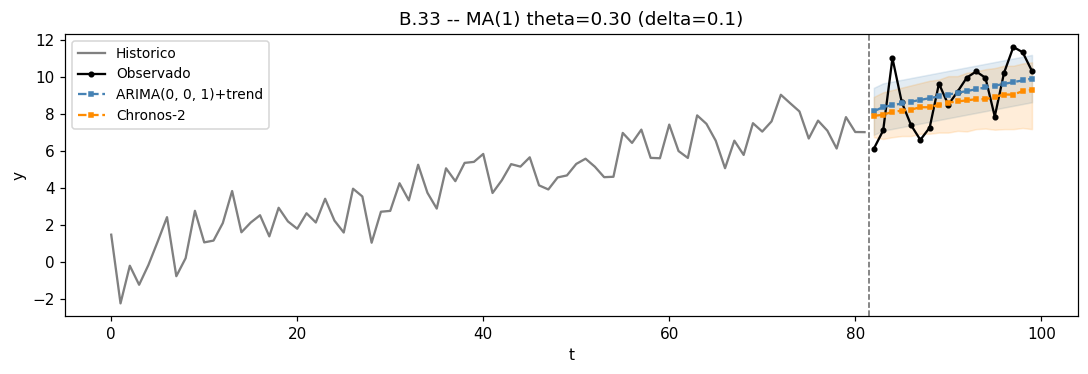

In [59]:
try:
    # B.33 -- MA(1) theta=0.30  [tendencia fuerte delta=0.1]
    cl  = ARIMAWithTrendModel((0, 0, 1), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[], thetas=[0.3], delta=0.1, sigma=1.0, seed=SEED)
    verify_dgp("B.33 -- MA(1) theta=0.30 (delta=0.1)", dgp, {}, cl, CHECKS_MA_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.33")
    log("\n" + "="*60 + "\nB.33 -- MA(1) theta=0.30 (delta=0.1)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(0, 0, 1)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.33 -- MA(1) theta=0.30 (delta=0.1)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.33 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:08:20  ────────────────────────────────────────────────────────────
19:08:20  VERIFICACION DGP: B.34 -- MA(1) theta=0.90 (delta=0.1)
19:08:20  ────────────────────────────────────────────────────────────
19:08:20    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:08:20    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [80.4659 80.0928 80.1927]
19:08:20    -> TODAS LAS VERIFICACIONES PASARON
19:08:20  Exp B.34: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:08:20    T=50 H=6, R=500: cargando exp_B_34_T50_R500.csv
19:08:20    T=100 H=18, R=500: cargando exp_B_34_T100_R500.csv
19:08:20    T=200 H=24, R=500: cargando exp_B_34_T200_R500.csv
19:08:20  
B.34 -- MA(1) theta=0.90 (delta=0.1)


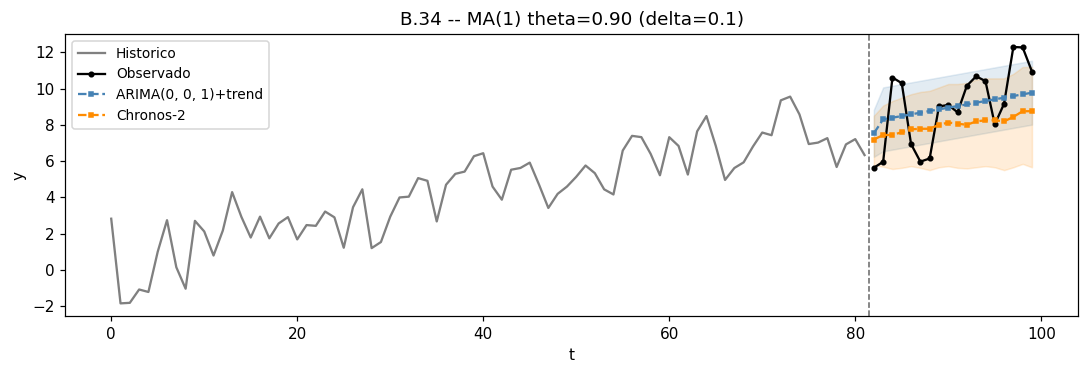

In [60]:
try:
    # B.34 -- MA(1) theta=0.90  [tendencia fuerte delta=0.1]
    cl  = ARIMAWithTrendModel((0, 0, 1), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[], thetas=[0.9], delta=0.1, sigma=1.0, seed=SEED)
    verify_dgp("B.34 -- MA(1) theta=0.90 (delta=0.1)", dgp, {}, cl, CHECKS_MA_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.34")
    log("\n" + "="*60 + "\nB.34 -- MA(1) theta=0.90 (delta=0.1)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(0, 0, 1)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.34 -- MA(1) theta=0.90 (delta=0.1)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.34 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:08:21  ────────────────────────────────────────────────────────────
19:08:21  VERIFICACION DGP: B.35 -- MA(2) theta=0.30 (delta=0.1)
19:08:21  ────────────────────────────────────────────────────────────
19:08:21    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:08:22    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [80.2014 80.1444 80.2213]
19:08:22    -> TODAS LAS VERIFICACIONES PASARON
19:08:22  Exp B.35: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:08:22    T=50 H=6, R=500: cargando exp_B_35_T50_R500.csv
19:08:22    T=100 H=18, R=500: cargando exp_B_35_T100_R500.csv
19:08:22    T=200 H=24, R=500: cargando exp_B_35_T200_R500.csv
19:08:22  
B.35 -- MA(2) theta=0.30 (delta=0.1)


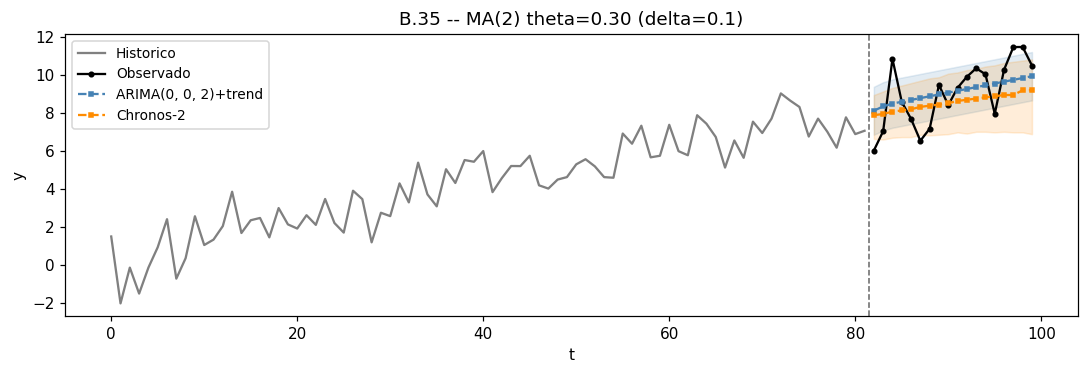

In [61]:
try:
    # B.35 -- MA(2) theta=0.30  [tendencia fuerte delta=0.1]
    cl  = ARIMAWithTrendModel((0, 0, 2), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[], thetas=[0.3, 0.1], delta=0.1, sigma=1.0, seed=SEED)
    verify_dgp("B.35 -- MA(2) theta=0.30 (delta=0.1)", dgp, {}, cl, CHECKS_MA_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.35")
    log("\n" + "="*60 + "\nB.35 -- MA(2) theta=0.30 (delta=0.1)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(0, 0, 2)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.35 -- MA(2) theta=0.30 (delta=0.1)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.35 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:08:24  ────────────────────────────────────────────────────────────
19:08:24  VERIFICACION DGP: B.36 -- MA(2) theta=0.90 (delta=0.1)
19:08:24  ────────────────────────────────────────────────────────────
19:08:24    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:08:24    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [80.2839 80.1043 80.187 ]
19:08:24    -> TODAS LAS VERIFICACIONES PASARON
19:08:24  Exp B.36: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:08:24    T=50 H=6, R=500: cargando exp_B_36_T50_R500.csv
19:08:24    T=100 H=18, R=500: cargando exp_B_36_T100_R500.csv
19:08:24    T=200 H=24, R=500: cargando exp_B_36_T200_R500.csv
19:08:24  
B.36 -- MA(2) theta=0.90 (delta=0.1)


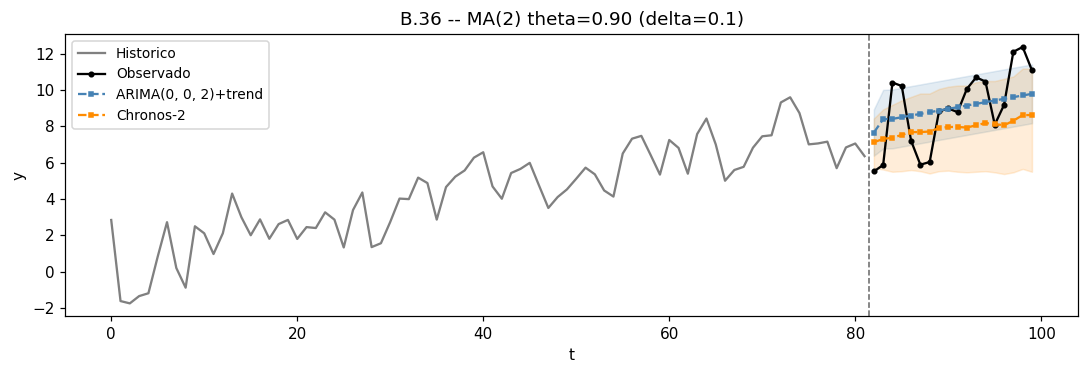

In [62]:
try:
    # B.36 -- MA(2) theta=0.90  [tendencia fuerte delta=0.1]
    cl  = ARIMAWithTrendModel((0, 0, 2), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[], thetas=[0.9, 0.1], delta=0.1, sigma=1.0, seed=SEED)
    verify_dgp("B.36 -- MA(2) theta=0.90 (delta=0.1)", dgp, {}, cl, CHECKS_MA_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.36")
    log("\n" + "="*60 + "\nB.36 -- MA(2) theta=0.90 (delta=0.1)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(0, 0, 2)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.36 -- MA(2) theta=0.90 (delta=0.1)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.36 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:08:26  ────────────────────────────────────────────────────────────
19:08:26  VERIFICACION DGP: B.37 -- MA(3) theta=0.30 (delta=0.1)
19:08:26  ────────────────────────────────────────────────────────────
19:08:26    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:08:27    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [80.2567 80.0829 80.2108]
19:08:27    -> TODAS LAS VERIFICACIONES PASARON
19:08:27  Exp B.37: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:08:27    T=50 H=6, R=500: cargando exp_B_37_T50_R500.csv
19:08:27    T=100 H=18, R=500: cargando exp_B_37_T100_R500.csv
19:08:27    T=200 H=24, R=500: cargando exp_B_37_T200_R500.csv
19:08:27  
B.37 -- MA(3) theta=0.30 (delta=0.1)


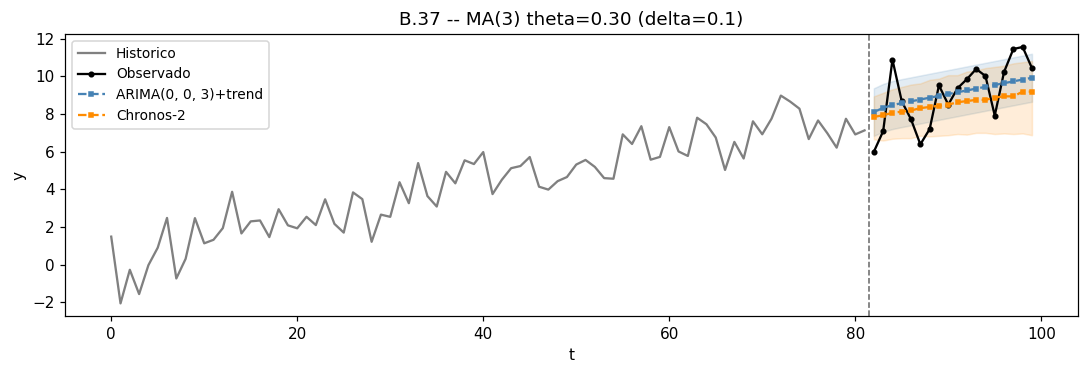

In [63]:
try:
    # B.37 -- MA(3) theta=0.30  [tendencia fuerte delta=0.1]
    cl  = ARIMAWithTrendModel((0, 0, 3), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[], thetas=[0.3, 0.1, -0.05], delta=0.1, sigma=1.0, seed=SEED)
    verify_dgp("B.37 -- MA(3) theta=0.30 (delta=0.1)", dgp, {}, cl, CHECKS_MA_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.37")
    log("\n" + "="*60 + "\nB.37 -- MA(3) theta=0.30 (delta=0.1)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(0, 0, 3)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.37 -- MA(3) theta=0.30 (delta=0.1)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.37 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:08:28  ────────────────────────────────────────────────────────────
19:08:28  VERIFICACION DGP: B.38 -- MA(3) theta=0.90 (delta=0.1)
19:08:28  ────────────────────────────────────────────────────────────
19:08:28    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:08:30    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [80.3302 80.0564 80.1792]
19:08:30    -> TODAS LAS VERIFICACIONES PASARON
19:08:30  Exp B.38: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:08:30    T=50 H=6, R=500: cargando exp_B_38_T50_R500.csv
19:08:30    T=100 H=18, R=500: cargando exp_B_38_T100_R500.csv
19:08:30    T=200 H=24, R=500: cargando exp_B_38_T200_R500.csv
19:08:30  
B.38 -- MA(3) theta=0.90 (delta=0.1)


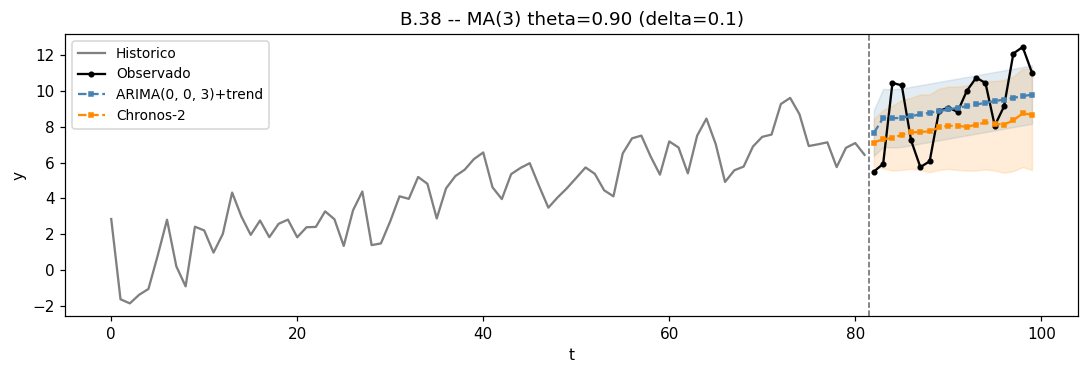

In [64]:
try:
    # B.38 -- MA(3) theta=0.90  [tendencia fuerte delta=0.1]
    cl  = ARIMAWithTrendModel((0, 0, 3), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[], thetas=[0.9, 0.1, -0.05], delta=0.1, sigma=1.0, seed=SEED)
    verify_dgp("B.38 -- MA(3) theta=0.90 (delta=0.1)", dgp, {}, cl, CHECKS_MA_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.38")
    log("\n" + "="*60 + "\nB.38 -- MA(3) theta=0.90 (delta=0.1)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(0, 0, 3)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.38 -- MA(3) theta=0.90 (delta=0.1)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.38 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:08:33  ────────────────────────────────────────────────────────────
19:08:33  VERIFICACION DGP: B.39 -- MA(4) theta=0.30 (delta=0.1)
19:08:33  ────────────────────────────────────────────────────────────
19:08:33    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:08:34    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [80.2701 80.0577 80.2375]
19:08:34    -> TODAS LAS VERIFICACIONES PASARON
19:08:34  Exp B.39: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:08:34    T=50 H=6, R=500: cargando exp_B_39_T50_R500.csv
19:08:34    T=100 H=18, R=500: cargando exp_B_39_T100_R500.csv
19:08:34    T=200 H=24, R=500: cargando exp_B_39_T200_R500.csv
19:08:34  
B.39 -- MA(4) theta=0.30 (delta=0.1)


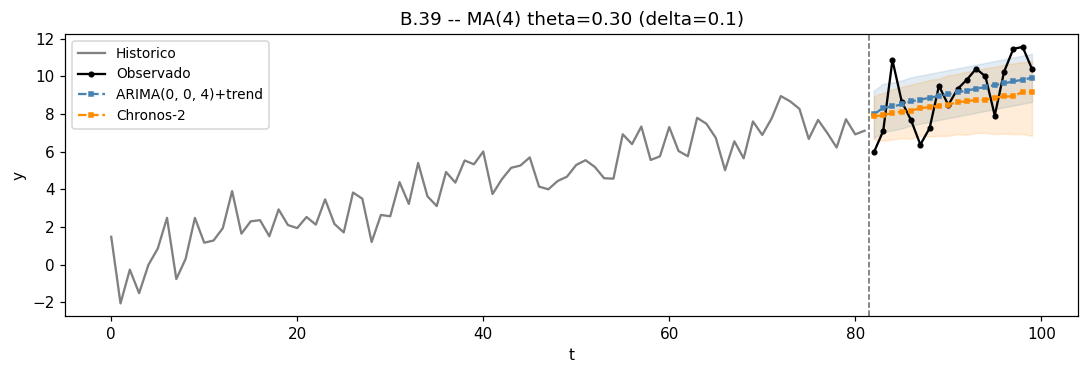

In [65]:
try:
    # B.39 -- MA(4) theta=0.30  [tendencia fuerte delta=0.1]
    cl  = ARIMAWithTrendModel((0, 0, 4), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[], thetas=[0.3, 0.1, -0.05, 0.02], delta=0.1, sigma=1.0, seed=SEED)
    verify_dgp("B.39 -- MA(4) theta=0.30 (delta=0.1)", dgp, {}, cl, CHECKS_MA_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.39")
    log("\n" + "="*60 + "\nB.39 -- MA(4) theta=0.30 (delta=0.1)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(0, 0, 4)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.39 -- MA(4) theta=0.30 (delta=0.1)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.39 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:08:36  ────────────────────────────────────────────────────────────
19:08:36  VERIFICACION DGP: B.40 -- MA(4) theta=0.90 (delta=0.1)
19:08:36  ────────────────────────────────────────────────────────────
19:08:36    [PASS] Pendiente OLS ~ delta: no aplica (sin delta)
19:08:37    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [80.3608 80.0238 80.2017]
19:08:37    -> TODAS LAS VERIFICACIONES PASARON
19:08:37  Exp B.40: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:08:37    T=50 H=6, R=500: cargando exp_B_40_T50_R500.csv
19:08:37    T=100 H=18, R=500: cargando exp_B_40_T100_R500.csv
19:08:37    T=200 H=24, R=500: cargando exp_B_40_T200_R500.csv
19:08:37  
B.40 -- MA(4) theta=0.90 (delta=0.1)


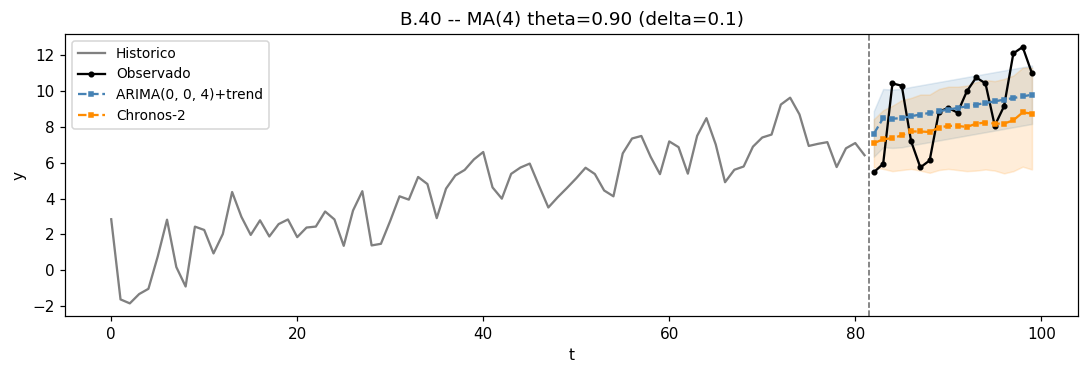

In [66]:
try:
    # B.40 -- MA(4) theta=0.90  [tendencia fuerte delta=0.1]
    cl  = ARIMAWithTrendModel((0, 0, 4), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[], thetas=[0.9, 0.1, -0.05, 0.02], delta=0.1, sigma=1.0, seed=SEED)
    verify_dgp("B.40 -- MA(4) theta=0.90 (delta=0.1)", dgp, {}, cl, CHECKS_MA_TREND)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.40")
    log("\n" + "="*60 + "\nB.40 -- MA(4) theta=0.90 (delta=0.1)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(0, 0, 4)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.40 -- MA(4) theta=0.90 (delta=0.1)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.40 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:08:39  ────────────────────────────────────────────────────────────
19:08:39  VERIFICACION DGP: B.41 -- ARMA(1,1) rho=0.30 (delta=0.1)
19:08:39  ────────────────────────────────────────────────────────────
19:08:39    [FAIL] Estacionariedad (ADF): ADF p=0.9539 (umbral 0.05)
19:08:39    [FAIL] AIC ARMA < baseline: ARIMA.fit() got an unexpected keyword argument 'disp'
19:08:39    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [80.2018 80.1696 80.2292]
19:08:39    -> 2 FALLO(S)
19:08:39  Exp B.41: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:08:39    T=50 H=6, R=500: cargando exp_B_41_T50_R500.csv
19:08:39    T=100 H=18, R=500: cargando exp_B_41_T100_R500.csv
19:08:39    T=200 H=24, R=500: cargando exp_B_41_T200_R500.csv
19:08:39  
B.41 -- ARMA(1,1) rho=0.30 (delta=0.1)


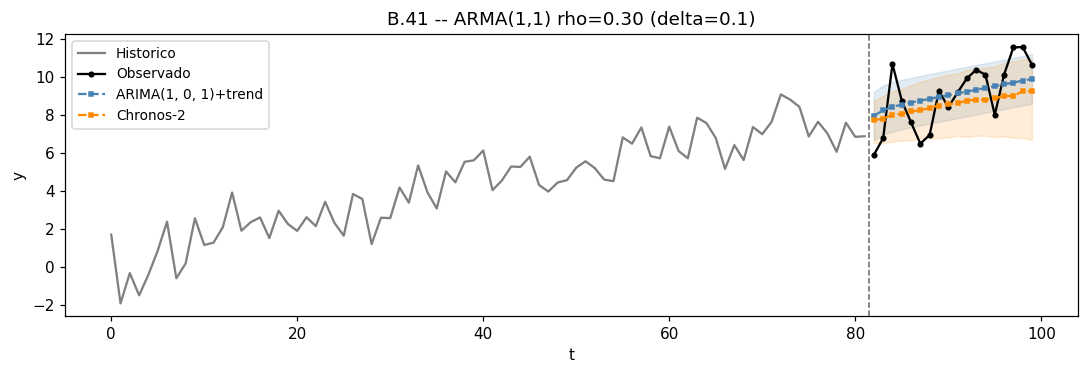

In [67]:
try:
    # B.41 -- ARMA(1,1) rho=0.30  [tendencia fuerte delta=0.1]
    cl  = ARIMAWithTrendModel((1, 0, 1), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.3], thetas=[0.1], delta=0.1, sigma=1.0, seed=SEED)
    verify_dgp("B.41 -- ARMA(1,1) rho=0.30 (delta=0.1)", dgp, {}, cl, CHECKS_ARMA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.41")
    log("\n" + "="*60 + "\nB.41 -- ARMA(1,1) rho=0.30 (delta=0.1)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(1, 0, 1)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.41 -- ARMA(1,1) rho=0.30 (delta=0.1)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.41 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:08:41  ────────────────────────────────────────────────────────────
19:08:41  VERIFICACION DGP: B.42 -- ARMA(1,1) rho=0.90 (delta=0.1)
19:08:41  ────────────────────────────────────────────────────────────
19:08:41    [FAIL] Estacionariedad (ADF): ADF p=0.8812 (umbral 0.05)
19:08:41    [FAIL] AIC ARMA < baseline: ARIMA.fit() got an unexpected keyword argument 'disp'
19:08:42    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [81.8657 81.7268 81.6105]
19:08:42    -> 2 FALLO(S)
19:08:42  Exp B.42: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:08:42    T=50 H=6, R=500: cargando exp_B_42_T50_R500.csv
19:08:42    T=100 H=18, R=500: cargando exp_B_42_T100_R500.csv
19:08:42    T=200 H=24, R=500: cargando exp_B_42_T200_R500.csv
19:08:42  
B.42 -- ARMA(1,1) rho=0.90 (delta=0.1)


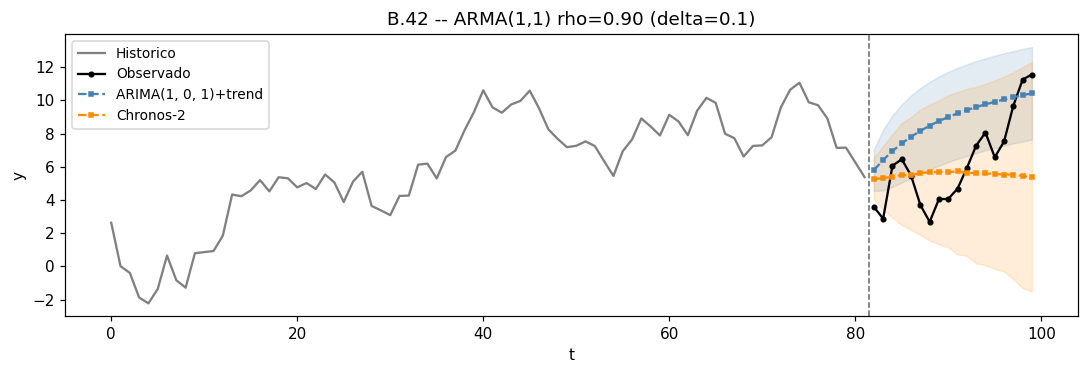

In [68]:
try:
    # B.42 -- ARMA(1,1) rho=0.90  [tendencia fuerte delta=0.1]
    cl  = ARIMAWithTrendModel((1, 0, 1), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.9], thetas=[0.3], delta=0.1, sigma=1.0, seed=SEED)
    verify_dgp("B.42 -- ARMA(1,1) rho=0.90 (delta=0.1)", dgp, {}, cl, CHECKS_ARMA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.42")
    log("\n" + "="*60 + "\nB.42 -- ARMA(1,1) rho=0.90 (delta=0.1)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(1, 0, 1)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.42 -- ARMA(1,1) rho=0.90 (delta=0.1)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.42 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:08:43  ────────────────────────────────────────────────────────────
19:08:43  VERIFICACION DGP: B.43 -- ARMA(2,2) rho=0.30 (delta=0.1)
19:08:43  ────────────────────────────────────────────────────────────
19:08:43    [FAIL] Estacionariedad (ADF): ADF p=0.9524 (umbral 0.05)
19:08:43    [FAIL] AIC ARMA < baseline: ARIMA.fit() got an unexpected keyword argument 'disp'
19:08:44    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [80.2901 80.2169 80.2731]
19:08:44    -> 2 FALLO(S)
19:08:44  Exp B.43: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:08:44    T=50 H=6, R=500: cargando exp_B_43_T50_R500.csv
19:08:44    T=100 H=18, R=500: cargando exp_B_43_T100_R500.csv
19:08:44    T=200 H=24, R=500: cargando exp_B_43_T200_R500.csv
19:08:44  
B.43 -- ARMA(2,2) rho=0.30 (delta=0.1)


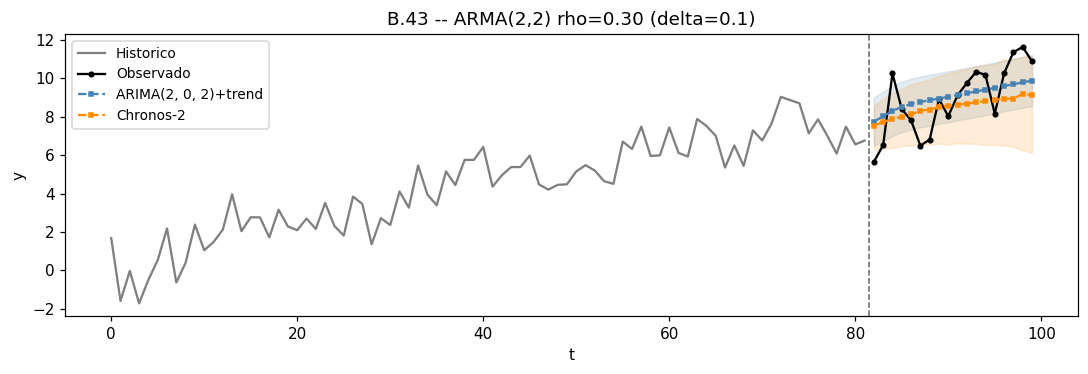

In [69]:
try:
    # B.43 -- ARMA(2,2) rho=0.30  [tendencia fuerte delta=0.1]
    cl  = ARIMAWithTrendModel((2, 0, 2), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.3, 0.1], thetas=[0.1, 0.05], delta=0.1, sigma=1.0, seed=SEED)
    verify_dgp("B.43 -- ARMA(2,2) rho=0.30 (delta=0.1)", dgp, {}, cl, CHECKS_ARMA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.43")
    log("\n" + "="*60 + "\nB.43 -- ARMA(2,2) rho=0.30 (delta=0.1)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(2, 0, 2)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.43 -- ARMA(2,2) rho=0.30 (delta=0.1)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.43 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:08:46  ────────────────────────────────────────────────────────────
19:08:46  VERIFICACION DGP: B.44 -- ARMA(2,2) rho=0.90 (delta=0.1)
19:08:46  ────────────────────────────────────────────────────────────
19:08:46    [FAIL] Estacionariedad (ADF): ADF p=0.9497 (umbral 0.05)
19:08:46    [FAIL] AIC ARMA < baseline: ARIMA.fit() got an unexpected keyword argument 'disp'
19:08:47    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [80.5754 80.4239 80.3472]
19:08:47    -> 2 FALLO(S)
19:08:47  Exp B.44: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:08:47    T=50 H=6, R=500: cargando exp_B_44_T50_R500.csv
19:08:47    T=100 H=18, R=500: cargando exp_B_44_T100_R500.csv
19:08:47    T=200 H=24, R=500: cargando exp_B_44_T200_R500.csv
19:08:47  
B.44 -- ARMA(2,2) rho=0.90 (delta=0.1)


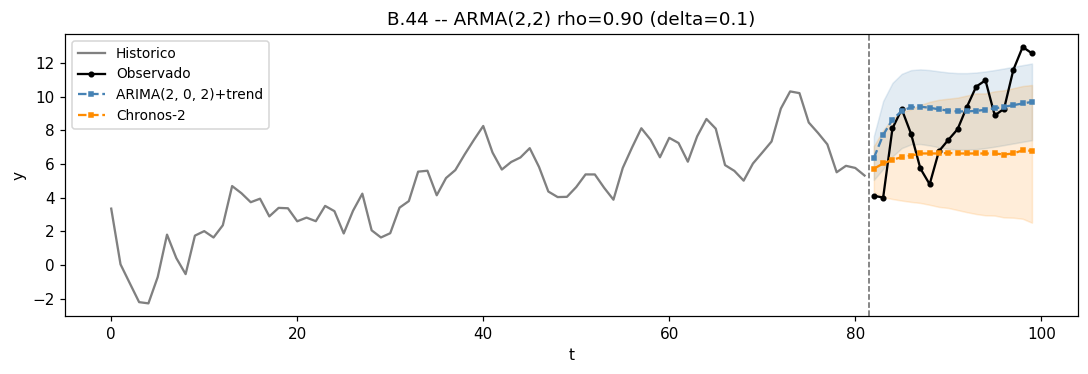

In [70]:
try:
    # B.44 -- ARMA(2,2) rho=0.90  [tendencia fuerte delta=0.1]
    cl  = ARIMAWithTrendModel((2, 0, 2), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.9, -0.2], thetas=[0.3, -0.1], delta=0.1, sigma=1.0, seed=SEED)
    verify_dgp("B.44 -- ARMA(2,2) rho=0.90 (delta=0.1)", dgp, {}, cl, CHECKS_ARMA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.44")
    log("\n" + "="*60 + "\nB.44 -- ARMA(2,2) rho=0.90 (delta=0.1)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(2, 0, 2)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.44 -- ARMA(2,2) rho=0.90 (delta=0.1)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.44 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:08:49  ────────────────────────────────────────────────────────────
19:08:49  VERIFICACION DGP: B.45 -- ARMA(1,4) rho=0.30 (delta=0.1)
19:08:49  ────────────────────────────────────────────────────────────
19:08:49    [FAIL] Estacionariedad (ADF): ADF p=0.9537 (umbral 0.05)
19:08:49    [FAIL] AIC ARMA < baseline: ARIMA.fit() got an unexpected keyword argument 'disp'
19:08:50    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [80.2758 80.1455 80.224 ]
19:08:50    -> 2 FALLO(S)
19:08:50  Exp B.45: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:08:50    T=50 H=6, R=500: cargando exp_B_45_T50_R500.csv
19:08:50    T=100 H=18, R=500: cargando exp_B_45_T100_R500.csv
19:08:50    T=200 H=24, R=500: cargando exp_B_45_T200_R500.csv
19:08:50  
B.45 -- ARMA(1,4) rho=0.30 (delta=0.1)


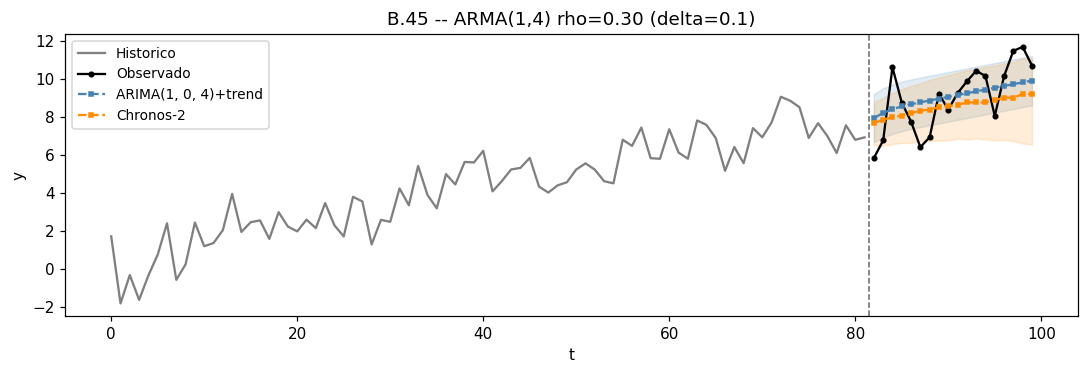

In [71]:
try:
    # B.45 -- ARMA(1,4) rho=0.30  [tendencia fuerte delta=0.1]
    cl  = ARIMAWithTrendModel((1, 0, 4), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.3], thetas=[0.1, 0.05, -0.03, 0.01], delta=0.1, sigma=1.0, seed=SEED)
    verify_dgp("B.45 -- ARMA(1,4) rho=0.30 (delta=0.1)", dgp, {}, cl, CHECKS_ARMA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.45")
    log("\n" + "="*60 + "\nB.45 -- ARMA(1,4) rho=0.30 (delta=0.1)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(1, 0, 4)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.45 -- ARMA(1,4) rho=0.30 (delta=0.1)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.45 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:08:53  ────────────────────────────────────────────────────────────
19:08:53  VERIFICACION DGP: B.46 -- ARMA(1,4) rho=0.90 (delta=0.1)
19:08:53  ────────────────────────────────────────────────────────────
19:08:53    [FAIL] Estacionariedad (ADF): ADF p=0.9282 (umbral 0.05)
19:08:53    [FAIL] AIC ARMA < baseline: ARIMA.fit() got an unexpected keyword argument 'disp'
19:08:55    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [81.7174 81.6468 81.5383]
19:08:55    -> 2 FALLO(S)
19:08:55  Exp B.46: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:08:55    T=50 H=6, R=500: cargando exp_B_46_T50_R500.csv
19:08:55    T=100 H=18, R=500: cargando exp_B_46_T100_R500.csv
19:08:55    T=200 H=24, R=500: cargando exp_B_46_T200_R500.csv
19:08:55  
B.46 -- ARMA(1,4) rho=0.90 (delta=0.1)


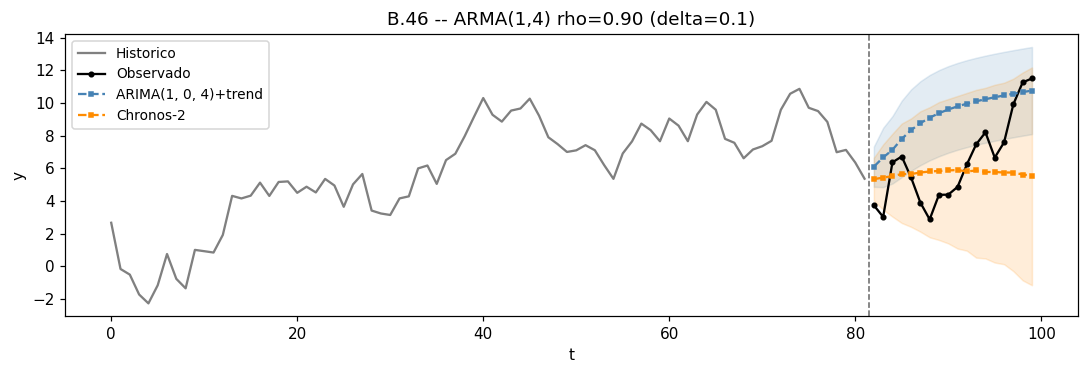

In [72]:
try:
    # B.46 -- ARMA(1,4) rho=0.90  [tendencia fuerte delta=0.1]
    cl  = ARIMAWithTrendModel((1, 0, 4), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.9], thetas=[0.3, -0.1, 0.05, -0.02], delta=0.1, sigma=1.0, seed=SEED)
    verify_dgp("B.46 -- ARMA(1,4) rho=0.90 (delta=0.1)", dgp, {}, cl, CHECKS_ARMA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.46")
    log("\n" + "="*60 + "\nB.46 -- ARMA(1,4) rho=0.90 (delta=0.1)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(1, 0, 4)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.46 -- ARMA(1,4) rho=0.90 (delta=0.1)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.46 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:08:57  ────────────────────────────────────────────────────────────
19:08:57  VERIFICACION DGP: B.47 -- ARMA(4,1) rho=0.30 (delta=0.1)
19:08:57  ────────────────────────────────────────────────────────────
19:08:57    [FAIL] Estacionariedad (ADF): ADF p=0.9521 (umbral 0.05)
19:08:57    [FAIL] AIC ARMA < baseline: ARIMA.fit() got an unexpected keyword argument 'disp'
19:08:58    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [80.1654 80.1984 80.2794]
19:08:58    -> 2 FALLO(S)
19:08:58  Exp B.47: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:08:58    T=50 H=6, R=500: cargando exp_B_47_T50_R500.csv
19:08:58    T=100 H=18, R=500: cargando exp_B_47_T100_R500.csv
19:08:58    T=200 H=24, R=500: cargando exp_B_47_T200_R500.csv
19:08:58  
B.47 -- ARMA(4,1) rho=0.30 (delta=0.1)


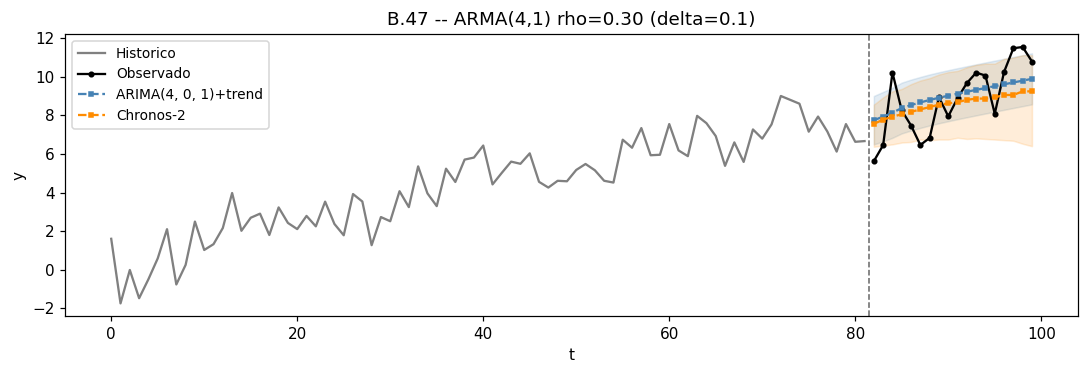

In [73]:
try:
    # B.47 -- ARMA(4,1) rho=0.30  [tendencia fuerte delta=0.1]
    cl  = ARIMAWithTrendModel((4, 0, 1), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.3, 0.1, 0.05, 0.02], thetas=[0.1], delta=0.1, sigma=1.0, seed=SEED)
    verify_dgp("B.47 -- ARMA(4,1) rho=0.30 (delta=0.1)", dgp, {}, cl, CHECKS_ARMA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.47")
    log("\n" + "="*60 + "\nB.47 -- ARMA(4,1) rho=0.30 (delta=0.1)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(4, 0, 1)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.47 -- ARMA(4,1) rho=0.30 (delta=0.1)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.47 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:09:01  ────────────────────────────────────────────────────────────
19:09:01  VERIFICACION DGP: B.48 -- ARMA(4,1) rho=0.90 (delta=0.1)
19:09:01  ────────────────────────────────────────────────────────────
19:09:01    [FAIL] Estacionariedad (ADF): ADF p=0.9451 (umbral 0.05)
19:09:01    [FAIL] AIC ARMA < baseline: ARIMA.fit() got an unexpected keyword argument 'disp'
19:09:02    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [80.3509 80.3047 80.291 ]
19:09:02    -> 2 FALLO(S)
19:09:02  Exp B.48: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:09:02    T=50 H=6, R=500: cargando exp_B_48_T50_R500.csv
19:09:02    T=100 H=18, R=500: cargando exp_B_48_T100_R500.csv
19:09:02    T=200 H=24, R=500: cargando exp_B_48_T200_R500.csv
19:09:02  
B.48 -- ARMA(4,1) rho=0.90 (delta=0.1)


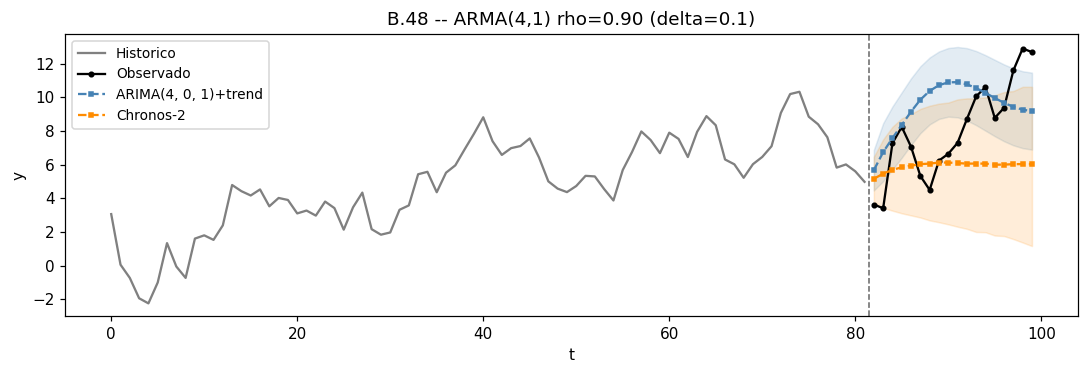

In [74]:
try:
    # B.48 -- ARMA(4,1) rho=0.90  [tendencia fuerte delta=0.1]
    cl  = ARIMAWithTrendModel((4, 0, 1), trend="ct")
    dgp = ARMApqWithTrendDGP(phis=[0.9, -0.2, 0.1, -0.05], thetas=[0.3], delta=0.1, sigma=1.0, seed=SEED)
    verify_dgp("B.48 -- ARMA(4,1) rho=0.90 (delta=0.1)", dgp, {}, cl, CHECKS_ARMA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="B.48")
    log("\n" + "="*60 + "\nB.48 -- ARMA(4,1) rho=0.90 (delta=0.1)\n" + "="*60)
    build_grid_table(res, classical_name="ARIMA(4, 0, 1)+trend")
    plot_simulation_v3(dgp, [cl, chronos], {}, title="B.48 -- ARMA(4,1) rho=0.90 (delta=0.1)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA B.48 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

---
## Bloque C — Random Walk (3 experimentos)

DGP: `Y_t = drift + Y_{t-1} + eps_t`  
Modelo clasico: ARIMA(0,1,0)

19:09:04  ────────────────────────────────────────────────────────────
19:09:04  VERIFICACION DGP: C.1 -- RW sin drift
19:09:04  ────────────────────────────────────────────────────────────
19:09:04    [PASS] No estacionariedad: ADF p=0.4232 (se espera >0.10)
19:09:04    [PASS] Varianza crece con t: var(primera cuarta)=9.4453, var(segunda mitad)=80.5194
19:09:04    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [-13.8207 -13.8207 -13.8207]
19:09:04    -> TODAS LAS VERIFICACIONES PASARON
19:09:04  Exp C.1: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:09:04    T=50 H=6, R=500: cargando exp_C_1_T50_R500.csv
19:09:04    T=100 H=18, R=500: cargando exp_C_1_T100_R500.csv
19:09:04    T=200 H=24, R=500: cargando exp_C_1_T200_R500.csv
19:09:04  
C.1 -- RW sin drift


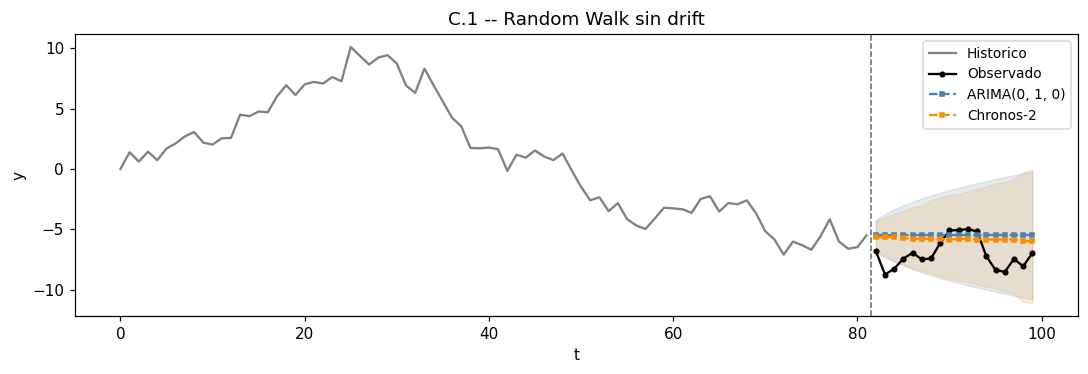

In [75]:
try:
    # C.1 -- RW sin drift
    cl  = ARIMAModel((0, 1, 0))
    dgp = RandomWalk(seed=SEED)
    verify_dgp("C.1 -- RW sin drift", dgp, {"drift": 0.0, "sigma": 1.0}, cl, CHECKS_RW)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {"drift": 0.0, "sigma": 1.0}, exp_id="C.1")
    log("\n" + "="*60 + "\nC.1 -- RW sin drift\n" + "="*60)
    build_grid_table(res, classical_name=cl.name)
    plot_simulation_v3(dgp, [cl, chronos], {"drift": 0.0, "sigma": 1.0}, title="C.1 -- Random Walk sin drift")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:09:06  ────────────────────────────────────────────────────────────
19:09:06  VERIFICACION DGP: C.2 -- RW drift leve (delta=0.05)
19:09:06  ────────────────────────────────────────────────────────────
19:09:06    [PASS] No estacionariedad: ADF p=0.5724 (se espera >0.10)
19:09:06    [FAIL] Varianza crece con t: var(primera cuarta)=15.6784, var(segunda mitad)=18.5427
19:09:06    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [26.1293 26.1293 26.1293]
19:09:06    -> 1 FALLO(S)
19:09:06  Exp C.2: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:09:06    T=50 H=6, R=500: cargando exp_C_2_T50_R500.csv
19:09:06    T=100 H=18, R=500: cargando exp_C_2_T100_R500.csv
19:09:06    T=200 H=24, R=500: cargando exp_C_2_T200_R500.csv
19:09:06  
C.2 -- RW drift leve (delta=0.05)


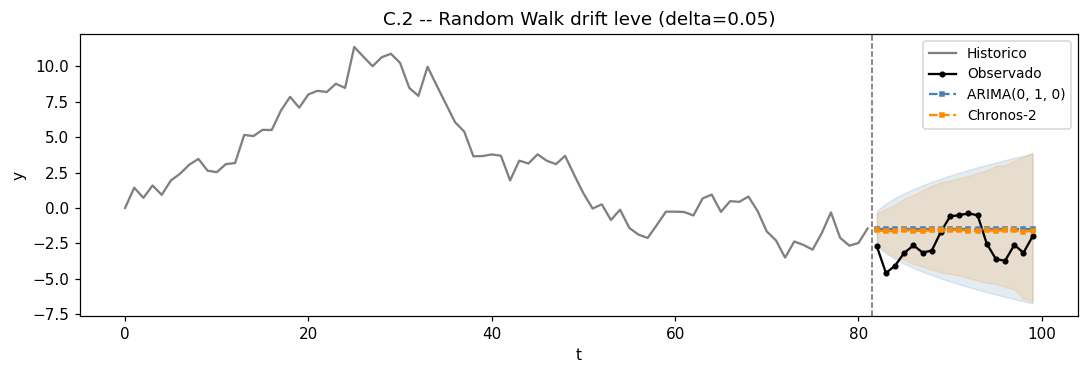

In [76]:
try:
    # C.2 -- RW drift leve (delta=0.05)
    cl  = ARIMAModel((0, 1, 0))
    dgp = RandomWalk(seed=SEED)
    verify_dgp("C.2 -- RW drift leve (delta=0.05)", dgp, {"drift": 0.05, "sigma": 1.0}, cl, CHECKS_RW)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {"drift": 0.05, "sigma": 1.0}, exp_id="C.2")
    log("\n" + "="*60 + "\nC.2 -- RW drift leve (delta=0.05)\n" + "="*60)
    build_grid_table(res, classical_name=cl.name)
    plot_simulation_v3(dgp, [cl, chronos], {"drift": 0.05, "sigma": 1.0}, title="C.2 -- Random Walk drift leve (delta=0.05)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:09:07  ────────────────────────────────────────────────────────────
19:09:07  VERIFICACION DGP: C.3 -- RW drift fuerte (delta=0.20)
19:09:07  ────────────────────────────────────────────────────────────
19:09:07    [PASS] No estacionariedad: ADF p=0.8801 (se espera >0.10)
19:09:07    [PASS] Varianza crece con t: var(primera cuarta)=190.6251, var(segunda mitad)=457.6102
19:09:07    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [145.9793 145.9793 145.9793]
19:09:07    -> TODAS LAS VERIFICACIONES PASARON
19:09:07  Exp C.3: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:09:07    T=50 H=6, R=500: cargando exp_C_3_T50_R500.csv
19:09:07    T=100 H=18, R=500: cargando exp_C_3_T100_R500.csv
19:09:07    T=200 H=24, R=500: cargando exp_C_3_T200_R500.csv
19:09:07  
C.3 -- RW drift fuerte (delta=0.20)


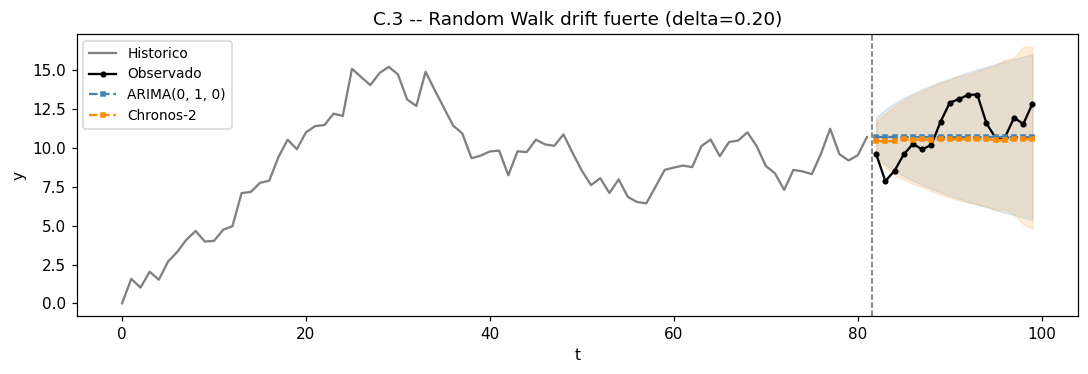

In [77]:
try:
    # C.3 -- RW drift fuerte (delta=0.20)
    cl  = ARIMAModel((0, 1, 0))
    dgp = RandomWalk(seed=SEED)
    verify_dgp("C.3 -- RW drift fuerte (delta=0.20)", dgp, {"drift": 0.20, "sigma": 1.0}, cl, CHECKS_RW)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {"drift": 0.20, "sigma": 1.0}, exp_id="C.3")
    log("\n" + "="*60 + "\nC.3 -- RW drift fuerte (delta=0.20)\n" + "="*60)
    build_grid_table(res, classical_name=cl.name)
    plot_simulation_v3(dgp, [cl, chronos], {"drift": 0.20, "sigma": 1.0}, title="C.3 -- Random Walk drift fuerte (delta=0.20)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA C.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

---
## Bloque D — Volatilidad condicional: ARCH/GARCH (4 experimentos)

DGP: AR(1) en la media + proceso de varianza condicional  
Modelo clasico: AR+ARCH o AR+GARCH correctamente especificado

19:09:09  ────────────────────────────────────────────────────────────
19:09:09  VERIFICACION DGP: D.1 -- AR(1)-ARCH(1) leve (alpha=0.10)
19:09:09  ────────────────────────────────────────────────────────────
19:09:09    [PASS] Estacionariedad media: ADF p=0.0000 (umbral 0.05)
19:09:09    [PASS] Efectos ARCH (LB y^2): LB(10) sobre y^2: p=0.0000 (se espera <0.05)
19:09:09    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [-0.346  -0.2006 -0.127 ]
19:09:09    -> TODAS LAS VERIFICACIONES PASARON
19:09:09  Exp D.1: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:09:09    T=50 H=6, R=500: cargando exp_D_1_T50_R500.csv
19:09:09    T=100 H=18, R=500: cargando exp_D_1_T100_R500.csv
19:09:09    T=200 H=24, R=500: cargando exp_D_1_T200_R500.csv
19:09:09  
D.1 -- AR(1)-ARCH(1) leve


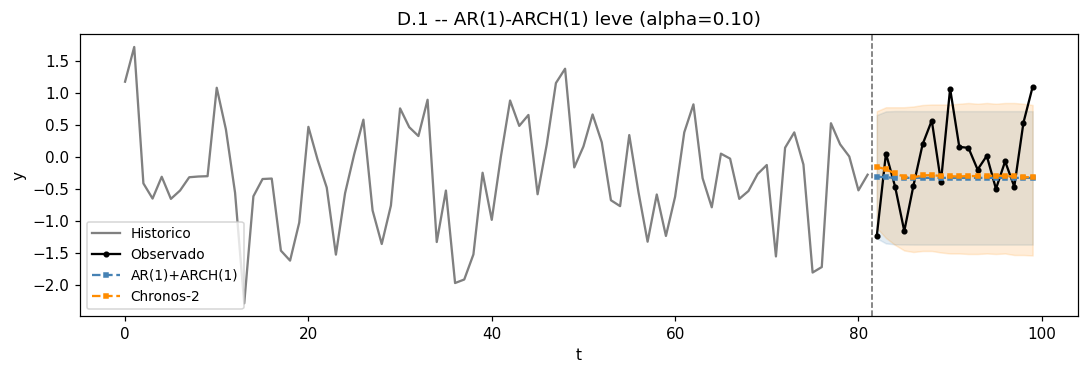

In [78]:
try:
    # D.1 -- AR(1)-ARCH(1) leve  (alpha=0.10)
    cl  = ARARCHModel(ar_lags=1, p=1)
    dgp = AR1ARCH(seed=SEED)
    verify_dgp("D.1 -- AR(1)-ARCH(1) leve (alpha=0.10)", dgp, {"phi": 0.5, "omega": 0.5, "alpha": 0.10}, cl, CHECKS_ARCH)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos],
                  {"phi": 0.5, "omega": 0.5, "alpha": 0.10}, exp_id="D.1")
    log("\n" + "="*60 + "\nD.1 -- AR(1)-ARCH(1) leve\n" + "="*60)
    build_grid_table(res, classical_name=cl.name)
    plot_simulation_v3(dgp, [cl, chronos], {"phi": 0.5, "omega": 0.5, "alpha": 0.10}, title="D.1 -- AR(1)-ARCH(1) leve (alpha=0.10)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA D.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:09:10  ────────────────────────────────────────────────────────────
19:09:10  VERIFICACION DGP: D.2 -- AR(1)-ARCH(1) fuerte (alpha=0.50)
19:09:10  ────────────────────────────────────────────────────────────
19:09:10    [PASS] Estacionariedad media: ADF p=0.0000 (umbral 0.05)
19:09:10    [PASS] Efectos ARCH (LB y^2): LB(10) sobre y^2: p=0.0000 (se espera <0.05)
19:09:10    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [-0.3091 -0.2068 -0.1544]
19:09:10    -> TODAS LAS VERIFICACIONES PASARON
19:09:10  Exp D.2: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:09:10    T=50 H=6, R=500: cargando exp_D_2_T50_R500.csv
19:09:10    T=100 H=18, R=500: cargando exp_D_2_T100_R500.csv
19:09:10    T=200 H=24, R=500: cargando exp_D_2_T200_R500.csv
19:09:10  
D.2 -- AR(1)-ARCH(1) fuerte


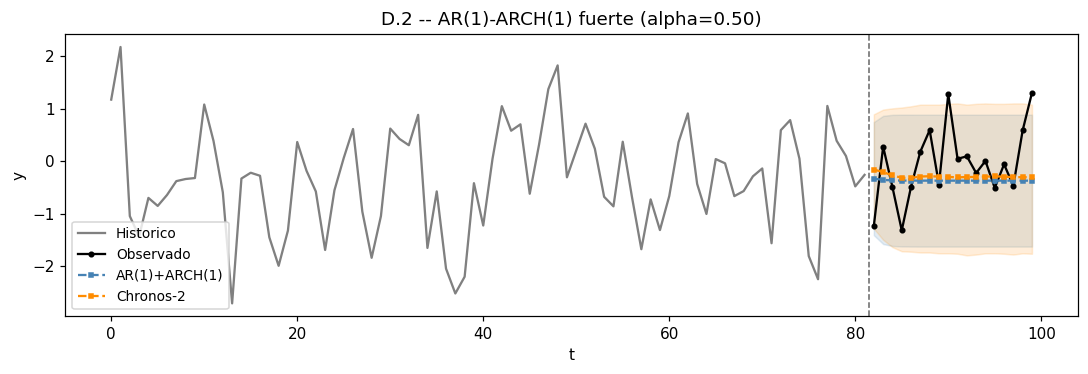

In [79]:
try:
    # D.2 -- AR(1)-ARCH(1) fuerte  (alpha=0.50)
    cl  = ARARCHModel(ar_lags=1, p=1)
    dgp = AR1ARCH(seed=SEED)
    verify_dgp("D.2 -- AR(1)-ARCH(1) fuerte (alpha=0.50)", dgp, {"phi": 0.5, "omega": 0.5, "alpha": 0.50}, cl, CHECKS_ARCH)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos],
                  {"phi": 0.5, "omega": 0.5, "alpha": 0.50}, exp_id="D.2")
    log("\n" + "="*60 + "\nD.2 -- AR(1)-ARCH(1) fuerte\n" + "="*60)
    build_grid_table(res, classical_name=cl.name)
    plot_simulation_v3(dgp, [cl, chronos], {"phi": 0.5, "omega": 0.5, "alpha": 0.50}, title="D.2 -- AR(1)-ARCH(1) fuerte (alpha=0.50)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA D.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:09:11  ────────────────────────────────────────────────────────────
19:09:11  VERIFICACION DGP: D.3 -- AR(1)-GARCH(1,1) baja persistencia
19:09:11  ────────────────────────────────────────────────────────────
19:09:11    [PASS] Estacionariedad media: ADF p=0.0000 (umbral 0.05)
19:09:11    [PASS] Efectos ARCH (LB y^2): LB(10) sobre y^2: p=0.0000 (se espera <0.05)
19:09:11    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [-0.4536 -0.2645 -0.1686]
19:09:11    -> TODAS LAS VERIFICACIONES PASARON
19:09:11  Exp D.3: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:09:11    T=50 H=6, R=500: cargando exp_D_3_T50_R500.csv
19:09:11    T=100 H=18, R=500: cargando exp_D_3_T100_R500.csv
19:09:11    T=200 H=24, R=500: cargando exp_D_3_T200_R500.csv
19:09:11  
D.3 -- AR(1)-GARCH(1,1) baja persistencia


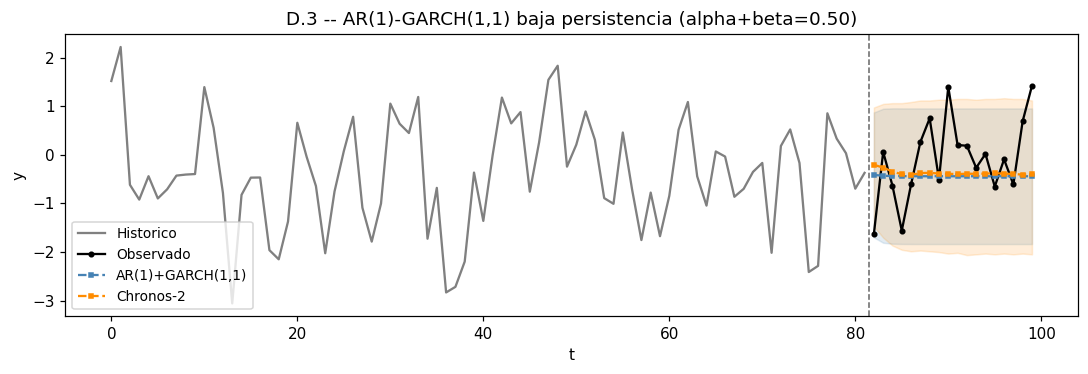

In [80]:
try:
    # D.3 -- AR(1)-GARCH(1,1) baja persistencia  (alpha+beta=0.50)
    cl  = ARGARCHModel(ar_lags=1, p=1, q=1)
    dgp = AR1GARCH(seed=SEED)
    verify_dgp("D.3 -- AR(1)-GARCH(1,1) baja persistencia", dgp, {"phi": 0.5, "omega": 0.5, "alpha": 0.10, "beta": 0.40}, cl, CHECKS_ARCH)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos],
                  {"phi": 0.5, "omega": 0.5, "alpha": 0.10, "beta": 0.40}, exp_id="D.3")
    log("\n" + "="*60 + "\nD.3 -- AR(1)-GARCH(1,1) baja persistencia\n" + "="*60)
    build_grid_table(res, classical_name=cl.name)
    plot_simulation_v3(dgp, [cl, chronos], {"phi": 0.5, "omega": 0.5, "alpha": 0.10, "beta": 0.40}, title="D.3 -- AR(1)-GARCH(1,1) baja persistencia (alpha+beta=0.50)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA D.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:09:12  ────────────────────────────────────────────────────────────
19:09:12  VERIFICACION DGP: D.4 -- AR(1)-GARCH(1,1) alta persistencia
19:09:12  ────────────────────────────────────────────────────────────
19:09:12    [PASS] Estacionariedad media: ADF p=0.0000 (umbral 0.05)
19:09:12    [PASS] Efectos ARCH (LB y^2): LB(10) sobre y^2: p=0.0000 (se espera <0.05)
19:09:12    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [-0.6346 -0.371  -0.2362]
19:09:12    -> TODAS LAS VERIFICACIONES PASARON
19:09:12  Exp D.4: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:09:12    T=50 H=6, R=500: cargando exp_D_4_T50_R500.csv
19:09:12    T=100 H=18, R=500: cargando exp_D_4_T100_R500.csv
19:09:12    T=200 H=24, R=500: cargando exp_D_4_T200_R500.csv
19:09:12  
D.4 -- AR(1)-GARCH(1,1) alta persistencia


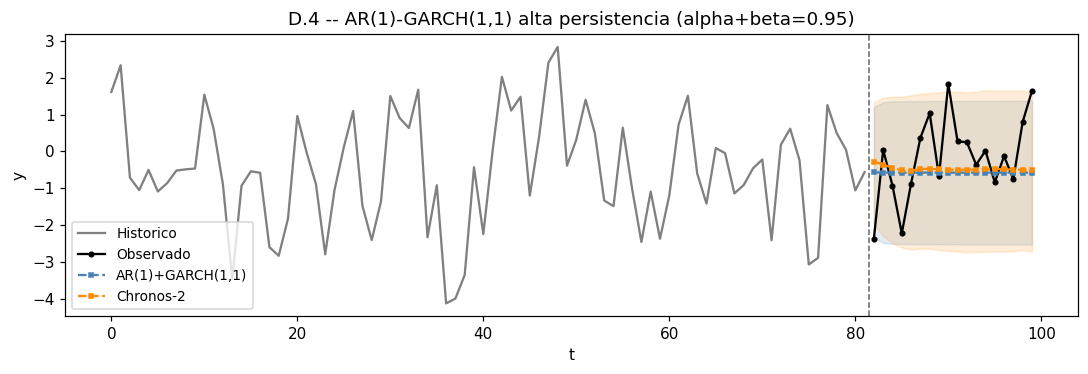

In [81]:
try:
    # D.4 -- AR(1)-GARCH(1,1) alta persistencia  (alpha+beta=0.95)
    cl  = ARGARCHModel(ar_lags=1, p=1, q=1)
    dgp = AR1GARCH(seed=SEED)
    verify_dgp("D.4 -- AR(1)-GARCH(1,1) alta persistencia", dgp, {"phi": 0.5, "omega": 0.1, "alpha": 0.10, "beta": 0.85}, cl, CHECKS_ARCH)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos],
                  {"phi": 0.5, "omega": 0.1, "alpha": 0.10, "beta": 0.85}, exp_id="D.4")
    log("\n" + "="*60 + "\nD.4 -- AR(1)-GARCH(1,1) alta persistencia\n" + "="*60)
    build_grid_table(res, classical_name=cl.name)
    plot_simulation_v3(dgp, [cl, chronos], {"phi": 0.5, "omega": 0.1, "alpha": 0.10, "beta": 0.85}, title="D.4 -- AR(1)-GARCH(1,1) alta persistencia (alpha+beta=0.95)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA D.4 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

---
## Bloque E — ETS y Theta (8 experimentos)

DGPs de espacio de estados: nivel local, tendencia, estacionalidad  
Modelos clasicos: ETS(A,T,S) y Theta

19:09:13  ────────────────────────────────────────────────────────────
19:09:13  VERIFICACION DGP: E.1 -- Local Level ETS(A,N,N)
19:09:13  ────────────────────────────────────────────────────────────
19:09:13    [PASS] No estacionariedad: ADF p=0.1786 (se espera >0.10)
19:09:13    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [-1.1712 -1.1712 -1.1712]
19:09:13    -> TODAS LAS VERIFICACIONES PASARON
19:09:13  Exp E.1: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:09:13    T=50 H=6, R=500: cargando exp_E_1_T50_R500.csv
19:09:13    T=100 H=18, R=500: cargando exp_E_1_T100_R500.csv
19:09:13    T=200 H=24, R=500: cargando exp_E_1_T200_R500.csv
19:09:13  
E.1 -- Local Level ETS(A,N,N)


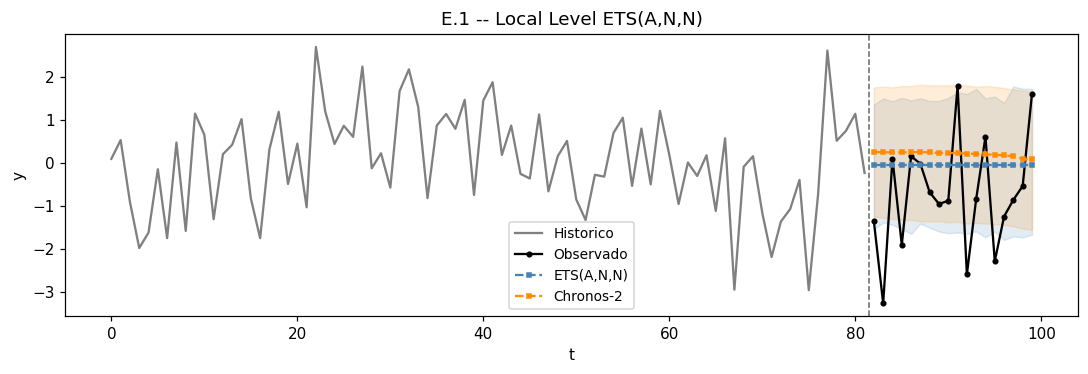

In [82]:
try:
    # E.1 -- Local Level  ETS(A,N,N)
    cl  = ETSModel()
    dgp = LocalLevelDGP(seed=SEED)
    verify_dgp("E.1 -- Local Level ETS(A,N,N)", dgp, {"sigma_eps": 1.0, "sigma_eta": 0.10}, cl, CHECKS_ETS)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos],
                  {"sigma_eps": 1.0, "sigma_eta": 0.10}, exp_id="E.1")
    log("\n" + "="*60 + "\nE.1 -- Local Level ETS(A,N,N)\n" + "="*60)
    build_grid_table(res, classical_name=cl.name)
    plot_simulation_v3(dgp, [cl, chronos], {"sigma_eps": 1.0, "sigma_eta": 0.10}, title="E.1 -- Local Level ETS(A,N,N)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA E.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:09:14  ────────────────────────────────────────────────────────────
19:09:14  VERIFICACION DGP: E.2 -- LLT leve ETS(A,A,N)
19:09:14  ────────────────────────────────────────────────────────────
19:09:14    [PASS] No estacionariedad: ADF p=1.0000 (se espera >0.10)
19:09:15    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [-236.033  -236.9706 -237.9083]
19:09:15    -> TODAS LAS VERIFICACIONES PASARON
19:09:15  Exp E.2: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:09:15    T=50 H=6, R=500: cargando exp_E_2_T50_R500.csv
19:09:15    T=100 H=18, R=500: cargando exp_E_2_T100_R500.csv
19:09:15    T=200 H=24, R=500: cargando exp_E_2_T200_R500.csv
19:09:15  
E.2 -- LLT leve ETS(A,A,N)


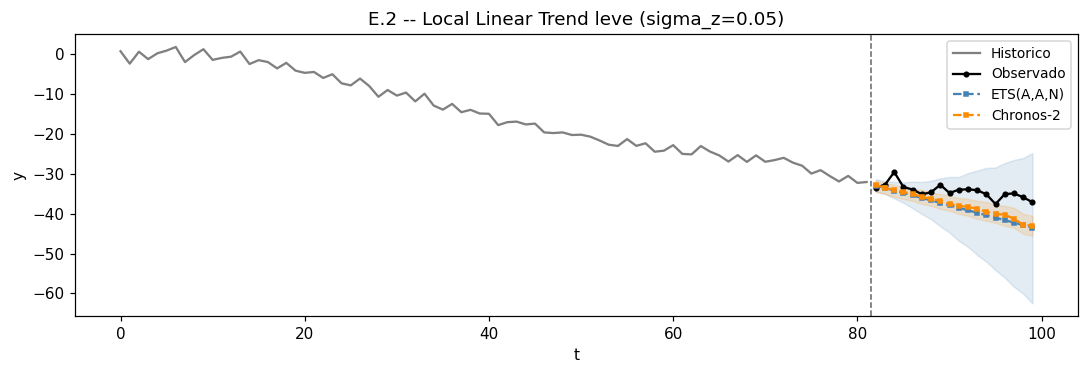

In [83]:
try:
    # E.2 -- Local Linear Trend leve  ETS(A,A,N)  sigma_z=0.05
    cl  = ETSModel(trend="add")
    dgp = LocalTrendDGP(seed=SEED)
    verify_dgp("E.2 -- LLT leve ETS(A,A,N)", dgp, {"sigma_eps": 1.0, "sigma_eta": 0.1, "sigma_zeta": 0.05, "b0": 0.1}, cl, CHECKS_ETS)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos],
                  {"sigma_eps": 1.0, "sigma_eta": 0.1, "sigma_zeta": 0.05, "b0": 0.1}, exp_id="E.2")
    log("\n" + "="*60 + "\nE.2 -- LLT leve ETS(A,A,N)\n" + "="*60)
    build_grid_table(res, classical_name=cl.name)
    plot_simulation_v3(dgp, [cl, chronos], {"sigma_eps": 1.0, "sigma_eta": 0.1, "sigma_zeta": 0.05, "b0": 0.1}, title="E.2 -- Local Linear Trend leve (sigma_z=0.05)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA E.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:09:15  ────────────────────────────────────────────────────────────
19:09:15  VERIFICACION DGP: E.3 -- LLT fuerte ETS(A,A,N)
19:09:15  ────────────────────────────────────────────────────────────
19:09:15    [PASS] No estacionariedad: ADF p=1.0000 (se espera >0.10)
19:09:16    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [-863.9454 -867.8264 -871.7075]
19:09:16    -> TODAS LAS VERIFICACIONES PASARON
19:09:16  Exp E.3: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:09:16    T=50 H=6, R=500: cargando exp_E_3_T50_R500.csv
19:09:16    T=100 H=18, R=500: cargando exp_E_3_T100_R500.csv
19:09:16    T=200 H=24, R=500: cargando exp_E_3_T200_R500.csv
19:09:16  
E.3 -- LLT fuerte ETS(A,A,N)


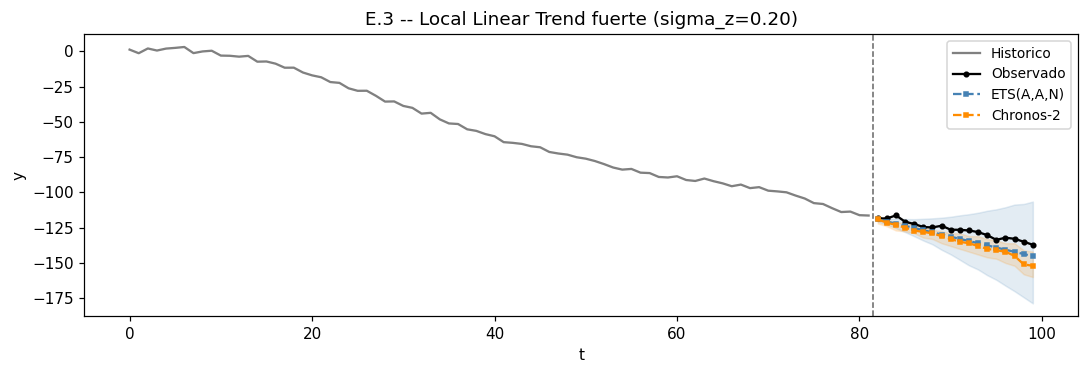

In [84]:
try:
    # E.3 -- Local Linear Trend fuerte  ETS(A,A,N)  sigma_z=0.20
    cl  = ETSModel(trend="add")
    dgp = LocalTrendDGP(seed=SEED)
    verify_dgp("E.3 -- LLT fuerte ETS(A,A,N)", dgp, {"sigma_eps": 1.0, "sigma_eta": 0.2, "sigma_zeta": 0.20, "b0": 0.5}, cl, CHECKS_ETS)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos],
                  {"sigma_eps": 1.0, "sigma_eta": 0.2, "sigma_zeta": 0.20, "b0": 0.5}, exp_id="E.3")
    log("\n" + "="*60 + "\nE.3 -- LLT fuerte ETS(A,A,N)\n" + "="*60)
    build_grid_table(res, classical_name=cl.name)
    plot_simulation_v3(dgp, [cl, chronos], {"sigma_eps": 1.0, "sigma_eta": 0.2, "sigma_zeta": 0.20, "b0": 0.5}, title="E.3 -- Local Linear Trend fuerte (sigma_z=0.20)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA E.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:09:16  ────────────────────────────────────────────────────────────
19:09:16  VERIFICACION DGP: E.4 -- Damped Trend ETS(A,Ad,N)
19:09:16  ────────────────────────────────────────────────────────────
19:09:16    [PASS] No estacionariedad: ADF p=0.9431 (se espera >0.10)
19:09:17    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [-19.2475 -19.3843 -19.4963]
19:09:17    -> TODAS LAS VERIFICACIONES PASARON
19:09:17  Exp E.4: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:09:17    T=50 H=6, R=500: cargando exp_E_4_T50_R500.csv
19:09:17    T=100 H=18, R=500: cargando exp_E_4_T100_R500.csv
19:09:17    T=200 H=24, R=500: cargando exp_E_4_T200_R500.csv
19:09:17  
E.4 -- Damped Trend ETS(A,Ad,N)


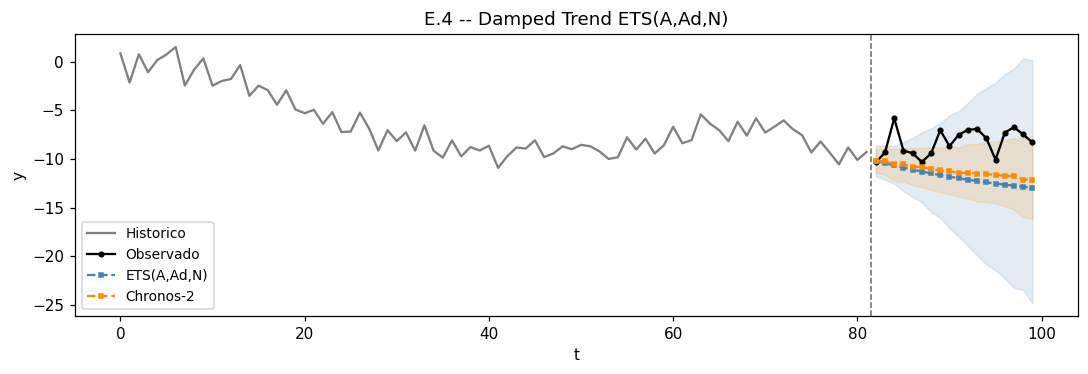

In [85]:
try:
    # E.4 -- Damped Trend  ETS(A,Ad,N)  phi_d=0.90
    cl  = ETSModel(trend="add", damped_trend=True)
    dgp = DampedTrendDGP(seed=SEED)
    verify_dgp("E.4 -- Damped Trend ETS(A,Ad,N)", dgp, {"phi": 0.9, "sigma_eps": 1.0, "sigma_eta": 0.2, "sigma_zeta": 0.1}, cl, CHECKS_ETS)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos],
                  {"phi": 0.9, "sigma_eps": 1.0, "sigma_eta": 0.2, "sigma_zeta": 0.1}, exp_id="E.4")
    log("\n" + "="*60 + "\nE.4 -- Damped Trend ETS(A,Ad,N)\n" + "="*60)
    build_grid_table(res, classical_name=cl.name)
    plot_simulation_v3(dgp, [cl, chronos], {"phi": 0.9, "sigma_eps": 1.0, "sigma_eta": 0.2, "sigma_zeta": 0.1}, title="E.4 -- Damped Trend ETS(A,Ad,N)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA E.4 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:09:17  ────────────────────────────────────────────────────────────
19:09:17  VERIFICACION DGP: E.5 -- Seasonal Aditiva s=12
19:09:17  ────────────────────────────────────────────────────────────
19:09:17    [PASS] No estacionariedad: ADF p=0.4170 (se espera >0.10)
19:09:17    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [2.6162 2.6867 2.947 ]
19:09:17    -> TODAS LAS VERIFICACIONES PASARON
19:09:18  Exp E.5: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:09:18    T=50 H=6, R=500: cargando exp_E_5_T50_R500.csv
19:09:18    T=100 H=18, R=500: cargando exp_E_5_T100_R500.csv
19:09:18    T=200 H=24, R=500: cargando exp_E_5_T200_R500.csv
19:09:18  
E.5 -- Seasonal Aditiva s=12 ETS(A,N,A)


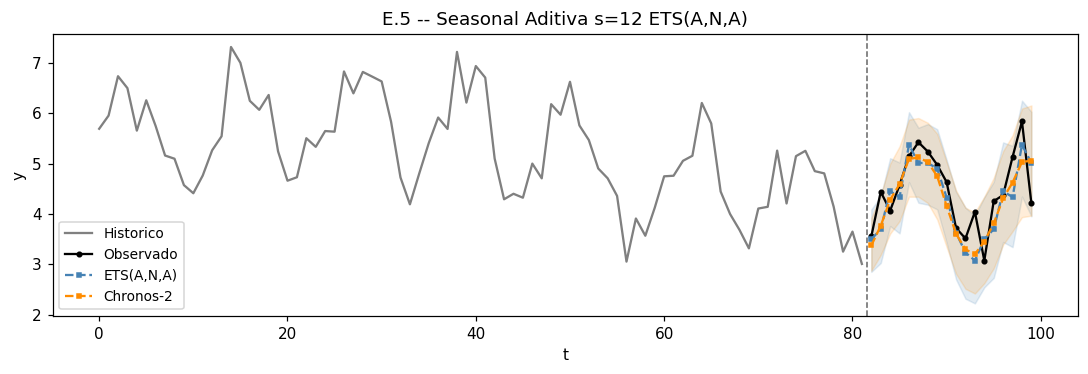

In [86]:
try:
    # E.5 -- Seasonal Aditiva s=12  ETS(A,N,A)
    cl  = ETSModel(seasonal="add", seasonal_periods=12)
    dgp = LocalLevelSeasonalDGP(seed=SEED)
    verify_dgp("E.5 -- Seasonal Aditiva s=12", dgp,
               {"s": 12, "sigma_eps": 0.5, "sigma_eta": 0.1, "sigma_zeta": 0.0, "sigma_omega": 0.05, "b0": 0.0},
               cl, CHECKS_ETS)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos],
                  {"s": 12, "sigma_eps": 0.5, "sigma_eta": 0.1,
                   "sigma_zeta": 0.0, "sigma_omega": 0.05, "b0": 0.0},
                  exp_id="E.5")
    log("\n" + "="*60 + "\nE.5 -- Seasonal Aditiva s=12 ETS(A,N,A)\n" + "="*60)
    build_grid_table(res, classical_name=cl.name)
    plot_simulation_v3(dgp, [cl, chronos], {"s": 12, "sigma_eps": 0.5, "sigma_eta": 0.1, "sigma_zeta": 0.0, "sigma_omega": 0.05, "b0": 0.0}, title="E.5 -- Seasonal Aditiva s=12 ETS(A,N,A)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA E.5 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:09:18  ────────────────────────────────────────────────────────────
19:09:18  VERIFICACION DGP: E.6 -- Trend+Seasonal s=12 ETS(A,A,A)
19:09:18  ────────────────────────────────────────────────────────────
19:09:19    [PASS] No estacionariedad: ADF p=1.0000 (se espera >0.10)
19:09:19    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [-231.6285 -232.4984 -233.1733]
19:09:19    -> TODAS LAS VERIFICACIONES PASARON
19:09:19  Exp E.6: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:09:19    T=50 H=6, R=500: cargando exp_E_6_T50_R500.csv
19:09:19    T=100 H=18, R=500: cargando exp_E_6_T100_R500.csv
19:09:19    T=200 H=24, R=500: cargando exp_E_6_T200_R500.csv
19:09:19  
E.6 -- Trend+Seasonal s=12 ETS(A,A,A)


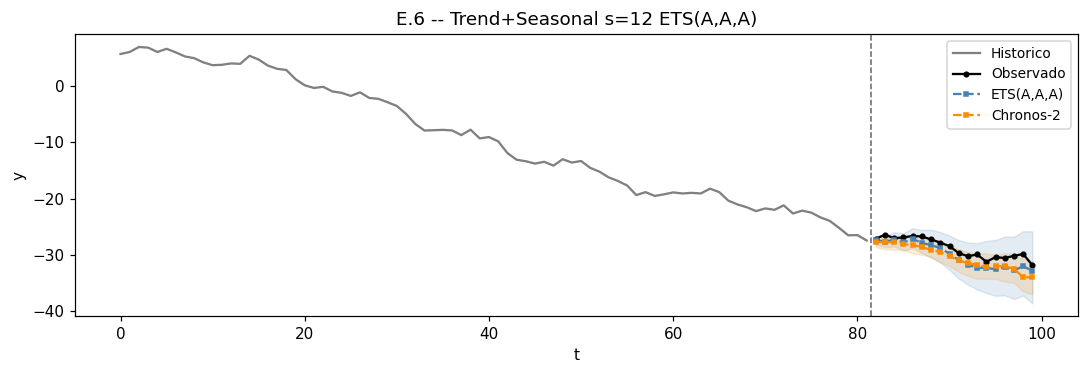

In [87]:
try:
    # E.6 -- Trend + Seasonal s=12  ETS(A,A,A)
    cl  = ETSModel(trend="add", seasonal="add", seasonal_periods=12)
    dgp = LocalLevelSeasonalDGP(seed=SEED)
    verify_dgp("E.6 -- Trend+Seasonal s=12 ETS(A,A,A)", dgp,
               {"s": 12, "sigma_eps": 0.5, "sigma_eta": 0.1, "sigma_zeta": 0.05, "sigma_omega": 0.05, "b0": 0.1},
               cl, CHECKS_ETS)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos],
                  {"s": 12, "sigma_eps": 0.5, "sigma_eta": 0.1,
                   "sigma_zeta": 0.05, "sigma_omega": 0.05, "b0": 0.1},
                  exp_id="E.6")
    log("\n" + "="*60 + "\nE.6 -- Trend+Seasonal s=12 ETS(A,A,A)\n" + "="*60)
    build_grid_table(res, classical_name=cl.name)
    plot_simulation_v3(dgp, [cl, chronos], {"s": 12, "sigma_eps": 0.5, "sigma_eta": 0.1, "sigma_zeta": 0.05, "sigma_omega": 0.05, "b0": 0.1}, title="E.6 -- Trend+Seasonal s=12 ETS(A,A,A)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA E.6 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:09:20  ────────────────────────────────────────────────────────────
19:09:20  VERIFICACION DGP: E.7 -- Theta leve
19:09:20  ────────────────────────────────────────────────────────────
19:09:20    [PASS] Ajuste Theta: OK, primeros valores: [16.7302 16.7404 16.7507]
19:09:20    -> TODAS LAS VERIFICACIONES PASARON
19:09:20  Exp E.7: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:09:20    T=50 H=6, R=500: cargando exp_E_7_T50_R500.csv
19:09:20    T=100 H=18, R=500: cargando exp_E_7_T100_R500.csv
19:09:20    T=200 H=24, R=500: cargando exp_E_7_T200_R500.csv
19:09:20  
E.7 -- Theta leve


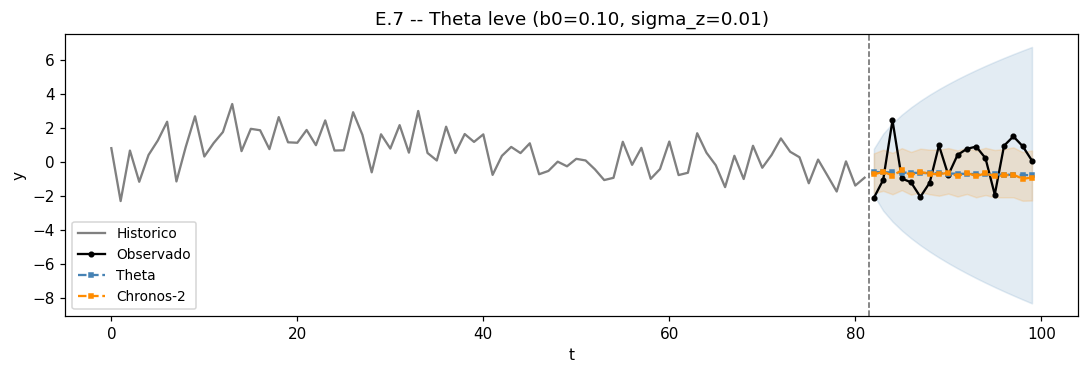

In [88]:
try:
    # E.7 -- Theta leve  (b0=0.10, sigma_z=0.01)
    cl  = ThetaModel()
    dgp = LocalTrendDGP(seed=SEED)
    verify_dgp("E.7 -- Theta leve", dgp, {"sigma_eps": 1.0, "sigma_eta": 0.1, "sigma_zeta": 0.01, "b0": 0.10}, cl, CHECKS_THETA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos],
                  {"sigma_eps": 1.0, "sigma_eta": 0.1, "sigma_zeta": 0.01, "b0": 0.10}, exp_id="E.7")
    log("\n" + "="*60 + "\nE.7 -- Theta leve\n" + "="*60)
    build_grid_table(res, classical_name=cl.name)
    plot_simulation_v3(dgp, [cl, chronos], {"sigma_eps": 1.0, "sigma_eta": 0.1, "sigma_zeta": 0.01, "b0": 0.10}, title="E.7 -- Theta leve (b0=0.10, sigma_z=0.01)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA E.7 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:09:21  ────────────────────────────────────────────────────────────
19:09:21  VERIFICACION DGP: E.8 -- Theta fuerte
19:09:21  ────────────────────────────────────────────────────────────
19:09:21    [PASS] Ajuste Theta: OK, primeros valores: [-231.0248 -231.1742 -231.3235]
19:09:21    -> TODAS LAS VERIFICACIONES PASARON
19:09:21  Exp E.8: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:09:21    T=50 H=6, R=500: cargando exp_E_8_T50_R500.csv
19:09:21    T=100 H=18, R=500: cargando exp_E_8_T100_R500.csv
19:09:21    T=200 H=24, R=500: cargando exp_E_8_T200_R500.csv
19:09:22  
E.8 -- Theta fuerte


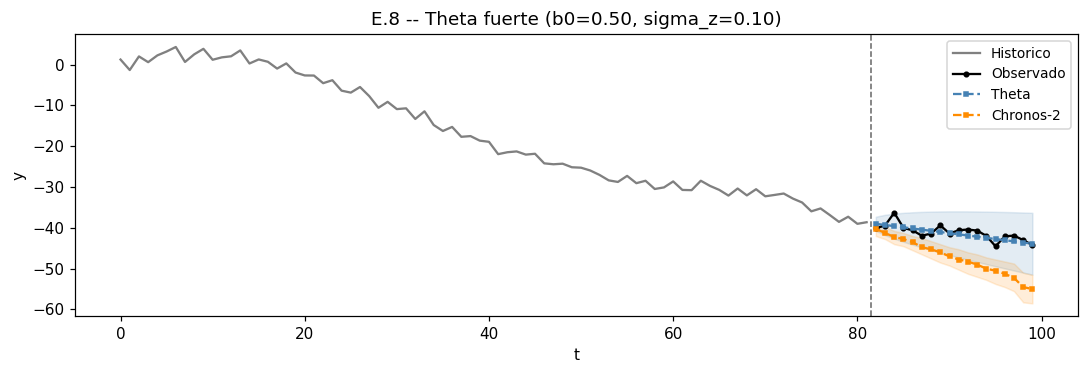

In [89]:
try:
    # E.8 -- Theta fuerte  (b0=0.50, sigma_z=0.10)
    cl  = ThetaModel()
    dgp = LocalTrendDGP(seed=SEED)
    verify_dgp("E.8 -- Theta fuerte", dgp, {"sigma_eps": 1.0, "sigma_eta": 0.2, "sigma_zeta": 0.10, "b0": 0.50}, cl, CHECKS_THETA)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos],
                  {"sigma_eps": 1.0, "sigma_eta": 0.2, "sigma_zeta": 0.10, "b0": 0.50}, exp_id="E.8")
    log("\n" + "="*60 + "\nE.8 -- Theta fuerte\n" + "="*60)
    build_grid_table(res, classical_name=cl.name)
    plot_simulation_v3(dgp, [cl, chronos], {"sigma_eps": 1.0, "sigma_eta": 0.2, "sigma_zeta": 0.10, "b0": 0.50}, title="E.8 -- Theta fuerte (b0=0.50, sigma_z=0.10)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA E.8 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

---
## Bloque F — SARIMA (6 experimentos)

DGP: SAR(1)(1)_s estacionario * (1-L)(1-L^s) integrado  
Periodos estacionales: s=4 (trimestral) * s=12 (mensual)

19:09:22  ────────────────────────────────────────────────────────────
19:09:22  VERIFICACION DGP: F.1 -- SAR(1)(1)_4 baja persist.
19:09:22  ────────────────────────────────────────────────────────────
19:09:22    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:09:22    [PASS] ACF estacional signif.: |ACF[4]|=0.3160, umbral=2/sqrt(T)=0.0632
19:09:22    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [ 0.1563 -0.2693  0.2867]
19:09:22    -> TODAS LAS VERIFICACIONES PASARON
19:09:23  Exp F.1: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:09:23    T=50 H=6, R=500: cargando exp_F_1_T50_R500.csv
19:09:23    T=100 H=18, R=500: cargando exp_F_1_T100_R500.csv
19:09:23    T=200 H=24, R=500: cargando exp_F_1_T200_R500.csv
19:09:23  
F.1 -- SAR(1)(1)_4 baja persist.


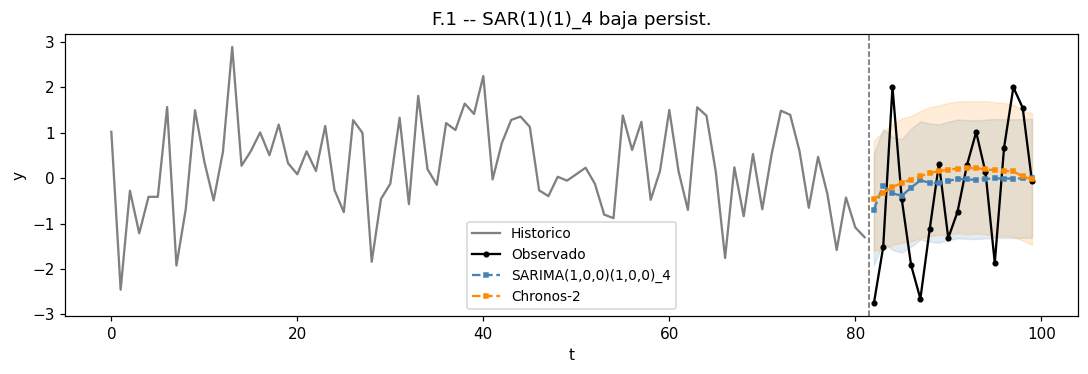

In [90]:
try:
    # F.1 -- SAR(1)(1)_4 baja persist.
    cl  = SARIMAModel(order=(1, 0, 0), seasonal_order=(1, 0, 0, 4))
    dgp = SeasonalDGP(seed=SEED)
    verify_dgp("F.1 -- SAR(1)(1)_4 baja persist.", dgp, {"phi": 0.3, "Phi": 0.3, "s": 4, "sigma": 1.0, "integrated": False}, cl, CHECKS_SAR)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos],
                  {"phi": 0.3, "Phi": 0.3, "s": 4, "sigma": 1.0, "integrated": False},
                  exp_id="F.1")
    log("\n" + "="*60 + "\nF.1 -- SAR(1)(1)_4 baja persist.\n" + "="*60)
    build_grid_table(res, classical_name=cl.name)
    plot_simulation_v3(dgp, [cl, chronos], {"phi": 0.3, "Phi": 0.3, "s": 4, "sigma": 1.0, "integrated": False}, title="F.1 -- SAR(1)(1)_4 baja persist.")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA F.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:09:23  ────────────────────────────────────────────────────────────
19:09:23  VERIFICACION DGP: F.2 -- SAR(1)(1)_4 alta persist.
19:09:23  ────────────────────────────────────────────────────────────
19:09:24    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:09:24    [PASS] ACF estacional signif.: |ACF[4]|=0.8878, umbral=2/sqrt(T)=0.0632
19:09:24    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [4.991  4.1628 4.6669]
19:09:24    -> TODAS LAS VERIFICACIONES PASARON
19:09:24  Exp F.2: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:09:24    T=50 H=6, R=500: cargando exp_F_2_T50_R500.csv
19:09:24    T=100 H=18, R=500: cargando exp_F_2_T100_R500.csv
19:09:24    T=200 H=24, R=500: cargando exp_F_2_T200_R500.csv
19:09:24  
F.2 -- SAR(1)(1)_4 alta persist.


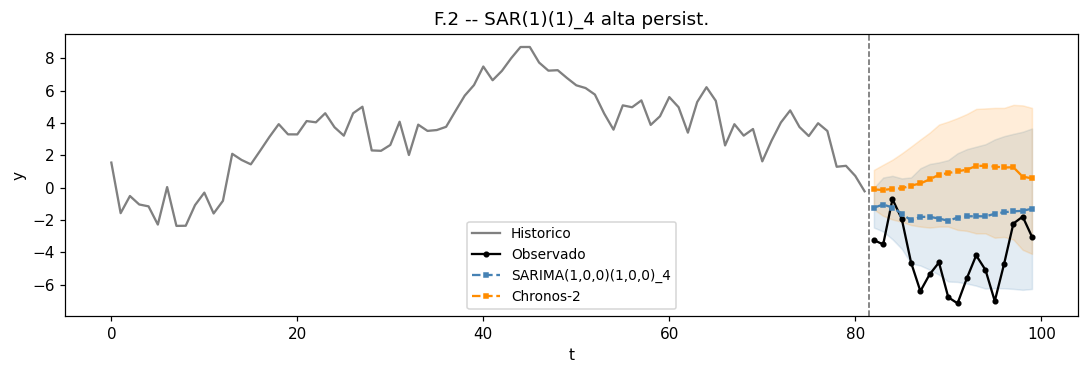

In [91]:
try:
    # F.2 -- SAR(1)(1)_4 alta persist.
    cl  = SARIMAModel(order=(1, 0, 0), seasonal_order=(1, 0, 0, 4))
    dgp = SeasonalDGP(seed=SEED)
    verify_dgp("F.2 -- SAR(1)(1)_4 alta persist.", dgp, {"phi": 0.9, "Phi": 0.6, "s": 4, "sigma": 1.0, "integrated": False}, cl, CHECKS_SAR)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos],
                  {"phi": 0.9, "Phi": 0.6, "s": 4, "sigma": 1.0, "integrated": False},
                  exp_id="F.2")
    log("\n" + "="*60 + "\nF.2 -- SAR(1)(1)_4 alta persist.\n" + "="*60)
    build_grid_table(res, classical_name=cl.name)
    plot_simulation_v3(dgp, [cl, chronos], {"phi": 0.9, "Phi": 0.6, "s": 4, "sigma": 1.0, "integrated": False}, title="F.2 -- SAR(1)(1)_4 alta persist.")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA F.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:09:25  ────────────────────────────────────────────────────────────
19:09:25  VERIFICACION DGP: F.3 -- SAR(1)(1)_12 baja persist.
19:09:25  ────────────────────────────────────────────────────────────
19:09:25    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:09:25    [PASS] ACF estacional signif.: |ACF[12]|=0.2559, umbral=2/sqrt(T)=0.0632
19:09:25    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [0.5473 0.6992 0.453 ]
19:09:25    -> TODAS LAS VERIFICACIONES PASARON
19:09:25  Exp F.3: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:09:25    T=50 H=6, R=500: cargando exp_F_3_T50_R500.csv
19:09:25    T=100 H=18, R=500: cargando exp_F_3_T100_R500.csv
19:09:25    T=200 H=24, R=500: cargando exp_F_3_T200_R500.csv
19:09:25  
F.3 -- SAR(1)(1)_12 baja persist.


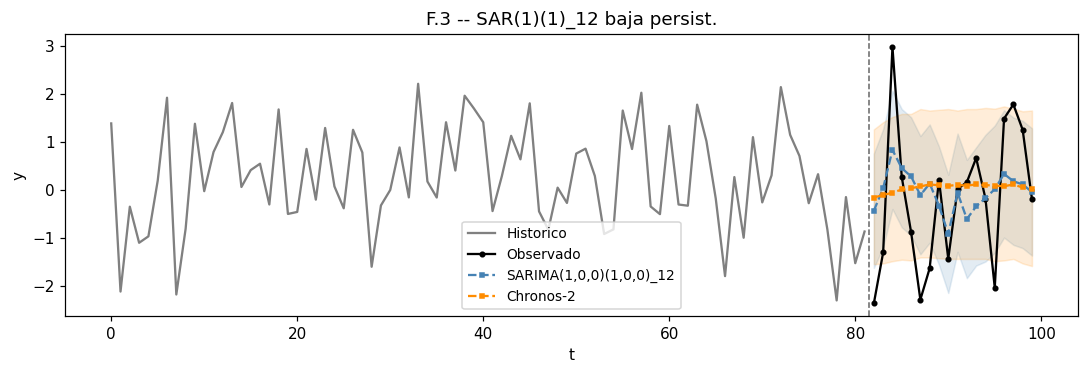

In [92]:
try:
    # F.3 -- SAR(1)(1)_12 baja persist.
    cl  = SARIMAModel(order=(1, 0, 0), seasonal_order=(1, 0, 0, 12))
    dgp = SeasonalDGP(seed=SEED)
    verify_dgp("F.3 -- SAR(1)(1)_12 baja persist.", dgp, {"phi": 0.3, "Phi": 0.3, "s": 12, "sigma": 1.0, "integrated": False}, cl, CHECKS_SAR)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos],
                  {"phi": 0.3, "Phi": 0.3, "s": 12, "sigma": 1.0, "integrated": False},
                  exp_id="F.3")
    log("\n" + "="*60 + "\nF.3 -- SAR(1)(1)_12 baja persist.\n" + "="*60)
    build_grid_table(res, classical_name=cl.name)
    plot_simulation_v3(dgp, [cl, chronos], {"phi": 0.3, "Phi": 0.3, "s": 12, "sigma": 1.0, "integrated": False}, title="F.3 -- SAR(1)(1)_12 baja persist.")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA F.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:09:26  ────────────────────────────────────────────────────────────
19:09:26  VERIFICACION DGP: F.4 -- SAR(1)(1)_12 alta persist.
19:09:26  ────────────────────────────────────────────────────────────
19:09:26    [PASS] Estacionariedad (ADF): ADF p=0.0001 (umbral 0.05)
19:09:26    [PASS] ACF estacional signif.: |ACF[12]|=0.6772, umbral=2/sqrt(T)=0.0632
19:09:26    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [2.9855 3.9181 3.9152]
19:09:26    -> TODAS LAS VERIFICACIONES PASARON
19:09:26  Exp F.4: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:09:26    T=50 H=6, R=500: cargando exp_F_4_T50_R500.csv
19:09:26    T=100 H=18, R=500: cargando exp_F_4_T100_R500.csv
19:09:26    T=200 H=24, R=500: cargando exp_F_4_T200_R500.csv
19:09:26  
F.4 -- SAR(1)(1)_12 alta persist.


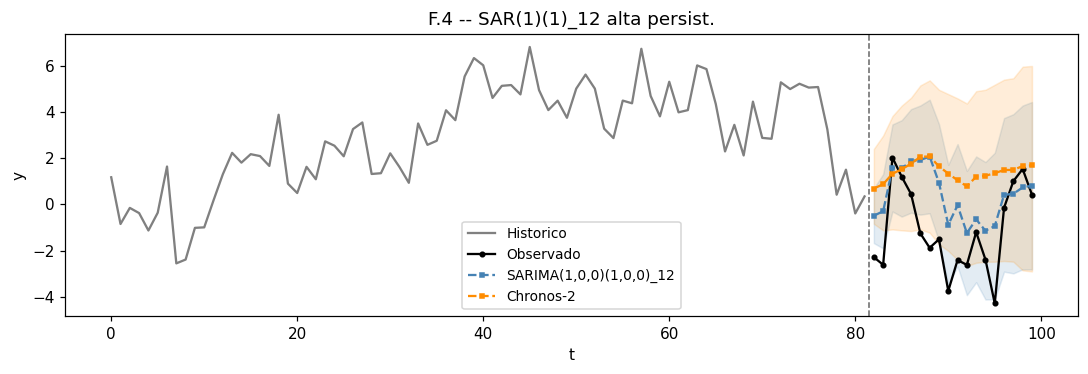

In [93]:
try:
    # F.4 -- SAR(1)(1)_12 alta persist.
    cl  = SARIMAModel(order=(1, 0, 0), seasonal_order=(1, 0, 0, 12))
    dgp = SeasonalDGP(seed=SEED)
    verify_dgp("F.4 -- SAR(1)(1)_12 alta persist.", dgp, {"phi": 0.9, "Phi": 0.6, "s": 12, "sigma": 1.0, "integrated": False}, cl, CHECKS_SAR)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos],
                  {"phi": 0.9, "Phi": 0.6, "s": 12, "sigma": 1.0, "integrated": False},
                  exp_id="F.4")
    log("\n" + "="*60 + "\nF.4 -- SAR(1)(1)_12 alta persist.\n" + "="*60)
    build_grid_table(res, classical_name=cl.name)
    plot_simulation_v3(dgp, [cl, chronos], {"phi": 0.9, "Phi": 0.6, "s": 12, "sigma": 1.0, "integrated": False}, title="F.4 -- SAR(1)(1)_12 alta persist.")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA F.4 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:09:27  ────────────────────────────────────────────────────────────
19:09:27  VERIFICACION DGP: F.5 -- (1-L)(1-L^4) integrado
19:09:27  ────────────────────────────────────────────────────────────
19:09:27    [FAIL] Estacionariedad (ADF): ADF p=0.9901 (umbral 0.05)
19:09:27    [PASS] ACF estacional signif.: |ACF[4]|=0.9754, umbral=2/sqrt(T)=0.0632
19:09:27    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [-420.7615 -446.6789 -442.7751]
19:09:27    -> 1 FALLO(S)
19:09:27  Exp F.5: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:09:27    T=50 H=6, R=500: cargando exp_F_5_T50_R500.csv
19:09:27    T=100 H=18, R=500: cargando exp_F_5_T100_R500.csv
19:09:27    T=200 H=24, R=500: cargando exp_F_5_T200_R500.csv
19:09:27  
F.5 -- (1-L)(1-L^4) integrado


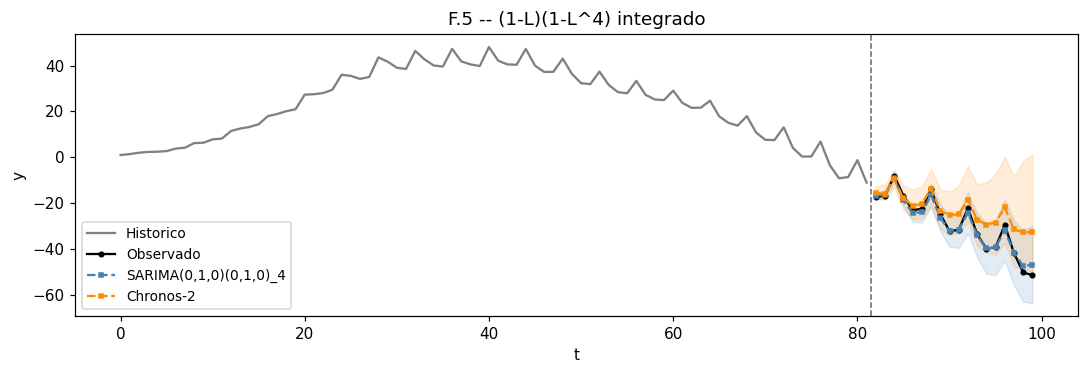

In [94]:
try:
    # F.5 -- (1-L)(1-L^4) integrado
    cl  = SARIMAModel(order=(0, 1, 0), seasonal_order=(0, 1, 0, 4))
    dgp = SeasonalDGP(seed=SEED)
    verify_dgp("F.5 -- (1-L)(1-L^4) integrado", dgp, {"s": 4, "sigma": 1.0, "integrated": True}, cl, CHECKS_SAR)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos],
                  {"s": 4, "sigma": 1.0, "integrated": True},
                  exp_id="F.5")
    log("\n" + "="*60 + "\nF.5 -- (1-L)(1-L^4) integrado\n" + "="*60)
    build_grid_table(res, classical_name=cl.name)
    plot_simulation_v3(dgp, [cl, chronos], {"s": 4, "sigma": 1.0, "integrated": True}, title="F.5 -- (1-L)(1-L^4) integrado")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA F.5 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:09:28  ────────────────────────────────────────────────────────────
19:09:28  VERIFICACION DGP: F.6 -- (1-L)(1-L^12) integrado
19:09:28  ────────────────────────────────────────────────────────────
19:09:28    [FAIL] Estacionariedad (ADF): ADF p=0.4686 (umbral 0.05)
19:09:28    [PASS] ACF estacional signif.: |ACF[12]|=0.9127, umbral=2/sqrt(T)=0.0632
19:09:28    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [71.7855 65.9506 63.0751]
19:09:28    -> 1 FALLO(S)
19:09:28  Exp F.6: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:09:28    T=50 H=6, R=500: cargando exp_F_6_T50_R500.csv
19:09:28    T=100 H=18, R=500: cargando exp_F_6_T100_R500.csv
19:09:28    T=200 H=24, R=500: cargando exp_F_6_T200_R500.csv
19:09:28  
F.6 -- (1-L)(1-L^12) integrado


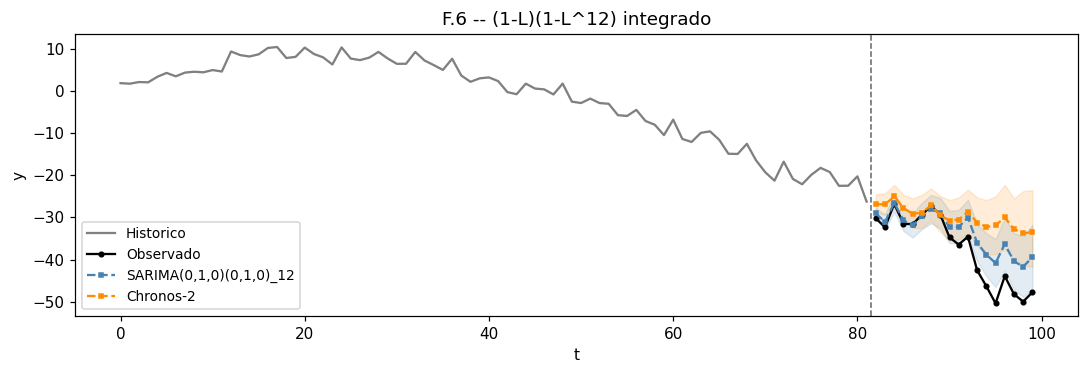

In [95]:
try:
    # F.6 -- (1-L)(1-L^12) integrado
    cl  = SARIMAModel(order=(0, 1, 0), seasonal_order=(0, 1, 0, 12))
    dgp = SeasonalDGP(seed=SEED)
    verify_dgp("F.6 -- (1-L)(1-L^12) integrado", dgp, {"s": 12, "sigma": 1.0, "integrated": True}, cl, CHECKS_SAR)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos],
                  {"s": 12, "sigma": 1.0, "integrated": True},
                  exp_id="F.6")
    log("\n" + "="*60 + "\nF.6 -- (1-L)(1-L^12) integrado\n" + "="*60)
    build_grid_table(res, classical_name=cl.name)
    plot_simulation_v3(dgp, [cl, chronos], {"s": 12, "sigma": 1.0, "integrated": True}, title="F.6 -- (1-L)(1-L^12) integrado")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA F.6 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

---
## Bloque G — No linealidad de umbral: SETAR / LSTAR / ESTAR (4 experimentos)

Benchmark clasico: ARIMA(1,0,0) — lineal misspecificado  
Pregunta: detecta Chronos-2 la no-linealidad que ARIMA no puede capturar?  
- **SETAR**: umbral deterministico y observable  
- **LSTAR**: transicion suave asimetrica (ciclos de negocios)  
- **ESTAR**: transicion suave simetrica (tipos de cambio con bandas)

19:09:29  ────────────────────────────────────────────────────────────
19:09:29  VERIFICACION DGP: G.1 -- SETAR(2;1) baja persistencia
19:09:29  ────────────────────────────────────────────────────────────
19:09:29    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:09:29    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [-0.2602 -0.2683 -0.2686]
19:09:29    -> TODAS LAS VERIFICACIONES PASARON
19:09:29  Exp G.1: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:09:29    T=50 H=6, R=500: cargando exp_G_1_T50_R500.csv
19:09:29    T=100 H=18, R=500: cargando exp_G_1_T100_R500.csv
19:09:29    T=200 H=24, R=500: cargando exp_G_1_T200_R500.csv
19:09:29  
G.1 -- SETAR(2;1) baja persistencia


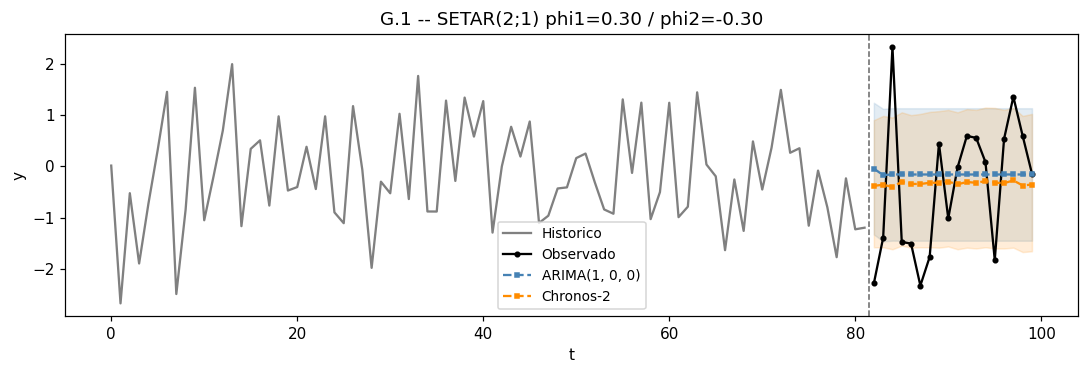

In [96]:
try:
    # G.1 -- SETAR(2;1) baja persistencia  phi1=0.30, phi2=-0.30, k=0
    cl  = ARIMAModel((1, 0, 0))
    dgp = SETARDGp(phi1=0.30, phi2=-0.30, threshold=0.0, delay=1, sigma=1.0, seed=SEED)
    verify_dgp("G.1 -- SETAR(2;1) baja persistencia", dgp, {}, cl, CHECKS_NONLINEAR)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="G.1")
    log("\n" + "="*60 + "\nG.1 -- SETAR(2;1) baja persistencia\n" + "="*60)
    build_grid_table(res, classical_name=cl.name)
    plot_simulation_v3(dgp, [cl, chronos], {}, title="G.1 -- SETAR(2;1) phi1=0.30 / phi2=-0.30")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA G.1 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:09:30  ────────────────────────────────────────────────────────────
19:09:30  VERIFICACION DGP: G.2 -- SETAR(2;1) alta persistencia
19:09:30  ────────────────────────────────────────────────────────────
19:09:30    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:09:30    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [-1.0798 -1.1977 -1.2892]
19:09:30    -> TODAS LAS VERIFICACIONES PASARON
19:09:30  Exp G.2: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:09:30    T=50 H=6, R=500: cargando exp_G_2_T50_R500.csv
19:09:30    T=100 H=18, R=500: cargando exp_G_2_T100_R500.csv
19:09:30    T=200 H=24, R=500: cargando exp_G_2_T200_R500.csv
19:09:30  
G.2 -- SETAR(2;1) alta persistencia


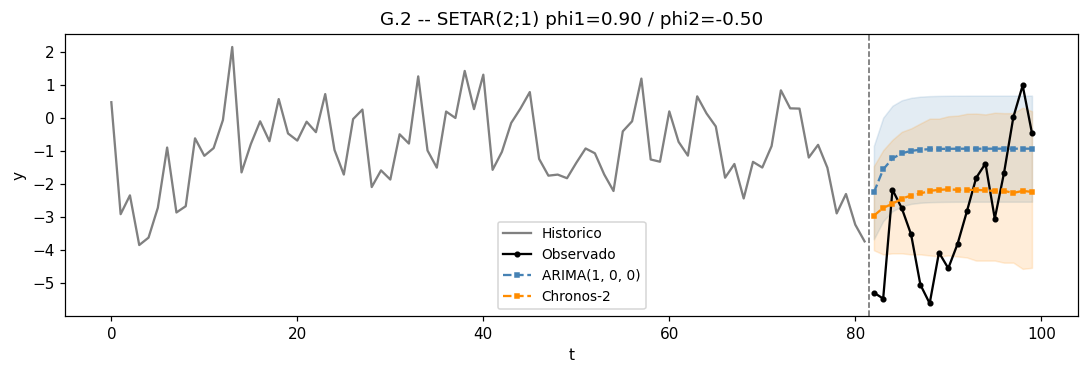

In [97]:
try:
    # G.2 -- SETAR(2;1) alta persistencia  phi1=0.90, phi2=-0.50, k=0
    cl  = ARIMAModel((1, 0, 0))
    dgp = SETARDGp(phi1=0.90, phi2=-0.50, threshold=0.0, delay=1, sigma=1.0, seed=SEED)
    verify_dgp("G.2 -- SETAR(2;1) alta persistencia", dgp, {}, cl, CHECKS_NONLINEAR)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="G.2")
    log("\n" + "="*60 + "\nG.2 -- SETAR(2;1) alta persistencia\n" + "="*60)
    build_grid_table(res, classical_name=cl.name)
    plot_simulation_v3(dgp, [cl, chronos], {}, title="G.2 -- SETAR(2;1) phi1=0.90 / phi2=-0.50")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA G.2 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:09:31  ────────────────────────────────────────────────────────────
19:09:31  VERIFICACION DGP: G.3 -- LSTAR(1) asimetrico
19:09:31  ────────────────────────────────────────────────────────────
19:09:31    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:09:32    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [1.1853 1.1177 1.0655]
19:09:32    -> TODAS LAS VERIFICACIONES PASARON
19:09:32  Exp G.3: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:09:32    T=50 H=6, R=500: cargando exp_G_3_T50_R500.csv
19:09:32    T=100 H=18, R=500: cargando exp_G_3_T100_R500.csv
19:09:32    T=200 H=24, R=500: cargando exp_G_3_T200_R500.csv
19:09:32  
G.3 -- LSTAR(1) asimetrico


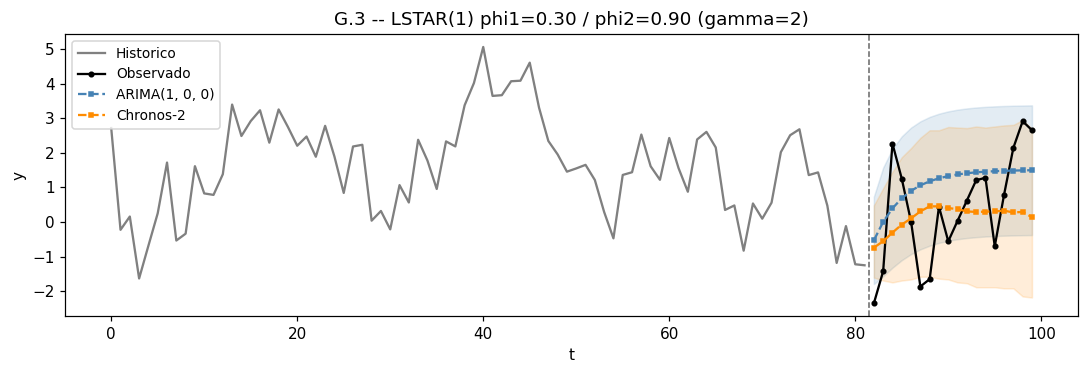

In [98]:
try:
    # G.3 -- LSTAR(1) asimetrico  phi1=0.30, phi2=0.90, gamma=2, c=0
    cl  = ARIMAModel((1, 0, 0))
    dgp = LSTARDGp(phi1=0.30, phi2=0.90, gamma=2.0, c=0.0, delay=1, sigma=1.0, seed=SEED)
    verify_dgp("G.3 -- LSTAR(1) asimetrico", dgp, {}, cl, CHECKS_NONLINEAR)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="G.3")
    log("\n" + "="*60 + "\nG.3 -- LSTAR(1) asimetrico\n" + "="*60)
    build_grid_table(res, classical_name=cl.name)
    plot_simulation_v3(dgp, [cl, chronos], {}, title="G.3 -- LSTAR(1) phi1=0.30 / phi2=0.90 (gamma=2)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA G.3 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

19:09:32  ────────────────────────────────────────────────────────────
19:09:32  VERIFICACION DGP: G.4 -- ESTAR(1) simetrico
19:09:32  ────────────────────────────────────────────────────────────
19:09:33    [PASS] Estacionariedad (ADF): ADF p=0.0000 (umbral 0.05)
19:09:33    [PASS] Ajuste modelo clasico: fit+forecast OK, primeros valores: [ 0.1113  0.0052 -0.0199]
19:09:33    -> TODAS LAS VERIFICACIONES PASARON
19:09:33  Exp G.4: 3 ejecucion(es) -> (T=50, H=6, R=500), (T=100, H=18, R=500), (T=200, H=24, R=500)
19:09:33    T=50 H=6, R=500: cargando exp_G_4_T50_R500.csv
19:09:33    T=100 H=18, R=500: cargando exp_G_4_T100_R500.csv
19:09:33    T=200 H=24, R=500: cargando exp_G_4_T200_R500.csv
19:09:33  
G.4 -- ESTAR(1) simetrico


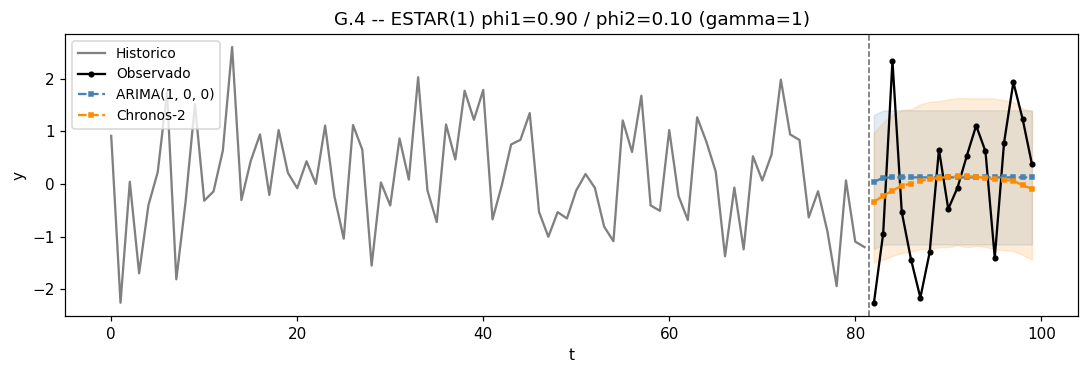

In [99]:
try:
    # G.4 -- ESTAR(1) simetrico  phi1=0.90, phi2=0.10, gamma=1, c=0
    cl  = ARIMAModel((1, 0, 0))
    dgp = ESTARDGp(phi1=0.90, phi2=0.10, gamma=1.0, c=0.0, delay=1, sigma=1.0, seed=SEED)
    verify_dgp("G.4 -- ESTAR(1) simetrico", dgp, {}, cl, CHECKS_NONLINEAR)
    res = run_exp(dgp, lambda T, _cl=cl: [_cl, chronos], {}, exp_id="G.4")
    log("\n" + "="*60 + "\nG.4 -- ESTAR(1) simetrico\n" + "="*60)
    build_grid_table(res, classical_name=cl.name)
    plot_simulation_v3(dgp, [cl, chronos], {}, title="G.4 -- ESTAR(1) phi1=0.90 / phi2=0.10 (gamma=1)")
except Exception as _exc:
    log("\n" + "!"*60)
    log("[CELDA G.4 FALLO] " + type(_exc).__name__ + ": " + str(_exc))
    log("!"*60)
    log(traceback.format_exc())

---
## Resumen

| Bloque | DGPs | T | R | Total series |
|--------|------|---|---|-------------|
| A — ARMA sin tendencia | 24 | 3 | 500 | 36,000 |
| B — ARMA con tendencia | 48 | 3 | 500 | 72,000 |
| C — Random Walk | 3 | 3 | 500 | 4,500 |
| D — ARCH/GARCH | 4 | 3 | 500 | 6,000 |
| E — ETS/Theta | 6 | 3 | 500 | 9,000 |
| F — SARIMA | 6 | 3 | 500 | 9,000 |
| G — SETAR/LSTAR/ESTAR | 4 | 3 | 500 | 6,000 |
| **Total** | **95** | — | — | **~142,500** |
